In [91]:
! pip install pandas numpy scikit-learn matplotlib seaborn plotly tqdm tensorflow nbformat


[notice] A new release of pip available: 22.3 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [93]:
datasets = {
    'CR': r'FEB 2025 Prototype data\CR.csv',
    'ECOR': r'FEB 2025 Prototype data\ECOR.csv',
    'ECR': r'FEB 2025 Prototype data\ECR.csv',
    'NCR': r'FEB 2025 Prototype data\NCR.csv',
    'NER': r'FEB 2025 Prototype data\NER.csv',
    'NFR': r'FEB 2025 Prototype data\NFR.csv',
    'NR': r'FEB 2025 Prototype data\NR.csv',
    'SCR': r'FEB 2025 Prototype data\SCR.csv',
    'SECR': r'FEB 2025 Prototype data\SECR.csv',
    'SR': r'FEB 2025 Prototype data\SR.csv',
    'WCR': r'FEB 2025 Prototype data\WCR.csv',
    'WR': r'FEB 2025 Prototype data\WR.csv',
    'TEST_ZONE': r'FEB 2025 Prototype data\Test_Zone.csv'
}

In [94]:
def load_and_preprocess_dataset(file_path, sample_size=5000):
    df = pd.read_csv(file_path)
    print(f"Original dataset shape: {df.shape}")
    
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)
    
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    print(f"Found {len(numeric_cols)} numeric columns")
    
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].str.contains(',').any():
            try:
                values_lists = df[col].apply(lambda x: [float(v) for v in str(x).split(',') if v.strip() and v.strip().replace('.','',1).isdigit()])
                
                df[f"{col}_mean"] = values_lists.apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
                df[f"{col}_max"] = values_lists.apply(lambda x: np.max(x) if len(x) > 0 else np.nan)
                df[f"{col}_min"] = values_lists.apply(lambda x: np.min(x) if len(x) > 0 else np.nan)
                df[f"{col}_std"] = values_lists.apply(lambda x: np.std(x) if len(x) > 0 else np.nan)
                
                numeric_cols.extend([f"{col}_mean", f"{col}_max", f"{col}_min", f"{col}_std"])
                print(f"Extracted features from {col}")
            except Exception as e:
                print(f"Could not process {col}: {e}")
    
    if not numeric_cols:
        raise ValueError("No numeric columns found for clustering")
    
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].mean() if not df[col].isnull().all() else 0)
    
    df_features = df[numeric_cols].copy()
    print(f"Final dataset shape: {df_features.shape}")
    
    return df_features

In [95]:
def reduce_dimensions(X_scaled, n_components=3):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"Explained variance: {pca.explained_variance_ratio_}")
    print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")
    
    return X_pca, pca

In [96]:
def find_optimal_k(X, max_k=10):
    inertia = []
    silhouette_scores = []
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
        
        score = silhouette_score(X, kmeans.labels_)
        silhouette_scores.append(score)
        print(f"K={k}, Silhouette Score={score:.4f}")
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(2, max_k + 1), inertia, 'o-', color='royalblue')
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(2, max_k + 1), silhouette_scores, 'o-', color='green')
    plt.title('Silhouette Scores')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    optimal_k = np.argmax(silhouette_scores) + 2
    print(f"Optimal number of clusters: {optimal_k}")
    
    return optimal_k

In [97]:
def perform_clustering(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    return cluster_labels, kmeans

In [98]:
def visualize_clusters_3d(X_pca, labels, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    unique_labels = np.unique(labels)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], 
                  c=[colors[i]], label=f'Cluster {label}', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [99]:
def build_autoencoder(X, encoding_dim=10):
    input_dim = X.shape[1]
    
    input_layer = Input(shape=(input_dim,))
    
    # Encoder with dropout to prevent overfitting
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dropout(0.3)(encoded)  # Increased dropout
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dropout(0.3)(encoded)  # Increased dropout
    encoded = Dense(encoding_dim, activation='relu')(encoded)
    
    # Decoder with dropout
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dropout(0.3)(decoded)  # Increased dropout
    decoded = Dense(128, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)
    
    # Use L2 regularization in optimizer to prevent overfitting
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2
    
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    X_train, X_val = train_test_split(X, test_size=0.3, random_state=42)
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train with early stopping and validation
    history = autoencoder.fit(
        X_train, X_train,
        epochs=50,
        batch_size=64,
        shuffle=True,
        validation_data=(X_val, X_val),
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Plot learning curves to check for overfitting
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Autoencoder Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return autoencoder, encoder, history

In [100]:
def detect_anomalies(X, autoencoder, threshold_percentile=95):
    reconstructions = autoencoder.predict(X)
    mse = np.mean(np.power(X - reconstructions, 2), axis=1)
    
    threshold = np.percentile(mse, threshold_percentile)
    anomalies = mse > threshold
    
    return anomalies, mse, threshold

In [101]:
def visualize_anomalies(X_pca, errors, anomalies, title):
    plt.figure(figsize=(12, 10))
    
    ax = plt.subplot(111, projection='3d')
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
               c=errors, cmap='viridis', alpha=0.7)
    
    if np.sum(anomalies) > 0:
        ax.scatter(X_pca[anomalies, 0], X_pca[anomalies, 1], X_pca[anomalies, 2], 
                  color='red', s=50, label='Anomalies')
    
    plt.colorbar(sc, label='Reconstruction Error')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [102]:
def evaluate_model(X, y, feature_cols, test_size=0.3):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    from sklearn.ensemble import RandomForestClassifier
    
    # Use regularization to prevent overfitting
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,  # Limit tree depth to prevent overfitting
        min_samples_split=5,  # Require more samples to split a node
        min_samples_leaf=2,  # Require at least 2 samples in leaf nodes
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    
    # Check for overfitting
    if train_accuracy - test_accuracy > 0.05:
        print("Warning: Model may be overfitting (large gap between train and test accuracy)")
        
    # Check for underfitting
    if train_accuracy < 0.95:
        print("Warning: Model may be underfitting (low training accuracy)")
    
    feature_importances = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Plot feature importances
    plt.figure(figsize=(10, 6))
    plt.bar(feature_importances['Feature'].head(15), feature_importances['Importance'].head(15))
    plt.xticks(rotation=90)
    plt.title('Top 15 Important Features')
    plt.tight_layout()
    plt.show()
    
    return model, feature_importances, test_accuracy

In [103]:
def create_dashboard(X_pca, labels, errors, anomalies, title, accuracy):
    plt.figure(figsize=(16, 12))
    
    ax1 = plt.subplot(2, 2, 1, projection='3d')
    unique_labels = np.unique(labels)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], 
                   c=[colors[i]], label=f'Cluster {label}', alpha=0.7)
    
    ax1.set_title('Cluster Visualization')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    
    ax2 = plt.subplot(2, 2, 2)
    cluster_counts = pd.Series(labels).value_counts().sort_index()
    ax2.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index], 
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('Cluster Distribution')
    
    ax3 = plt.subplot(2, 2, 3)
    ax3.hist(errors, bins=50, color='teal', alpha=0.7)
    ax3.axvline(x=np.percentile(errors, 95), color='red', linestyle='--', label='Anomaly Threshold')
    ax3.set_title('Reconstruction Error Distribution')
    ax3.set_xlabel('Reconstruction Error')
    ax3.set_ylabel('Count')
    ax3.legend()
    
    ax4 = plt.subplot(2, 2, 4)
    normal_mask = ~anomalies
    scatter1 = ax4.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], 
                         c=labels[normal_mask], cmap='viridis', alpha=0.6, label='Normal')
    
    if np.sum(anomalies) > 0:
        ax4.scatter(X_pca[anomalies, 0], X_pca[anomalies, 1], 
                   color='red', marker='x', s=50, label='Anomalies')
    
    ax4.set_title('PCA Scatter with Anomalies')
    ax4.set_xlabel('PC1')
    ax4.set_ylabel('PC2')
    ax4.legend()
    
    plt.suptitle(f"{title} - Model Accuracy: {accuracy:.2f}%", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [104]:
def process_region(region_name, file_path):
    print(f"\n{'='*50}")
    print(f"Processing {region_name} from {file_path}")
    print(f"{'='*50}")
    
    try:
        if not os.path.isfile(file_path):
            print(f"File not found: {file_path}")
            return None
            
        df_features = load_and_preprocess_dataset(file_path)
        
        if df_features.empty:
            print(f"No usable features for {region_name}")
            return None
        
        feature_cols = df_features.columns.tolist()
        
        # Standardize data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_features)
        
        # PCA
        X_pca, pca = reduce_dimensions(X_scaled)
        
        # Optimal clustering
        optimal_k = find_optimal_k(X_scaled)
        
        # Perform clustering
        cluster_labels, kmeans_model = perform_clustering(X_scaled, optimal_k)
        
        # Visualize clusters
        visualize_clusters_3d(X_pca, cluster_labels, f"{region_name} - Cluster Visualization")
        
        # Anomaly detection
        autoencoder, encoder, history = build_autoencoder(X_scaled, encoding_dim=optimal_k)
        
        anomalies, reconstruction_errors, threshold = detect_anomalies(X_scaled, autoencoder)
        print(f"Detected {sum(anomalies)} anomalies out of {len(anomalies)} data points")
        
        visualize_anomalies(X_pca, reconstruction_errors, anomalies, f"{region_name} - Anomaly Detection")
        
        # Model evaluation
        model, feature_importances, accuracy = evaluate_model(X_scaled, cluster_labels, feature_cols)
        print(f"Top 5 important features for {region_name}:")
        print(feature_importances.head())
        
        create_dashboard(X_pca, cluster_labels, reconstruction_errors, anomalies, 
                        f"{region_name} Railway Signals Analysis", accuracy*100)
        
        result = {
            'region': region_name,
            'optimal_clusters': optimal_k,
            'accuracy': accuracy,
            'anomalies_count': sum(anomalies),
            'anomalies_percentage': sum(anomalies)/len(anomalies)*100,
            'model': model,
            'kmeans': kmeans_model,
            'autoencoder': autoencoder,
            'pca': pca,
            'feature_importances': feature_importances
        }
        
        return result
    except Exception as e:
        print(f"Error processing {region_name}: {e}")
        import traceback
        traceback.print_exc()
        return None


Processing CR from FEB 2025 Prototype data\CR.csv
Original dataset shape: (105881, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.57787247 0.23933443 0.06860377]
Total explained variance: 0.8858
K=2, Silhouette Score=0.5907
K=3, Silhouette Score=0.6197
K=4, Silhouette Score=0.5855
K=5, Silhouette Score=0.4515
K=6, Silhouette Score=0.4825
K=7, Silhouette Score=0.4437
K=8, Silhouette Score=0.4077
K=9, Silhouette Score=0.4136
K=10, Silhouette Score=0.4141


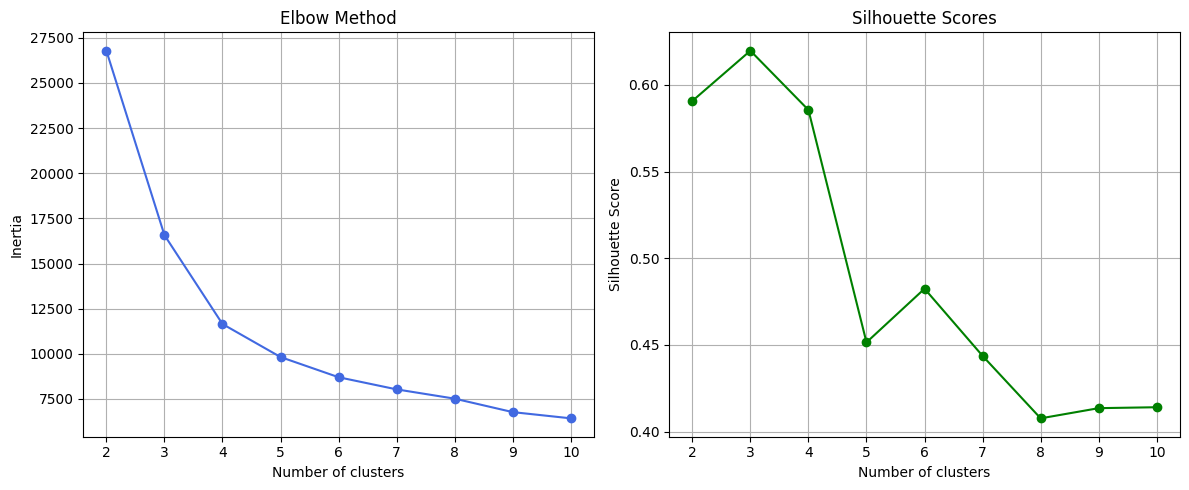

Optimal number of clusters: 3


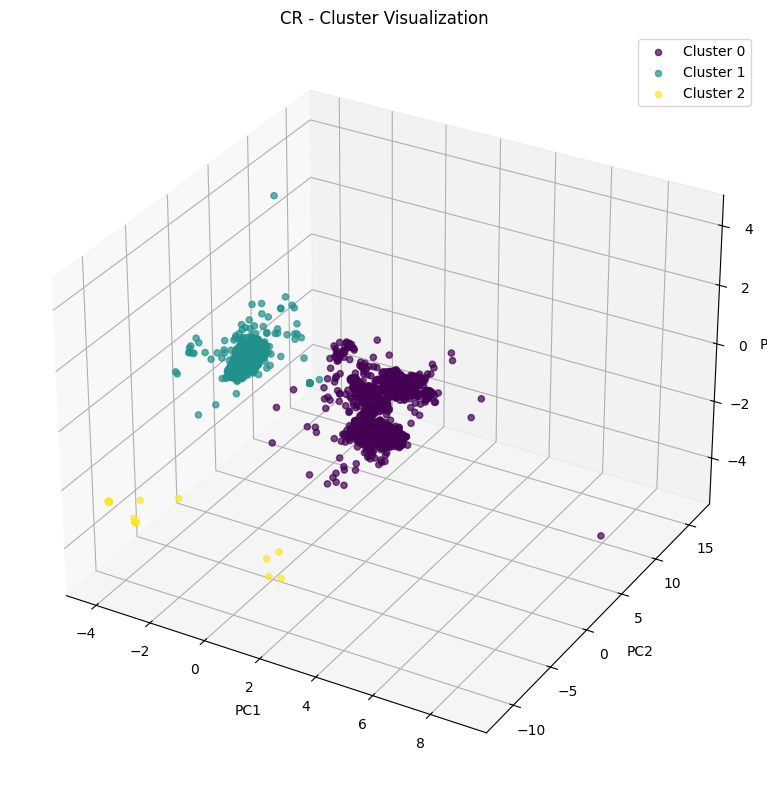

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5302 - val_loss: 0.2992
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2571 - val_loss: 0.1666
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2080 - val_loss: 0.1530
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1782 - val_loss: 0.1398
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1676 - val_loss: 0.1114
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1350 - val_loss: 0.1047
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1229 - val_loss: 0.0961
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1376 - val_loss: 0.1015
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1187 - val_loss: 0.0899
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1055 - val_loss: 0.0977
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0979 - val_loss: 0.0899
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0920 - val_lo

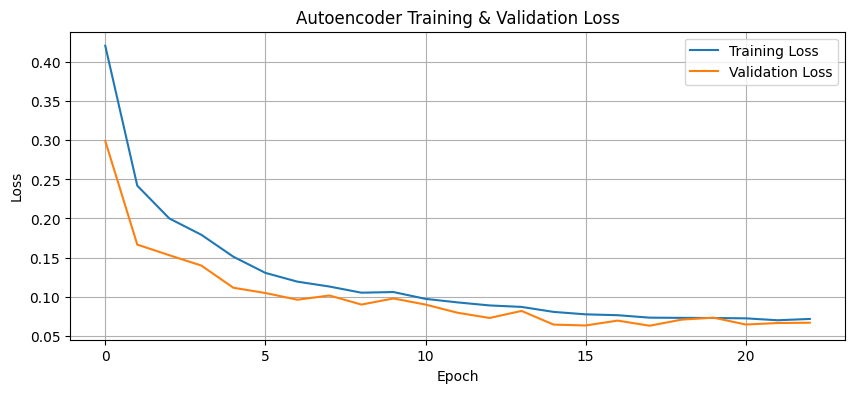

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
Detected 250 anomalies out of 5000 data points


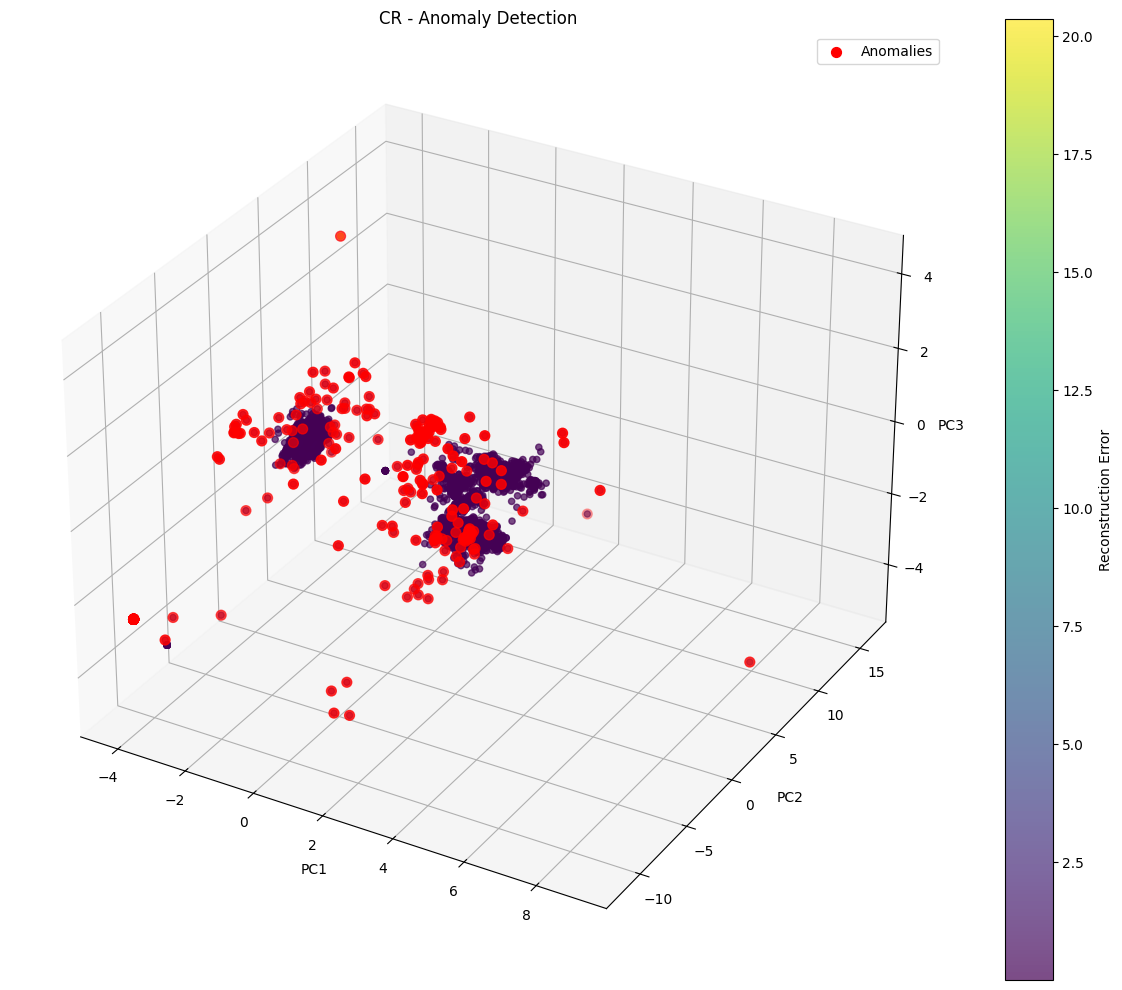

Training Accuracy: 1.0000
Testing Accuracy: 0.9987


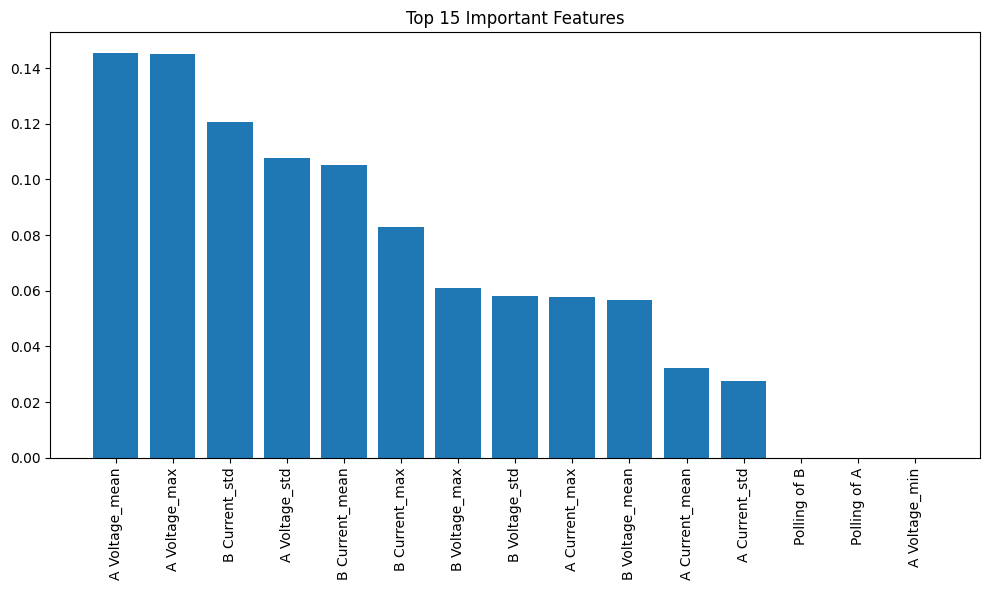

Top 5 important features for CR:
           Feature  Importance
6   A Voltage_mean    0.145586
7    A Voltage_max    0.144952
13   B Current_std    0.120462
9    A Voltage_std    0.107848
10  B Current_mean    0.105266


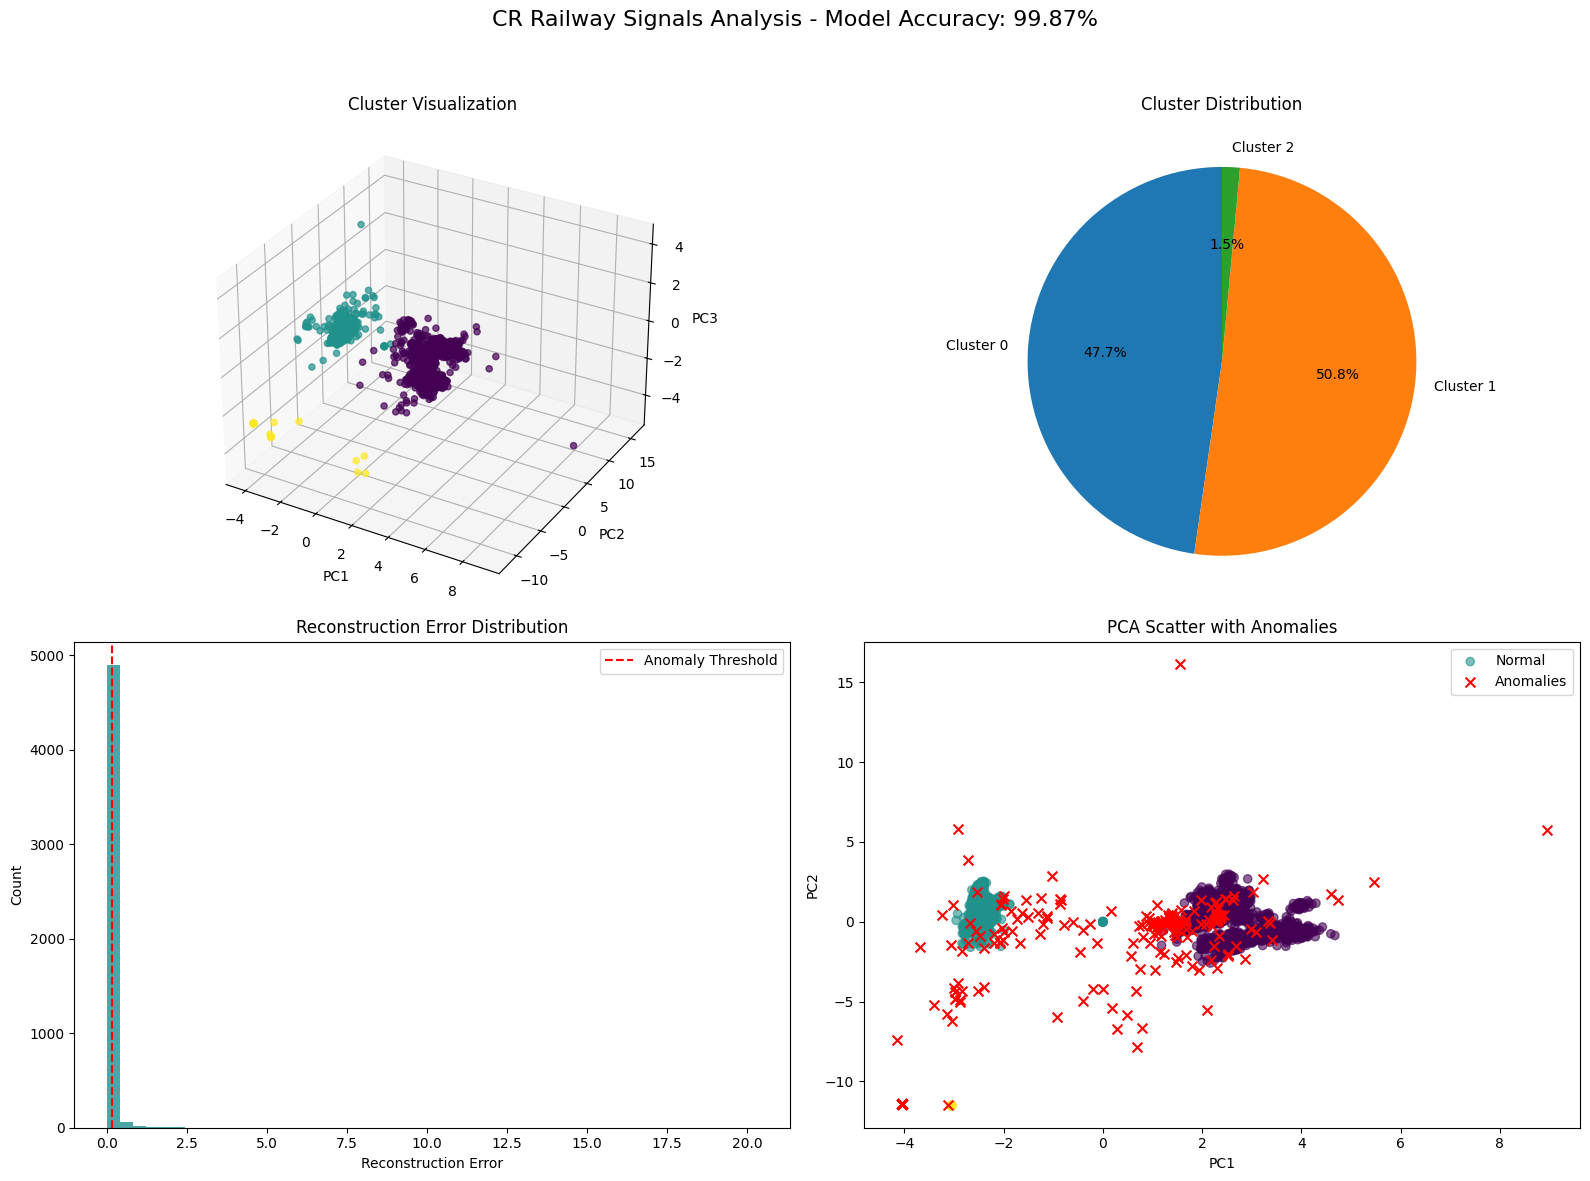


Processing ECOR from FEB 2025 Prototype data\ECOR.csv
Original dataset shape: (93553, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.50300761 0.38287459 0.07057478]
Total explained variance: 0.9565
K=2, Silhouette Score=0.6809
K=3, Silhouette Score=0.7125
K=4, Silhouette Score=0.4223
K=5, Silhouette Score=0.4297
K=6, Silhouette Score=0.4072
K=7, Silhouette Score=0.2789
K=8, Silhouette Score=0.2841
K=9, Silhouette Score=0.2620
K=10, Silhouette Score=0.2786


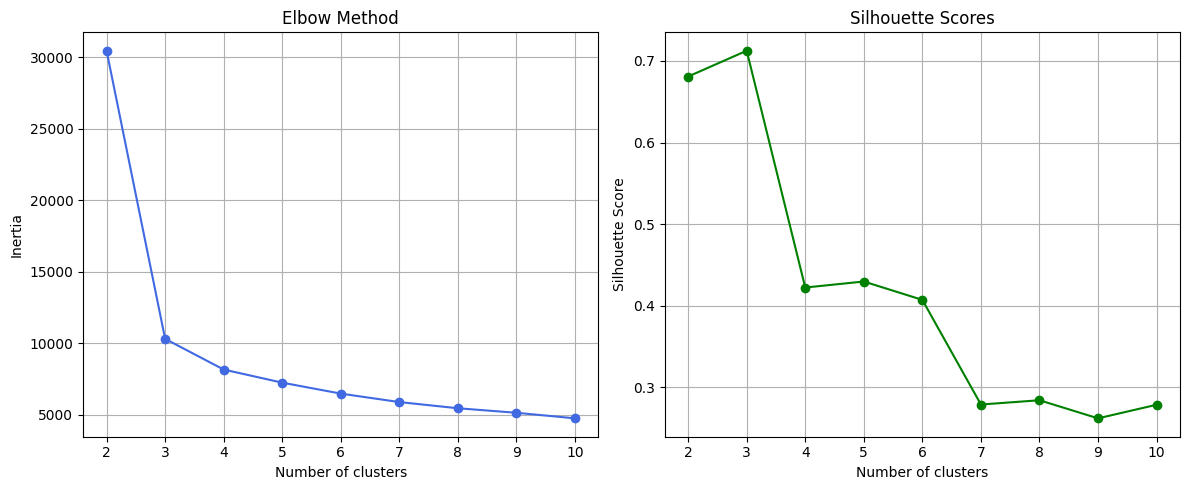

Optimal number of clusters: 3


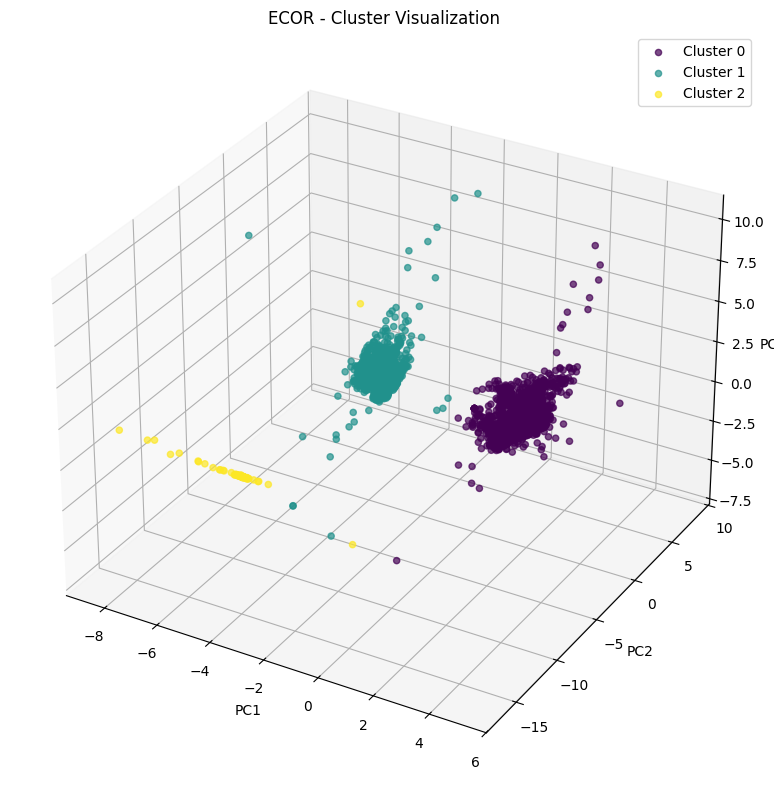

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6952 - val_loss: 0.3011
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2968 - val_loss: 0.1381
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1482 - val_loss: 0.0846
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1183 - val_loss: 0.0804
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1019 - val_loss: 0.0761
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0935 - val_loss: 0.0747
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0960 - val_loss: 0.0750
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0908 - val_loss: 0.0734
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0806 - val_loss: 0.0695
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0953 - val_loss: 0.0691
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0901 - val_loss: 0.0686
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0779 - val_lo

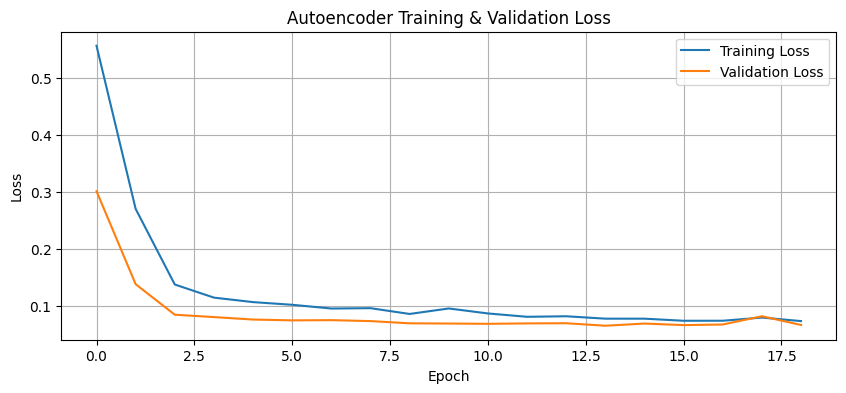

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Detected 250 anomalies out of 5000 data points


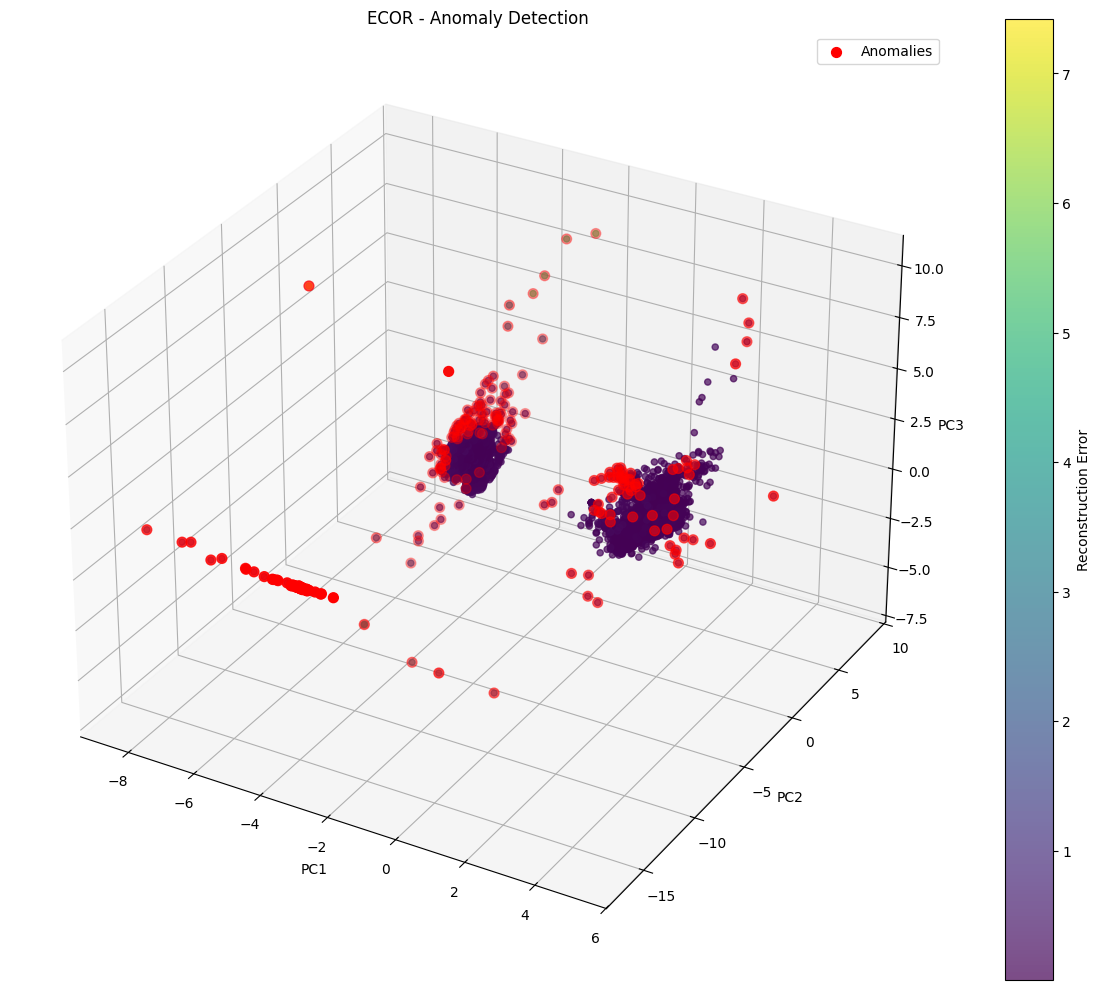

Training Accuracy: 1.0000
Testing Accuracy: 0.9993


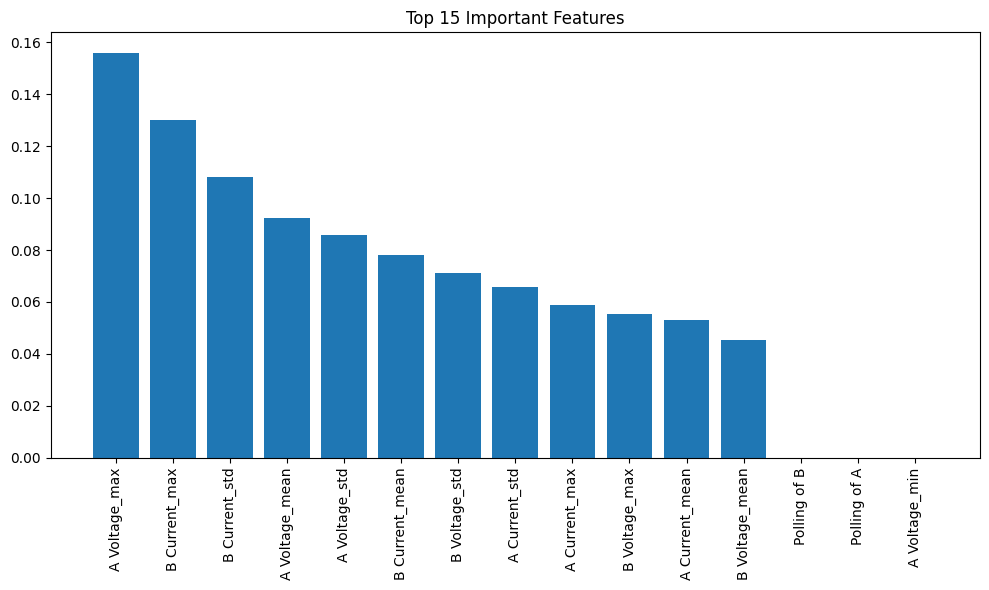

Top 5 important features for ECOR:
           Feature  Importance
7    A Voltage_max    0.156071
11   B Current_max    0.130217
13   B Current_std    0.107997
6   A Voltage_mean    0.092402
9    A Voltage_std    0.085743


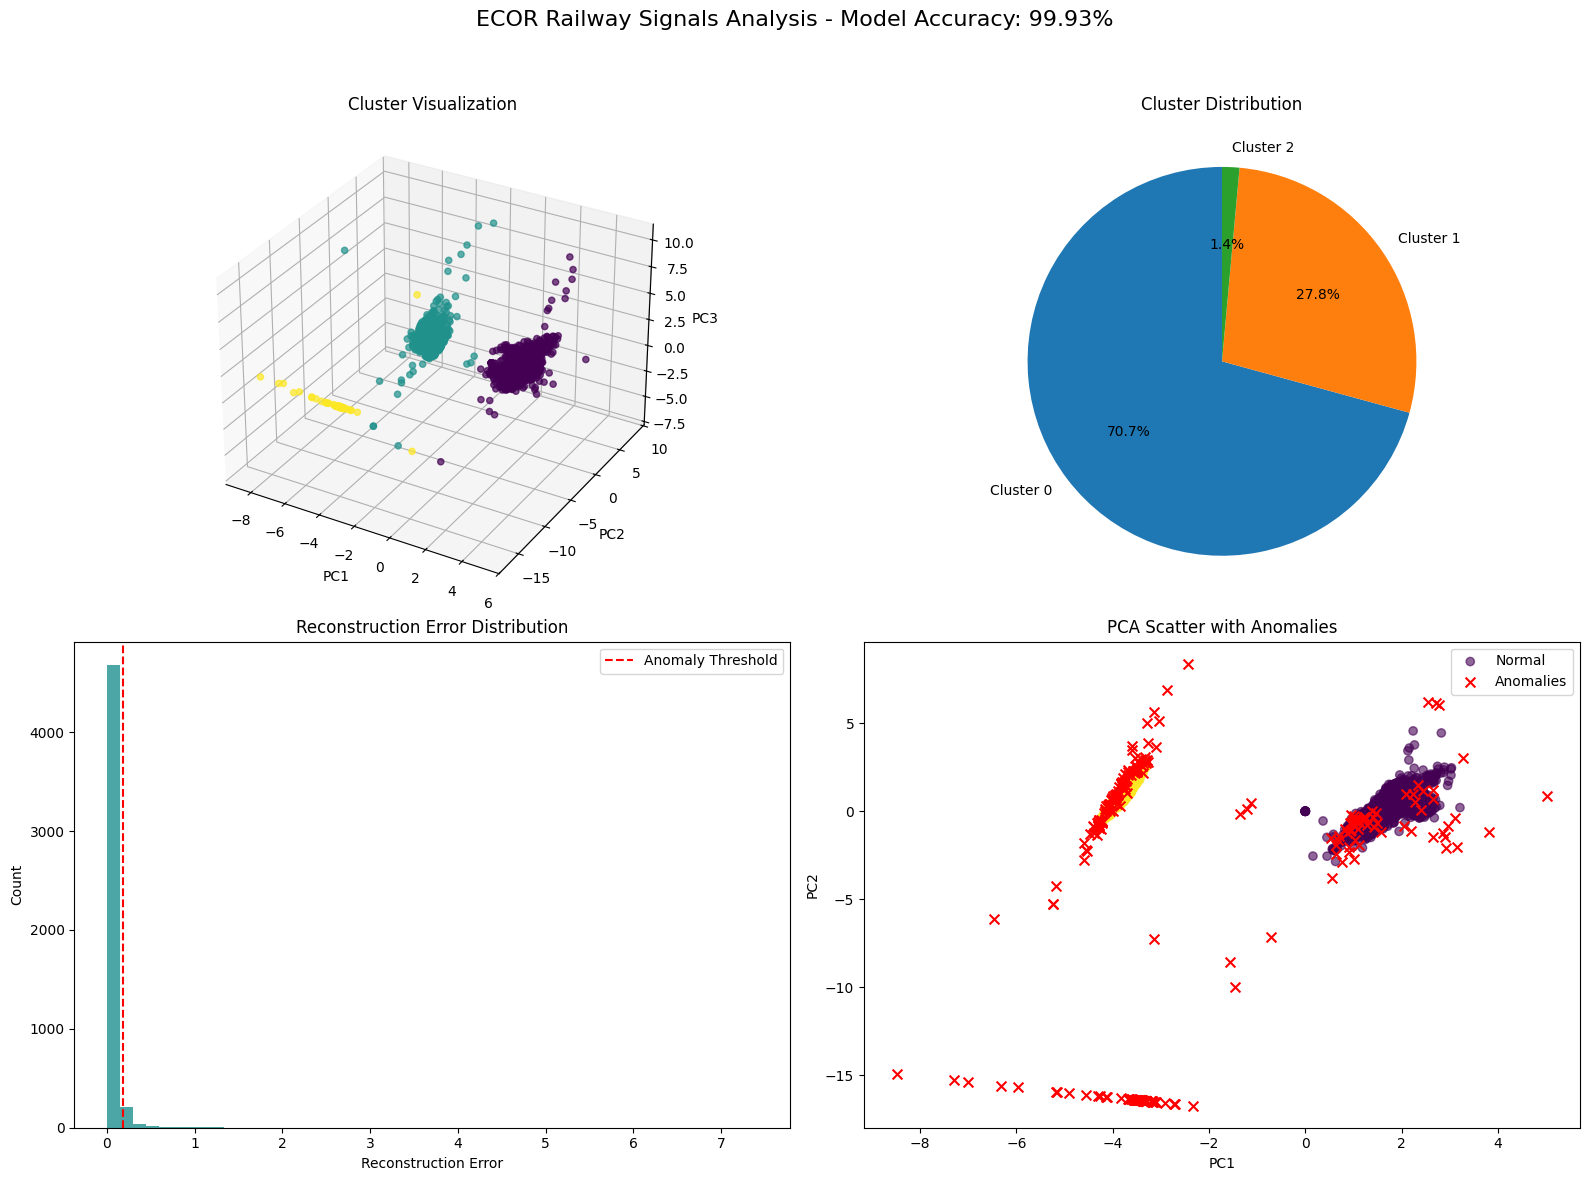


Processing ECR from FEB 2025 Prototype data\ECR.csv
Original dataset shape: (363007, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.45928723 0.27695227 0.12327473]
Total explained variance: 0.8595
K=2, Silhouette Score=0.9807
K=3, Silhouette Score=0.9800
K=4, Silhouette Score=0.7802
K=5, Silhouette Score=0.7813
K=6, Silhouette Score=0.7813
K=7, Silhouette Score=0.7814
K=8, Silhouette Score=0.7902
K=9, Silhouette Score=0.7936
K=10, Silhouette Score=0.7968


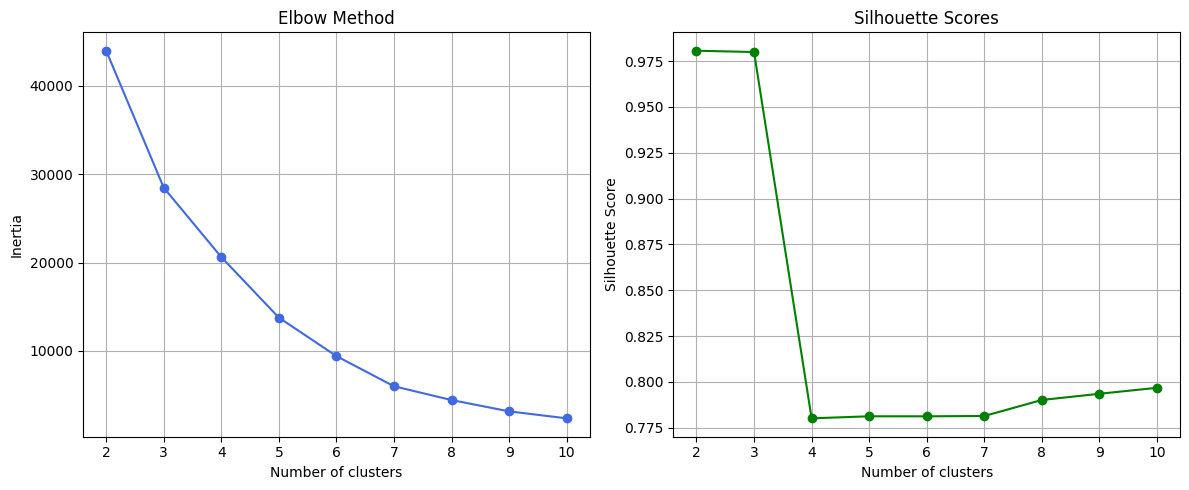

Optimal number of clusters: 2


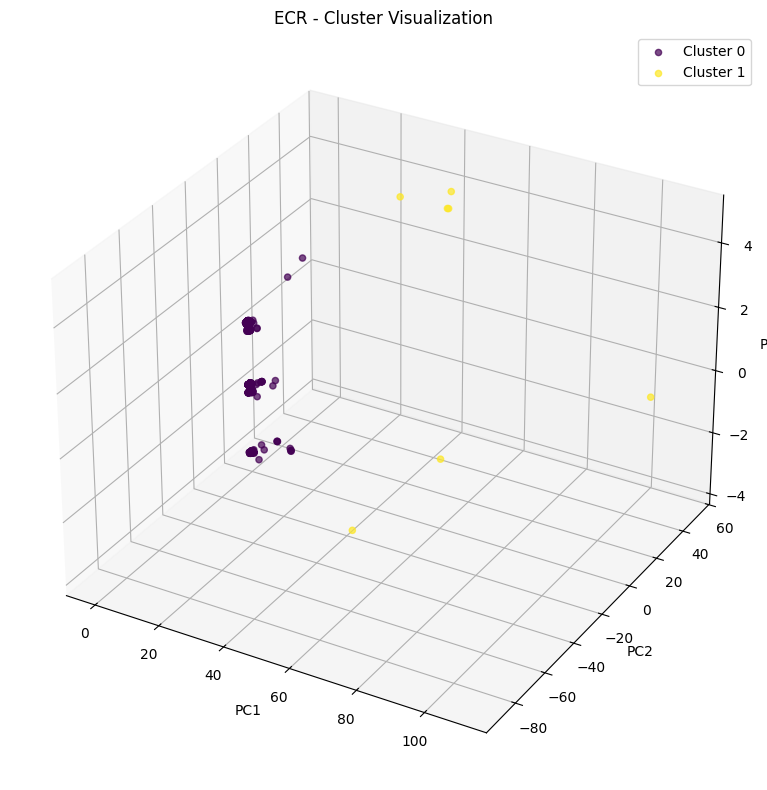

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3592 - val_loss: 0.6006
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5436 - val_loss: 0.5348
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3122 - val_loss: 0.4088
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2943 - val_loss: 0.3911
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3141 - val_loss: 0.3955
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1600 - val_loss: 0.3931
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8171 - val_loss: 0.3945
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4206 - val_loss: 0.4259
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3805 - val_loss: 0.3756
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4570 - val_loss: 0.3889
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8339 - val_loss: 0.4031
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1619 - val_lo

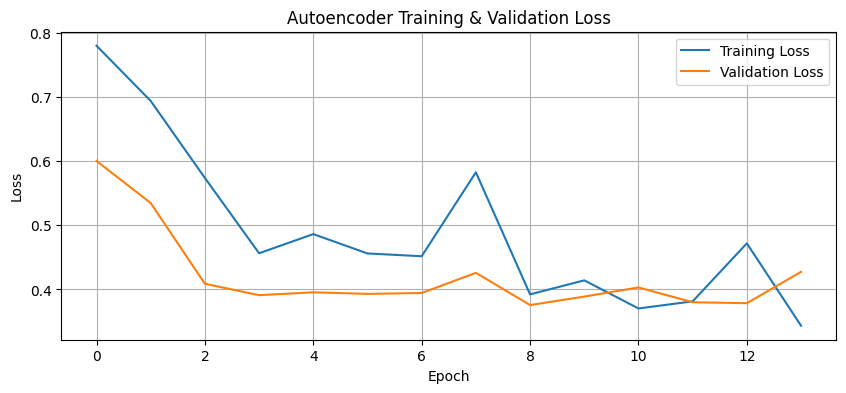

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step
Detected 250 anomalies out of 5000 data points


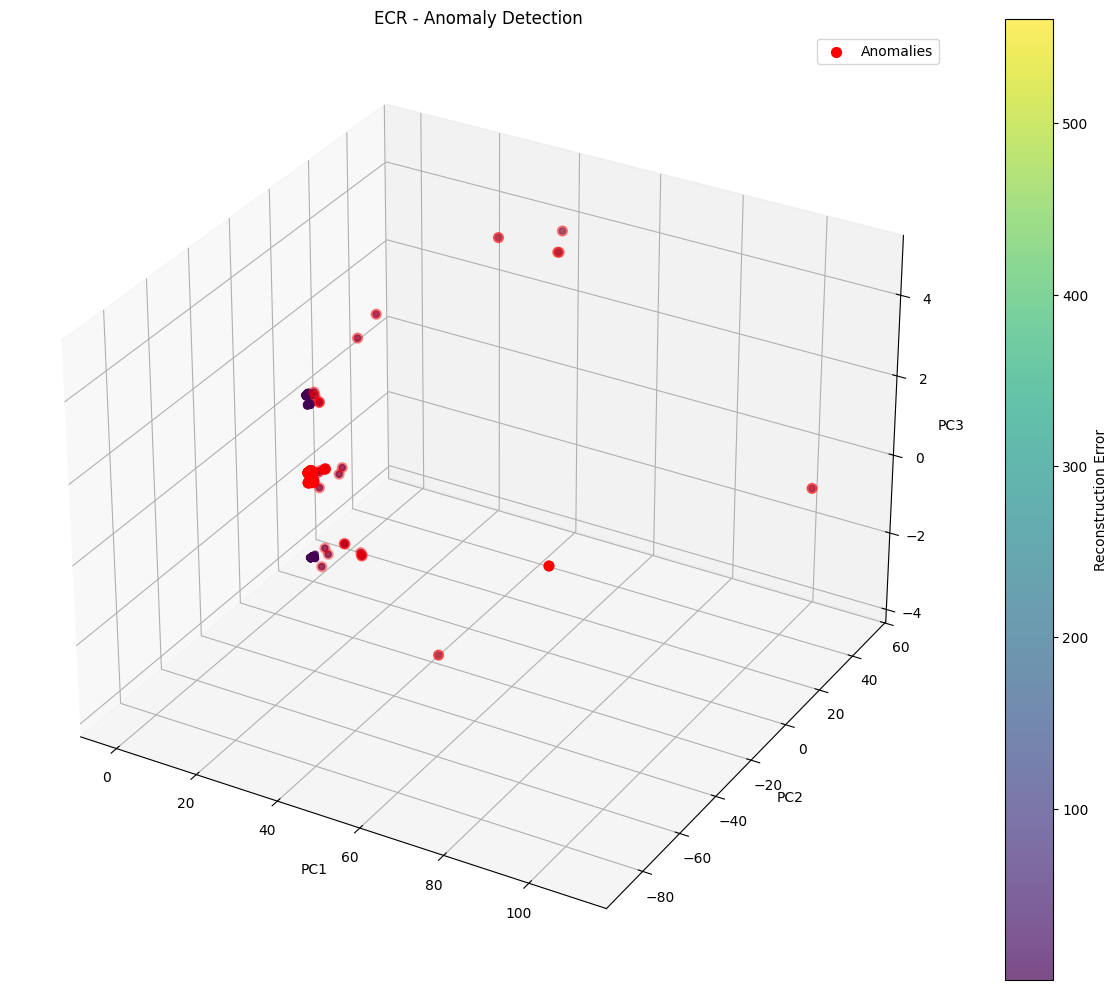

Training Accuracy: 1.0000
Testing Accuracy: 1.0000


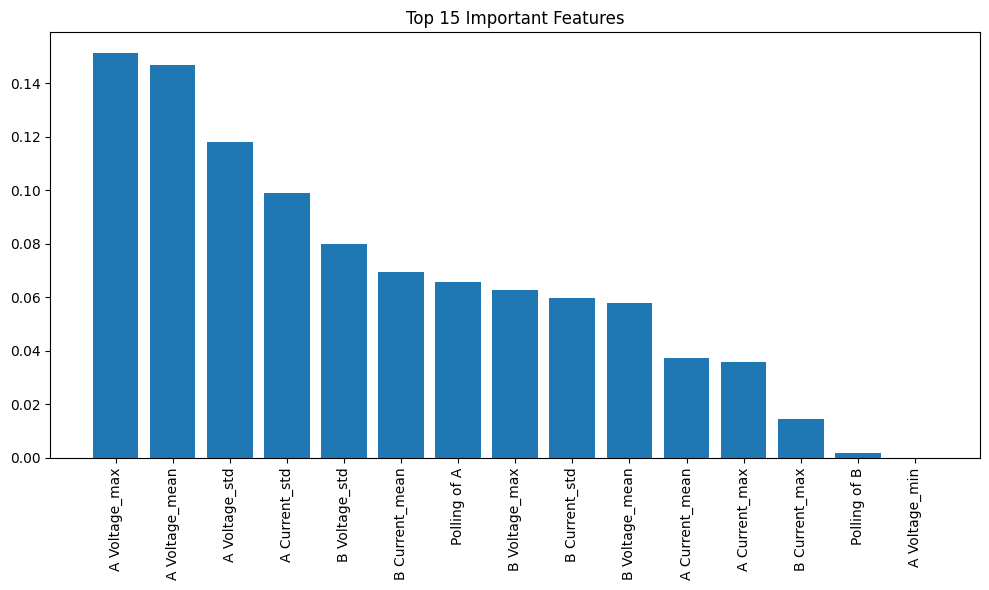

Top 5 important features for ECR:
           Feature  Importance
7    A Voltage_max    0.151500
6   A Voltage_mean    0.146966
9    A Voltage_std    0.118007
5    A Current_std    0.098798
17   B Voltage_std    0.079791


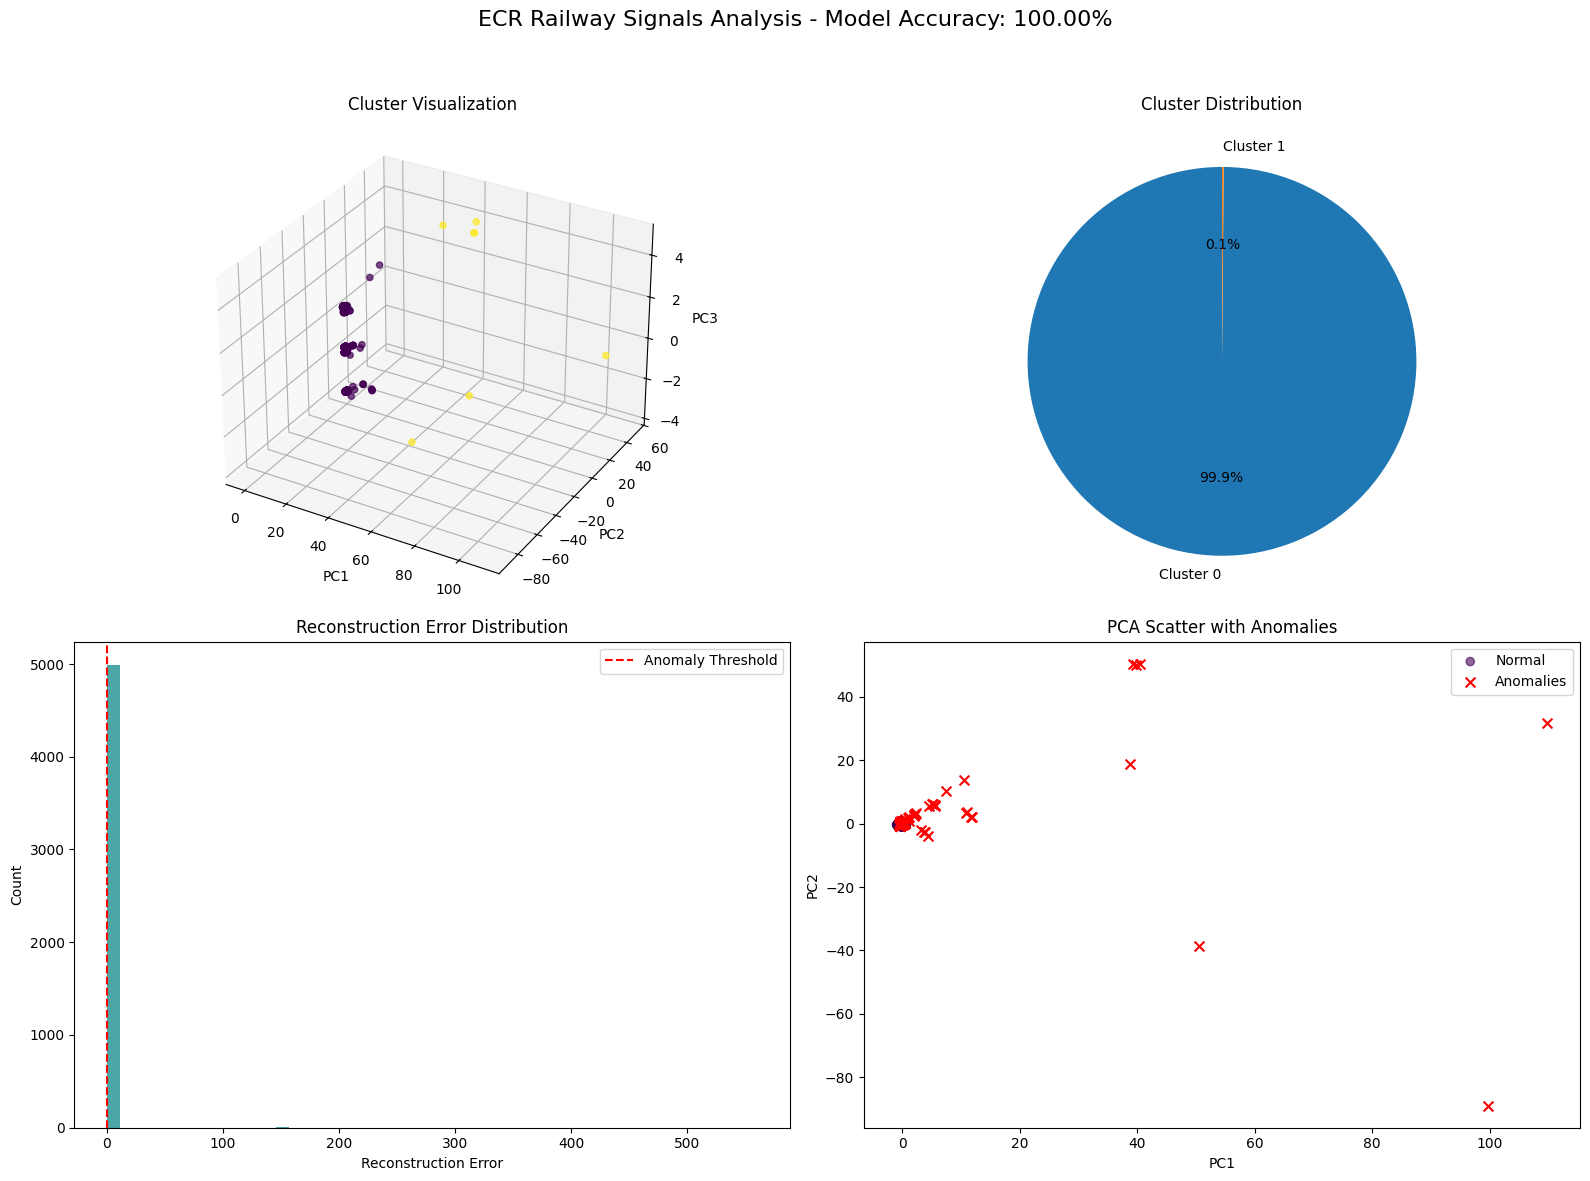


Processing NCR from FEB 2025 Prototype data\NCR.csv
Original dataset shape: (49244, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.32870144 0.24710792 0.1513899 ]
Total explained variance: 0.7272
K=2, Silhouette Score=0.6868
K=3, Silhouette Score=0.5825
K=4, Silhouette Score=0.3980
K=5, Silhouette Score=0.4220
K=6, Silhouette Score=0.4933
K=7, Silhouette Score=0.4983
K=8, Silhouette Score=0.5027
K=9, Silhouette Score=0.4626
K=10, Silhouette Score=0.4240


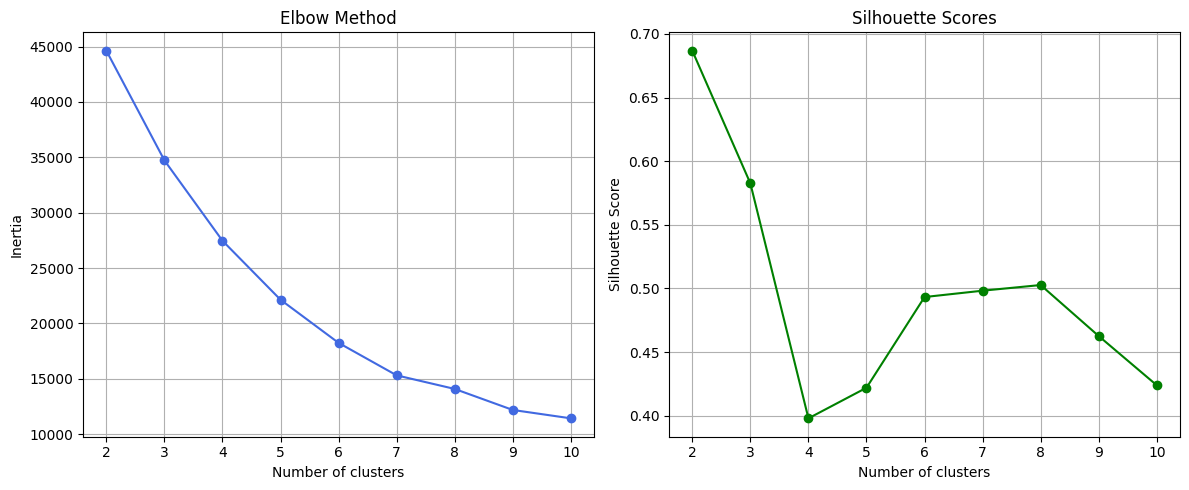

Optimal number of clusters: 2


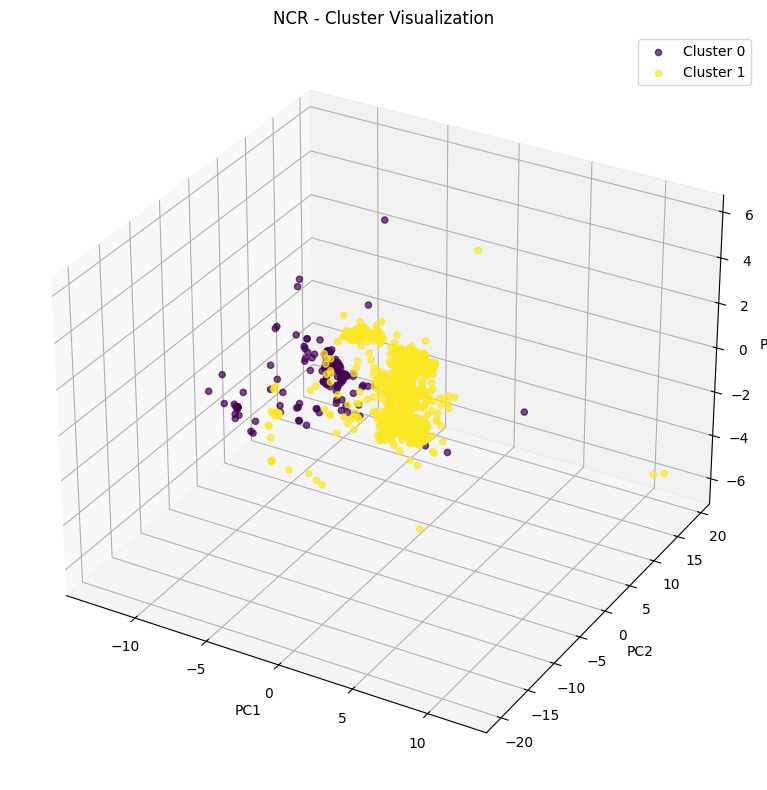

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.6100 - val_loss: 0.4807
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4359 - val_loss: 0.4297
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3922 - val_loss: 0.3626
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3651 - val_loss: 0.2954
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2577 - val_loss: 0.2739
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2390 - val_loss: 0.2627
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2751 - val_loss: 0.2550
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2162 - val_loss: 0.2369
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2135 - val_loss: 0.2274
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2252 - val_loss: 0.2156
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2542 - val_loss: 0.2324
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2359 - va

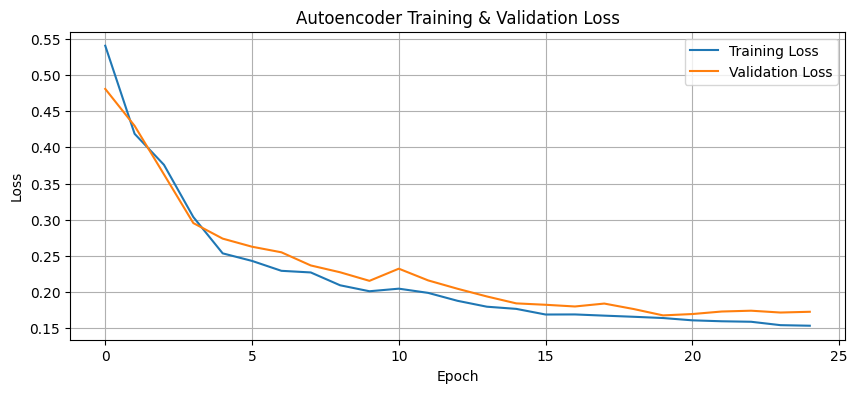

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Detected 250 anomalies out of 5000 data points


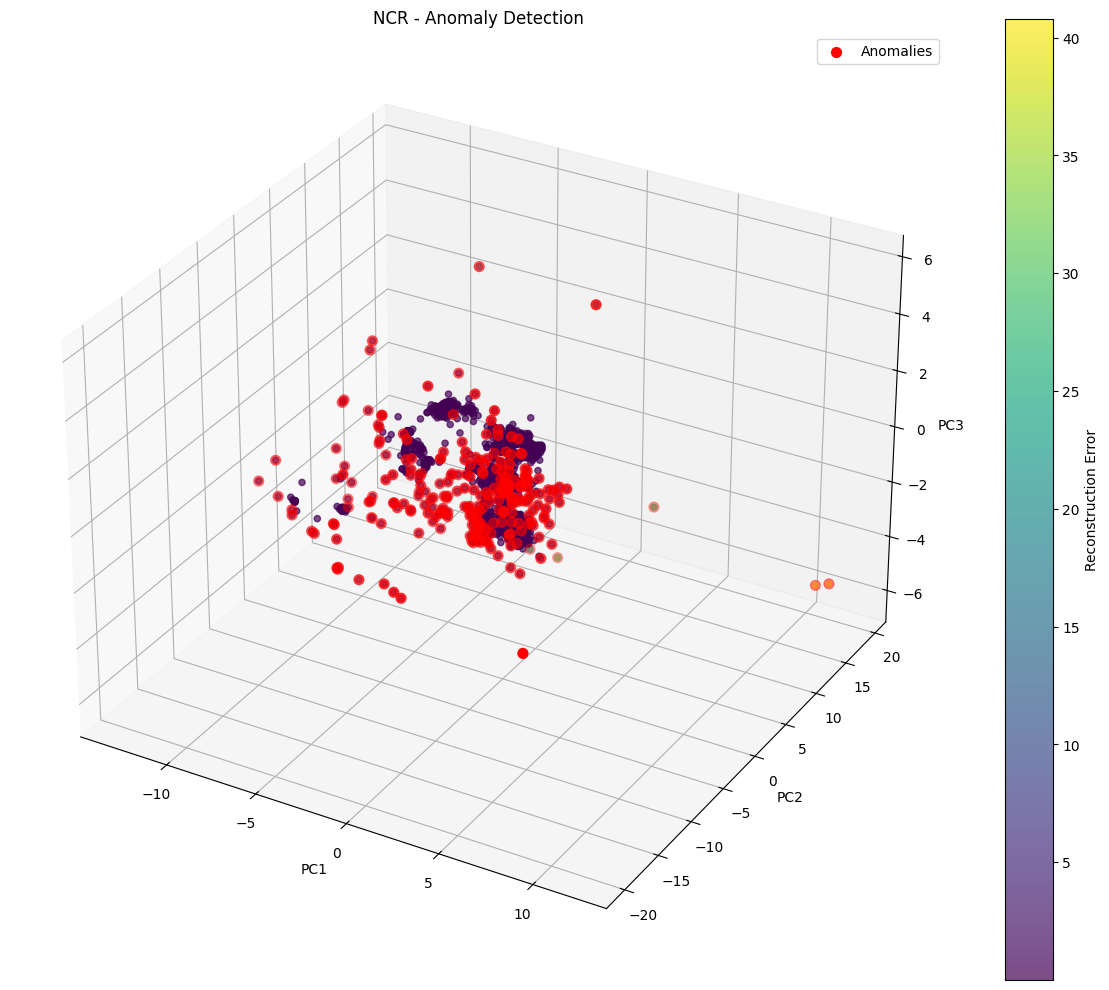

Training Accuracy: 0.9994
Testing Accuracy: 0.9953


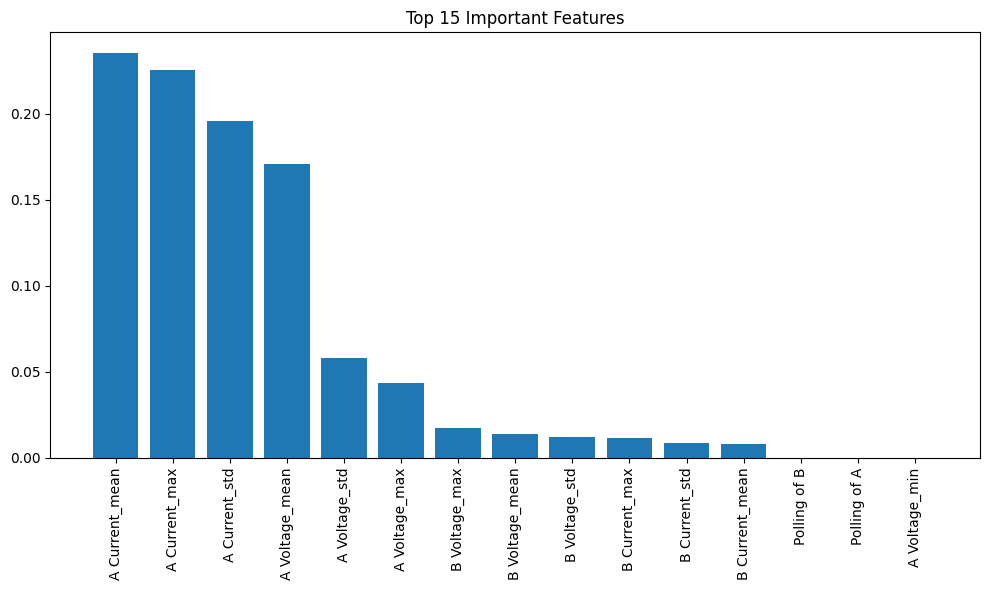

Top 5 important features for NCR:
          Feature  Importance
2  A Current_mean    0.235597
3   A Current_max    0.225259
5   A Current_std    0.195770
6  A Voltage_mean    0.170657
9   A Voltage_std    0.058125


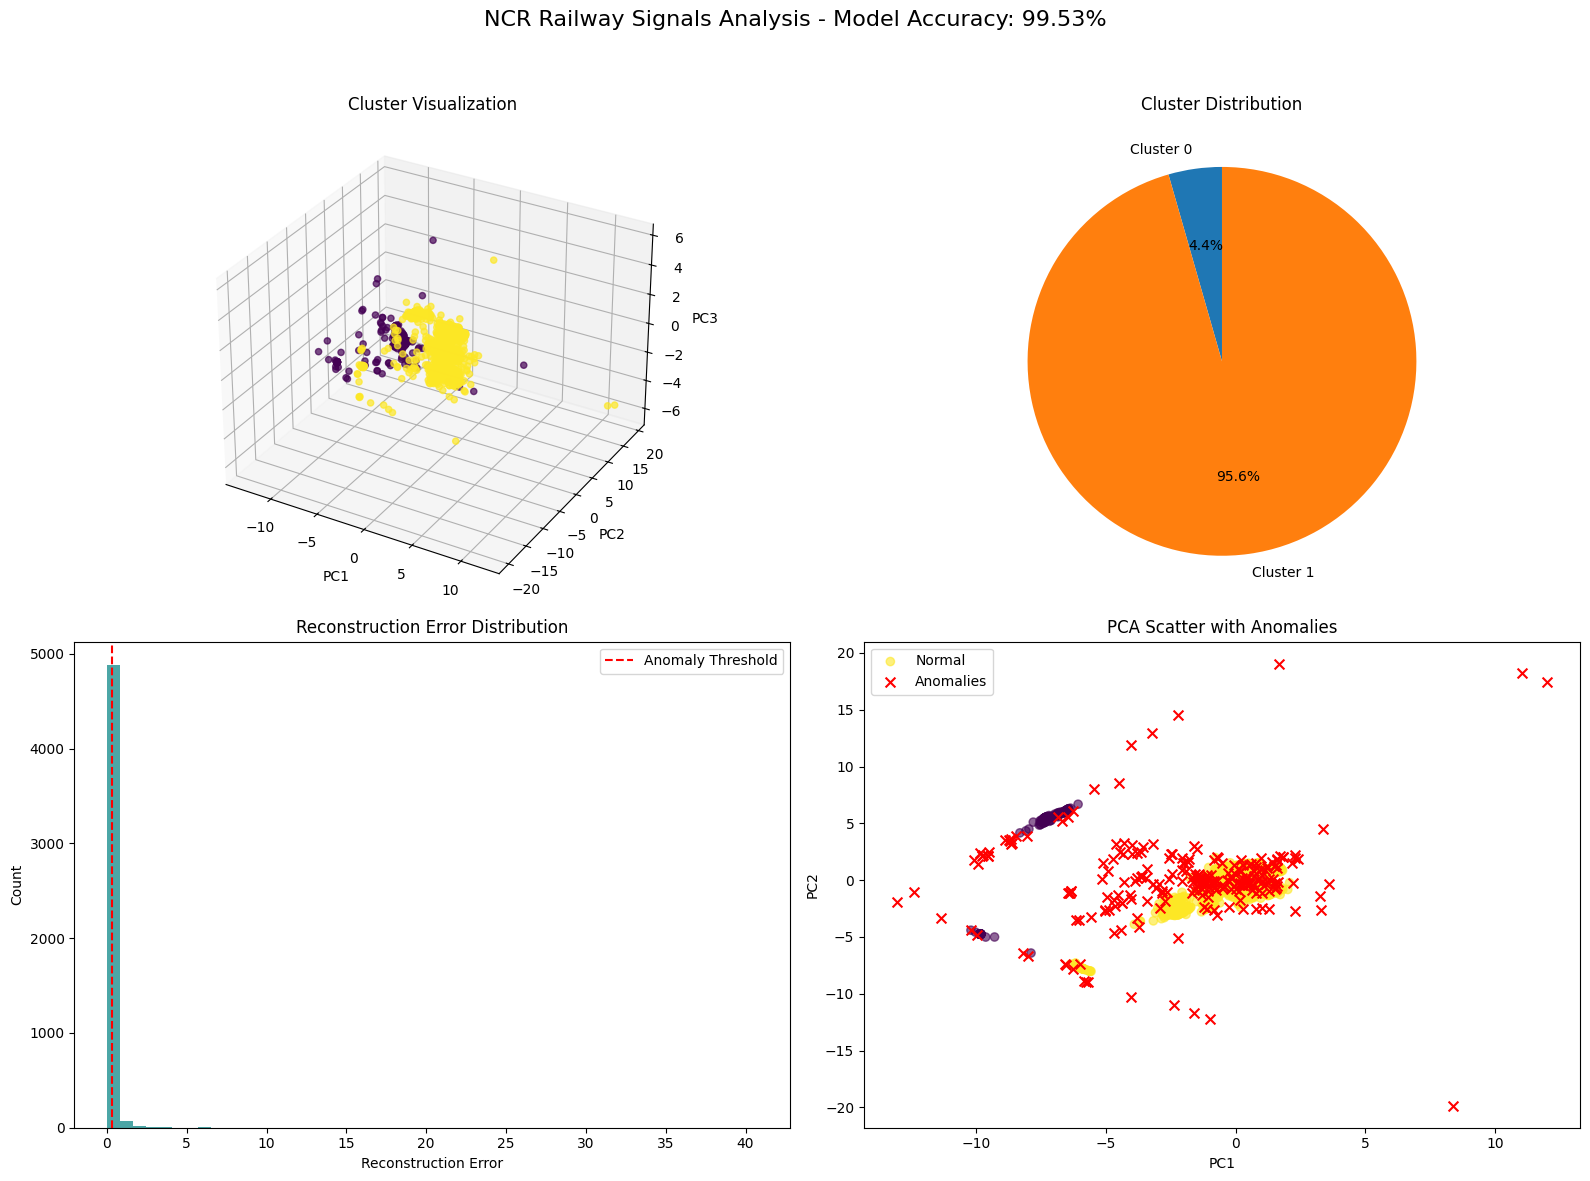


Processing NER from FEB 2025 Prototype data\NER.csv
Original dataset shape: (104215, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.63549927 0.28056969 0.04784849]
Total explained variance: 0.9639
K=2, Silhouette Score=0.6124
K=3, Silhouette Score=0.7170
K=4, Silhouette Score=0.6171
K=5, Silhouette Score=0.4600
K=6, Silhouette Score=0.4759
K=7, Silhouette Score=0.3947
K=8, Silhouette Score=0.4124
K=9, Silhouette Score=0.4077
K=10, Silhouette Score=0.4005


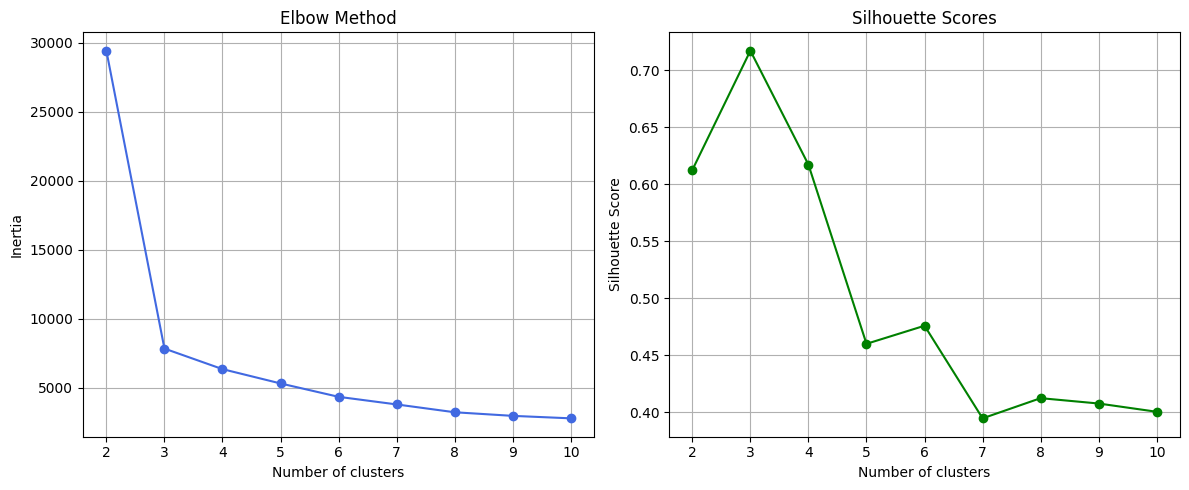

Optimal number of clusters: 3


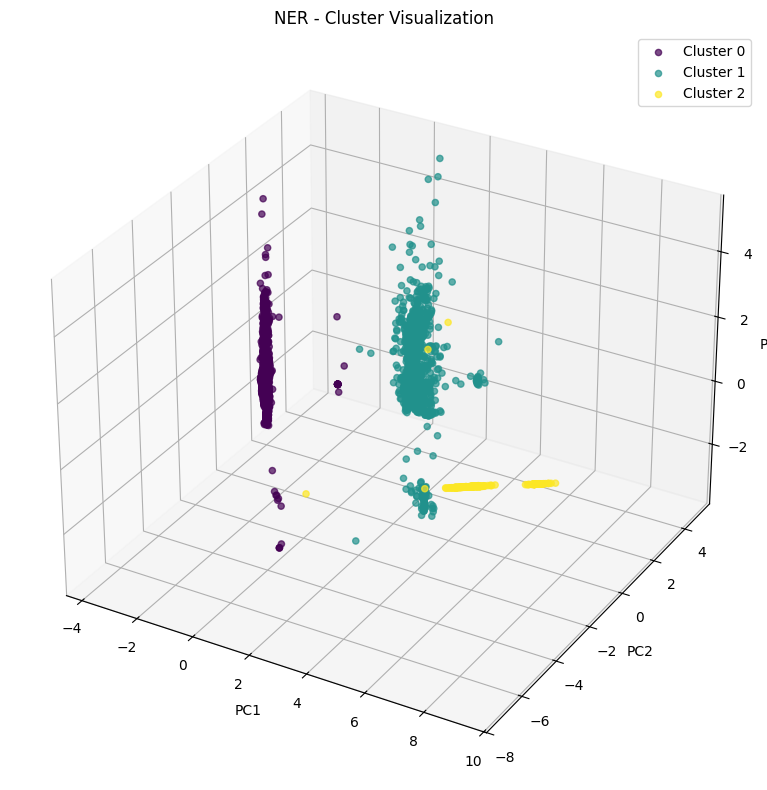

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.6101 - val_loss: 0.2761
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2488 - val_loss: 0.0867
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1164 - val_loss: 0.0642
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0995 - val_loss: 0.0557
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0817 - val_loss: 0.0431
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0770 - val_loss: 0.0539
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0678 - val_loss: 0.0369
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0629 - val_loss: 0.0370
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0594 - val_loss: 0.0384
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0551 - val_loss: 0.0428
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0505 - val_loss: 0.0352
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0470 - val_

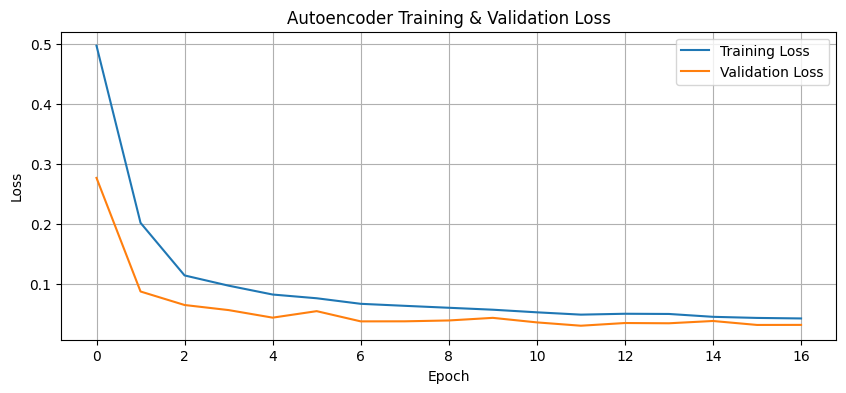

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Detected 250 anomalies out of 5000 data points


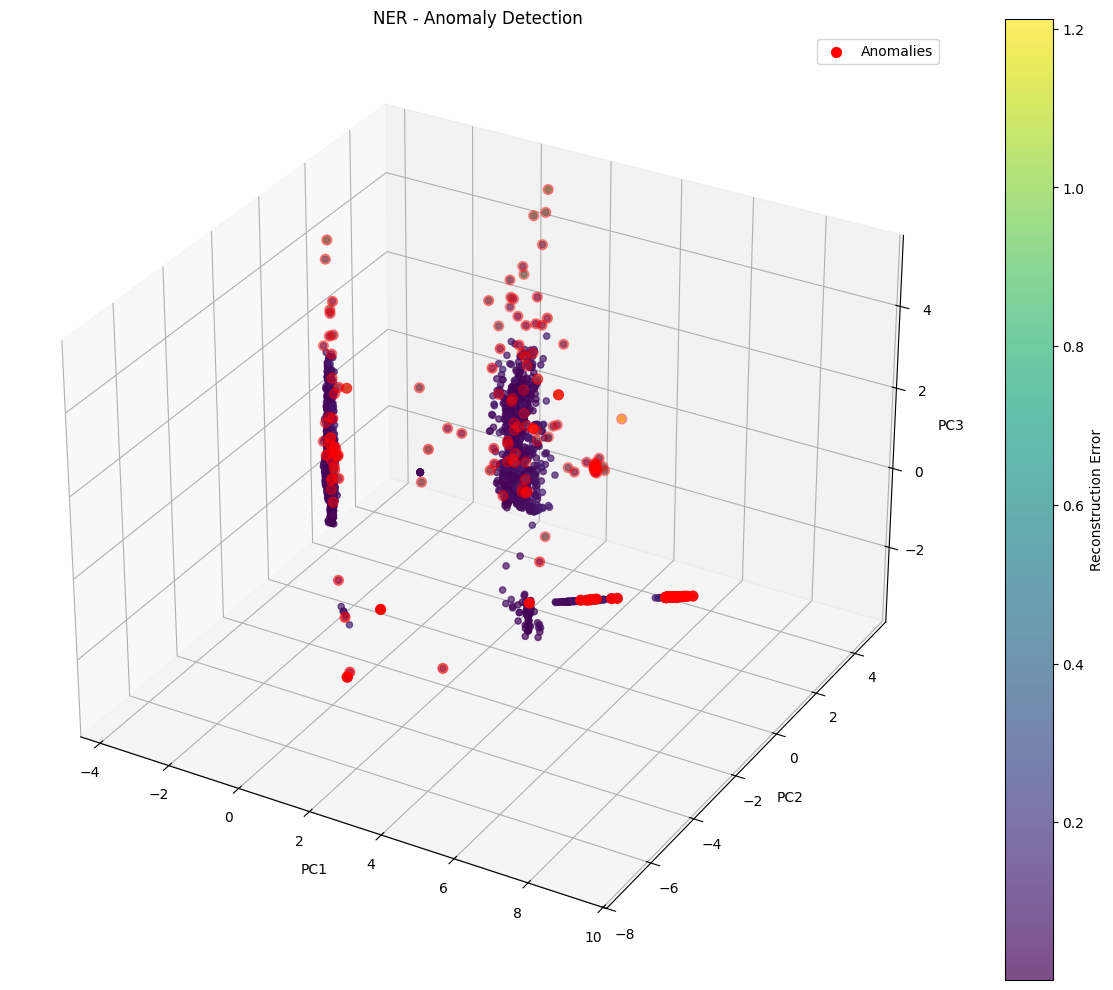

Training Accuracy: 1.0000
Testing Accuracy: 1.0000


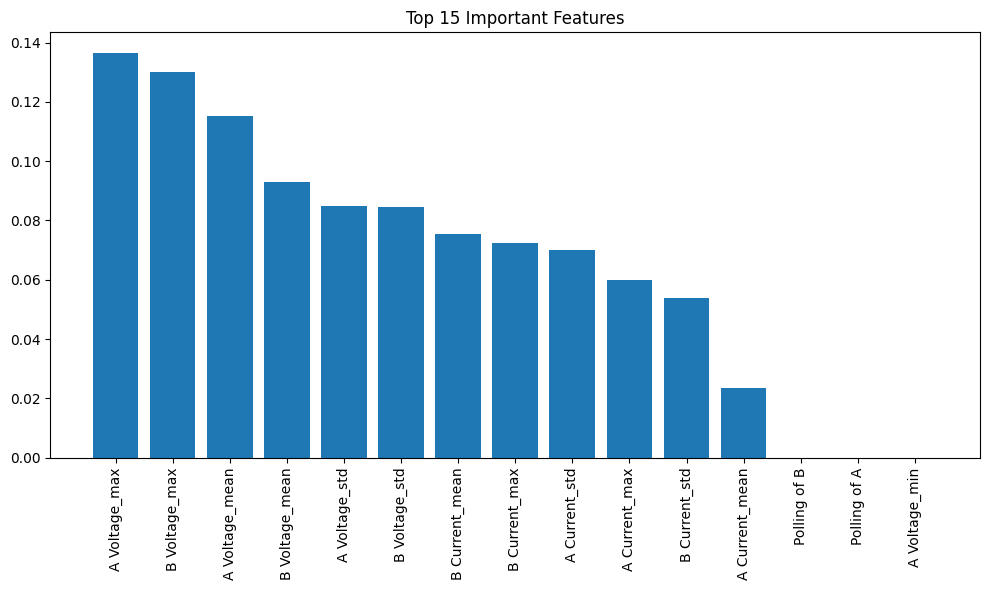

Top 5 important features for NER:
           Feature  Importance
7    A Voltage_max    0.136638
15   B Voltage_max    0.130107
6   A Voltage_mean    0.115257
14  B Voltage_mean    0.093138
9    A Voltage_std    0.084973


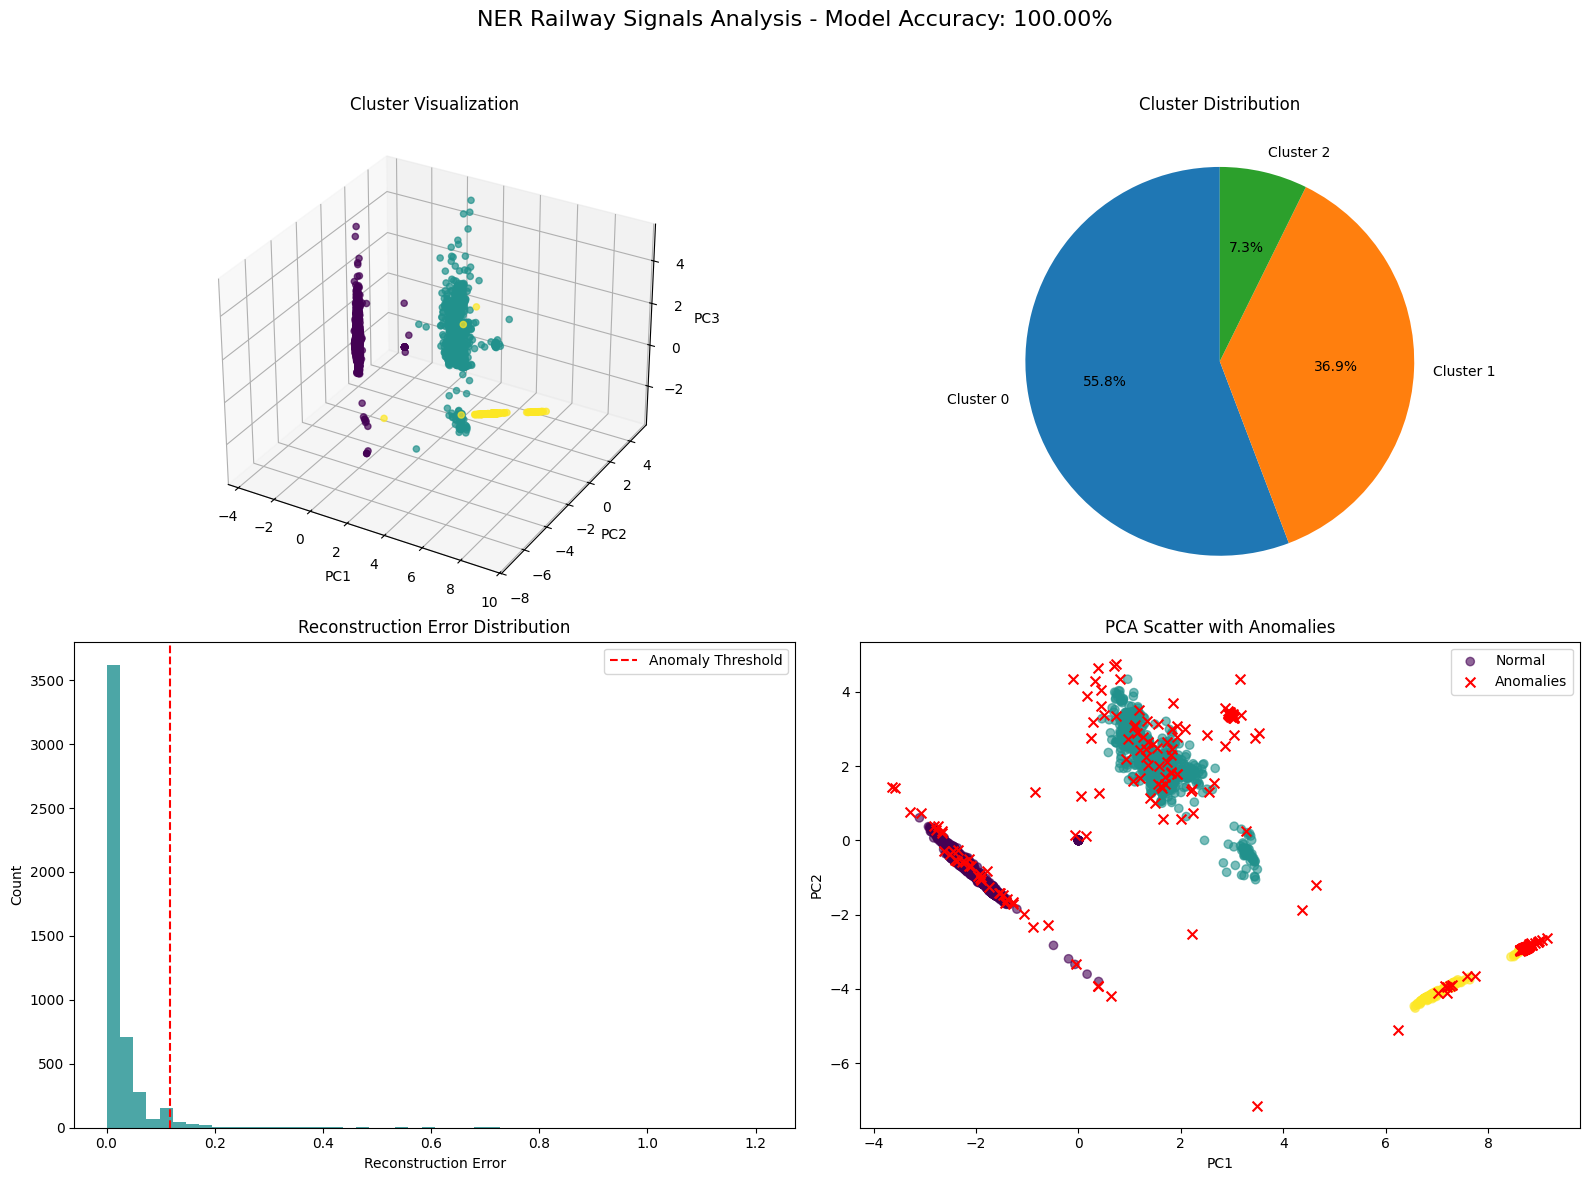


Processing NFR from FEB 2025 Prototype data\NFR.csv
Original dataset shape: (93138, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.38993432 0.26590985 0.147259  ]
Total explained variance: 0.8031
K=2, Silhouette Score=0.4707
K=3, Silhouette Score=0.5431
K=4, Silhouette Score=0.5952
K=5, Silhouette Score=0.6413
K=6, Silhouette Score=0.6394
K=7, Silhouette Score=0.6452
K=8, Silhouette Score=0.6517
K=9, Silhouette Score=0.5756
K=10, Silhouette Score=0.5844


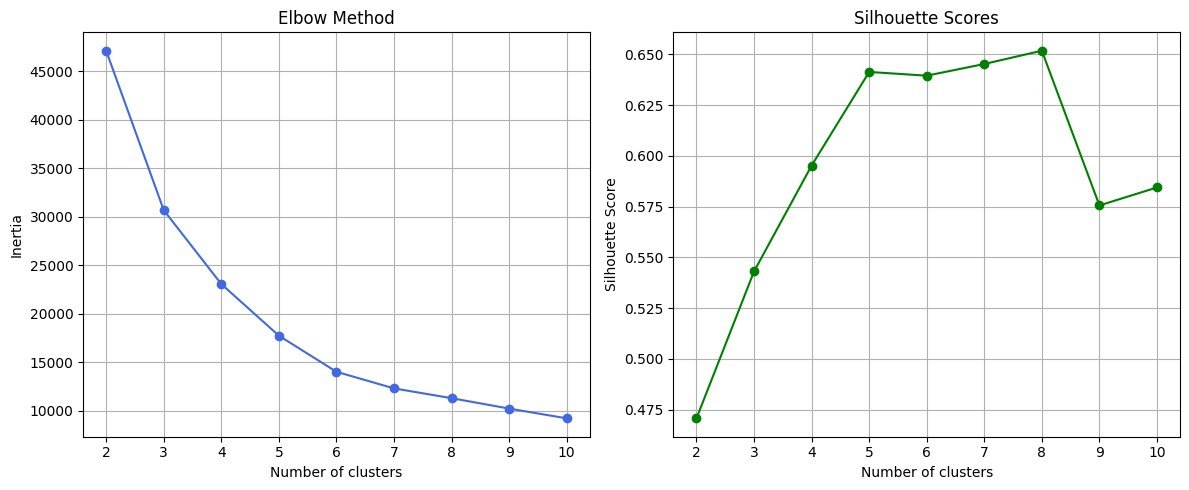

Optimal number of clusters: 8


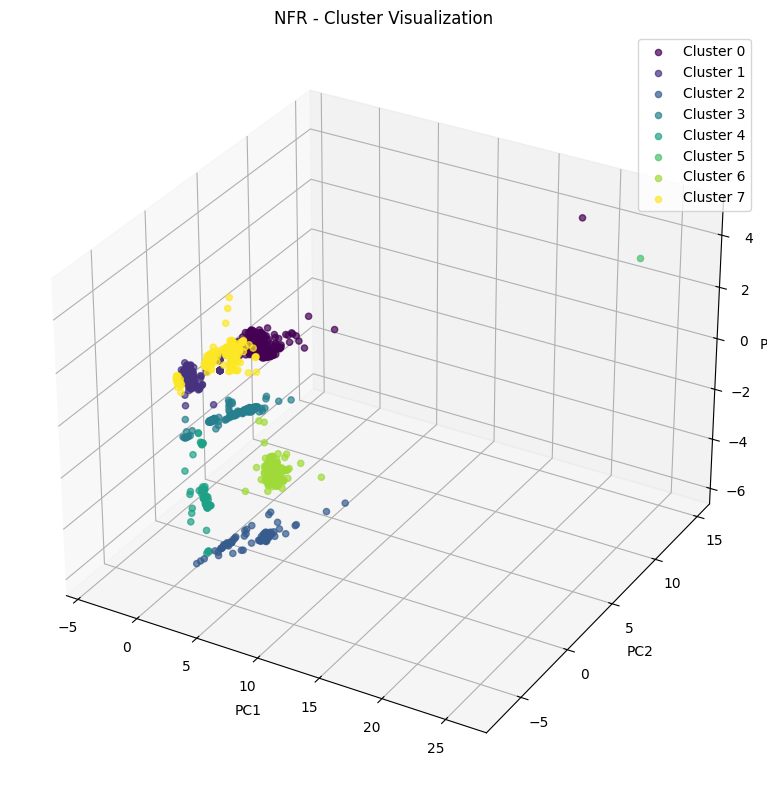

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.6277 - val_loss: 0.3328
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2668 - val_loss: 0.2285
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1878 - val_loss: 0.2230
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1830 - val_loss: 0.2061
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1522 - val_loss: 0.2049
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1363 - val_loss: 0.1914
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1325 - val_loss: 0.1996
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1187 - val_loss: 0.1964
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1220 - val_loss: 0.2006
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1218 - val_loss: 0.1968
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1080 - val_loss: 0.2024


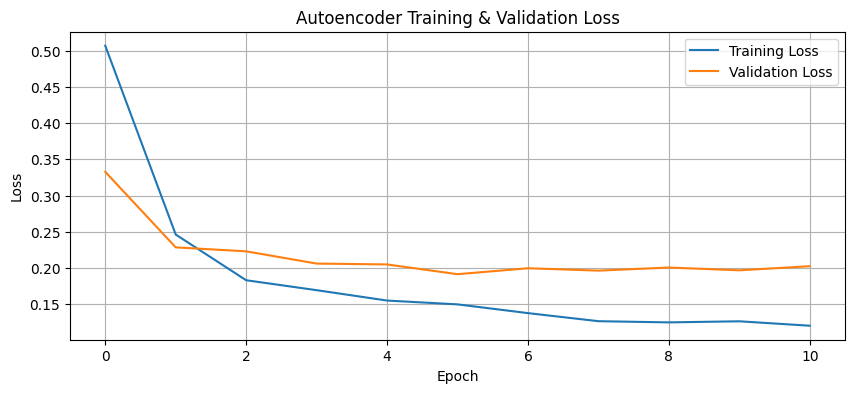

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Detected 250 anomalies out of 5000 data points


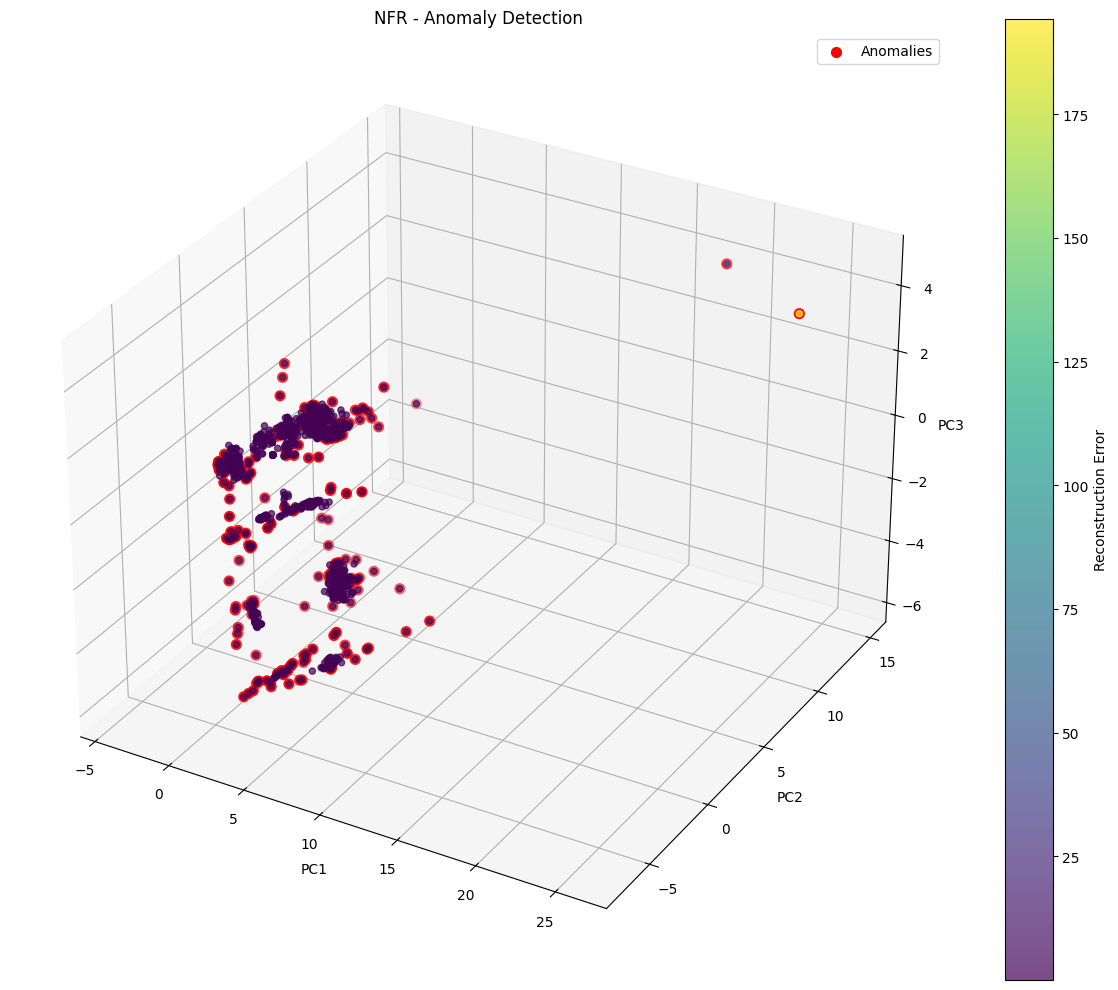

Error processing NFR: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Processing NR from FEB 2025 Prototype data\NR.csv


Traceback (most recent call last):
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_40536\1385230379.py", line 44, in process_region
    model, feature_importances, accuracy = evaluate_model(X_scaled, cluster_labels, feature_cols)
                                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_40536\3134214889.py", line 2, in evaluate_model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\PS1\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\PS1\venv\Lib\site-packages\sklearn\model_selection\_split.py", line 2872, in train_test_split
    train, test = next(cv.split(X=arr

Original dataset shape: (52334, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.69112269 0.12347643 0.07692454]
Total explained variance: 0.8915
K=2, Silhouette Score=0.9852
K=3, Silhouette Score=0.9834
K=4, Silhouette Score=0.9837
K=5, Silhouette Score=0.9754
K=6, Silhouette Score=0.9376
K=7, Silhouette Score=0.9371
K=8, Silhouette Score=0.9380
K=9, Silhouette Score=0.9388
K=10, Silhouette Score=0.9384


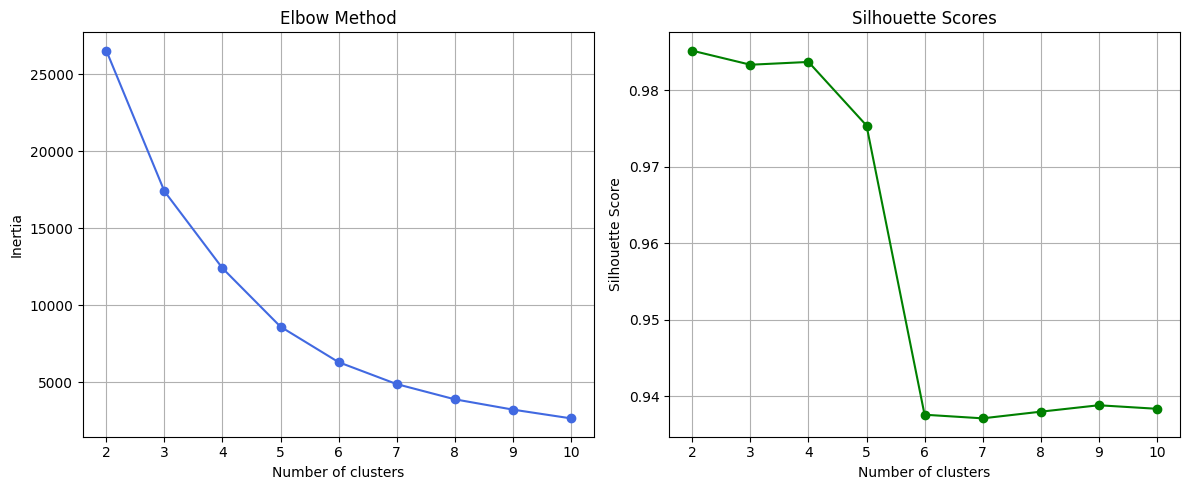

Optimal number of clusters: 2


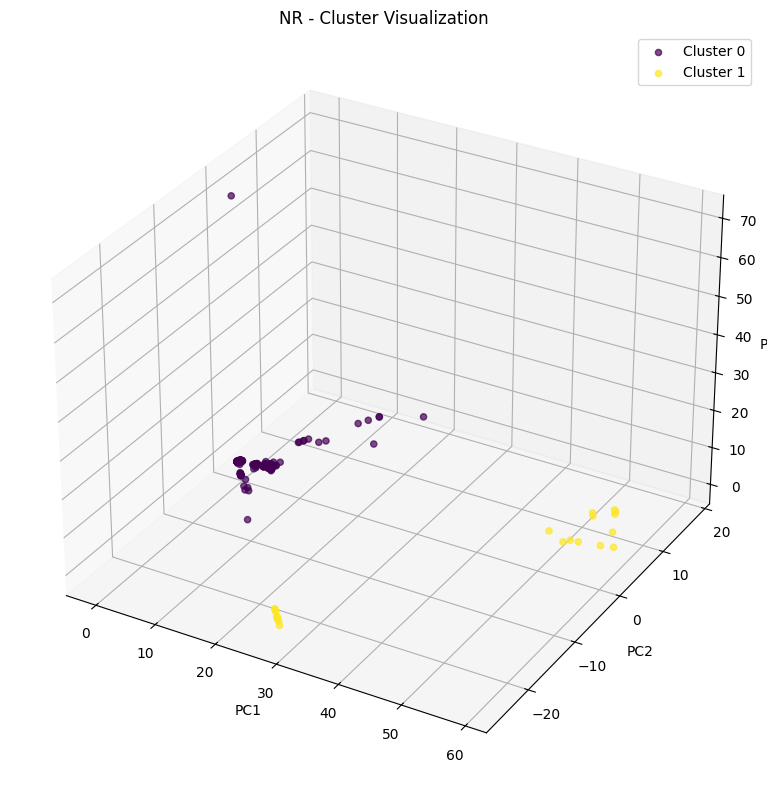

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.6707 - val_loss: 0.8275
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6235 - val_loss: 0.4360
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2668 - val_loss: 0.4477
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2862 - val_loss: 0.4099
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3258 - val_loss: 0.4733
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2219 - val_loss: 0.4431
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3121 - val_loss: 0.3955
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2829 - val_loss: 0.5905
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2558 - val_loss: 0.3884
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1744 - val_loss: 0.4005
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2559 - val_loss: 0.4229
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2448 - val_

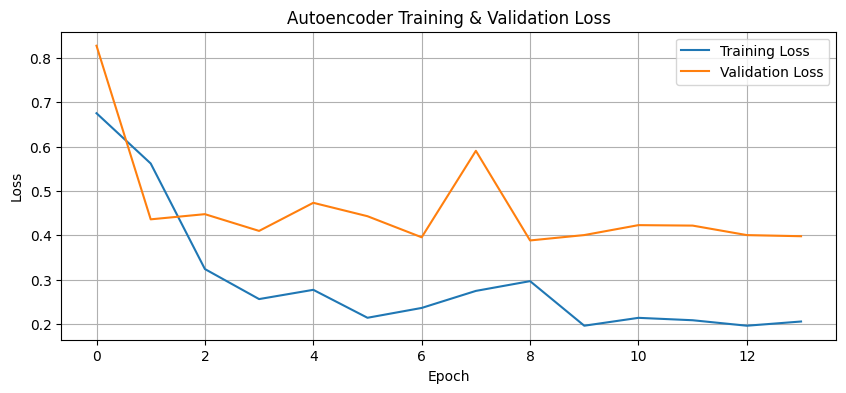

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Detected 250 anomalies out of 5000 data points


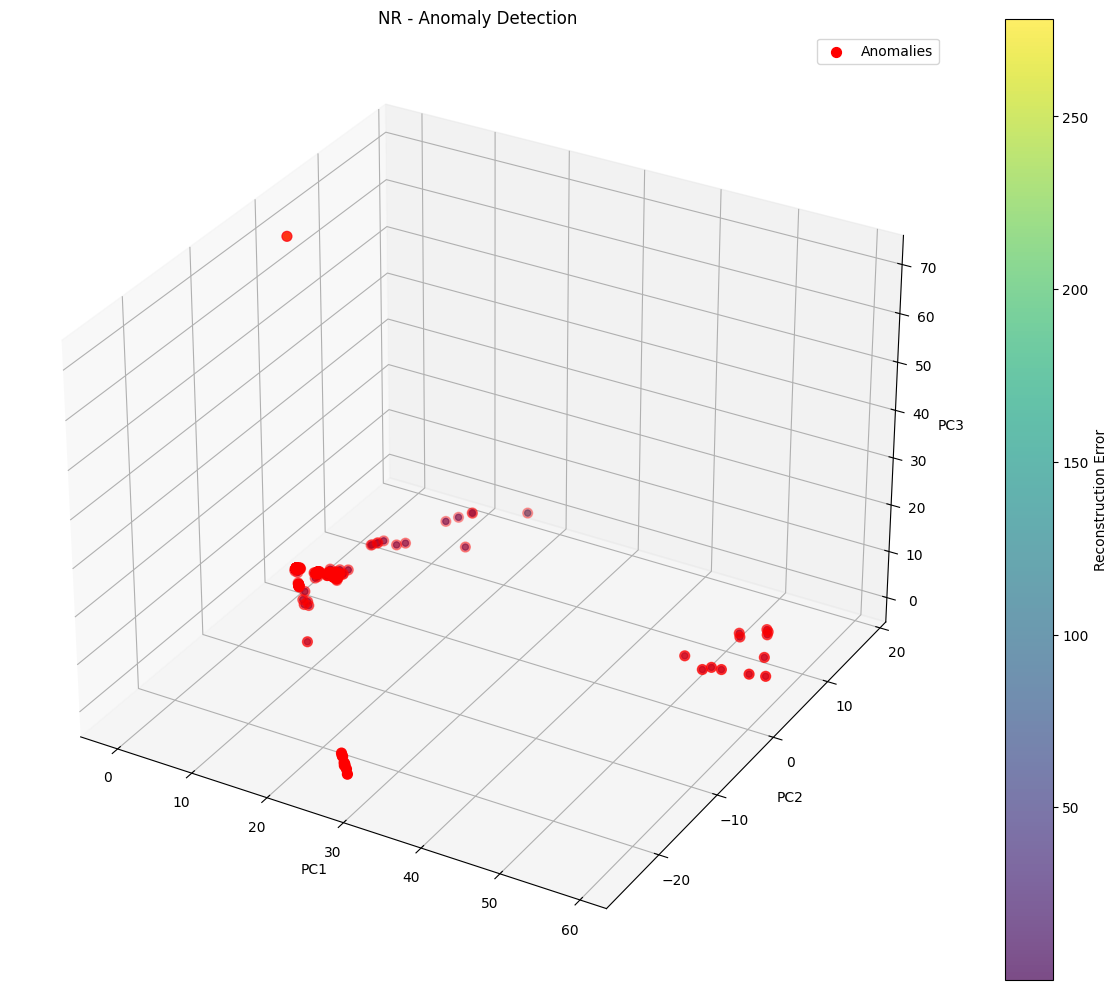

Training Accuracy: 1.0000
Testing Accuracy: 1.0000


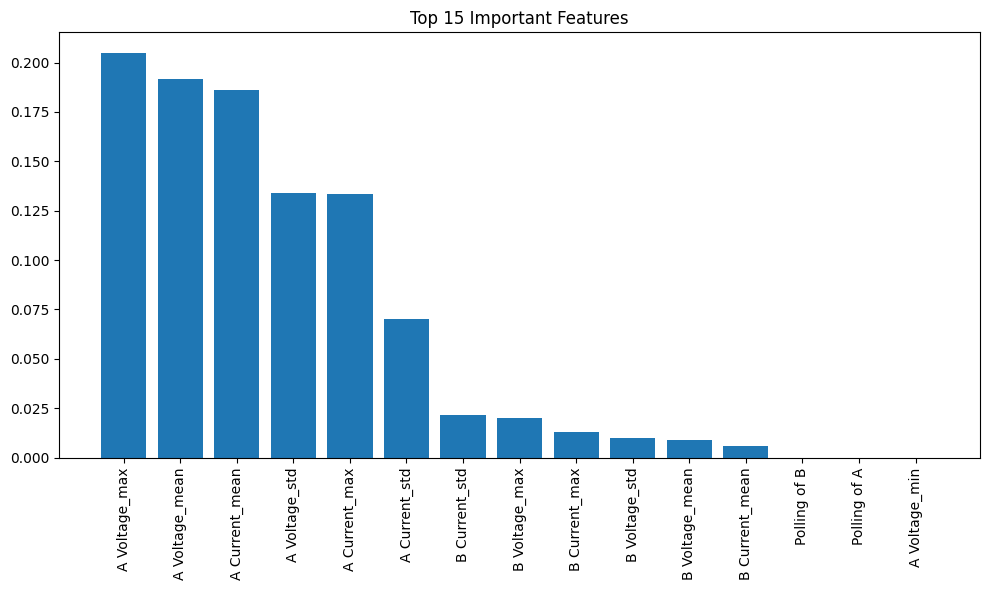

Top 5 important features for NR:
          Feature  Importance
7   A Voltage_max    0.205034
6  A Voltage_mean    0.191892
2  A Current_mean    0.185947
9   A Voltage_std    0.134070
3   A Current_max    0.133293


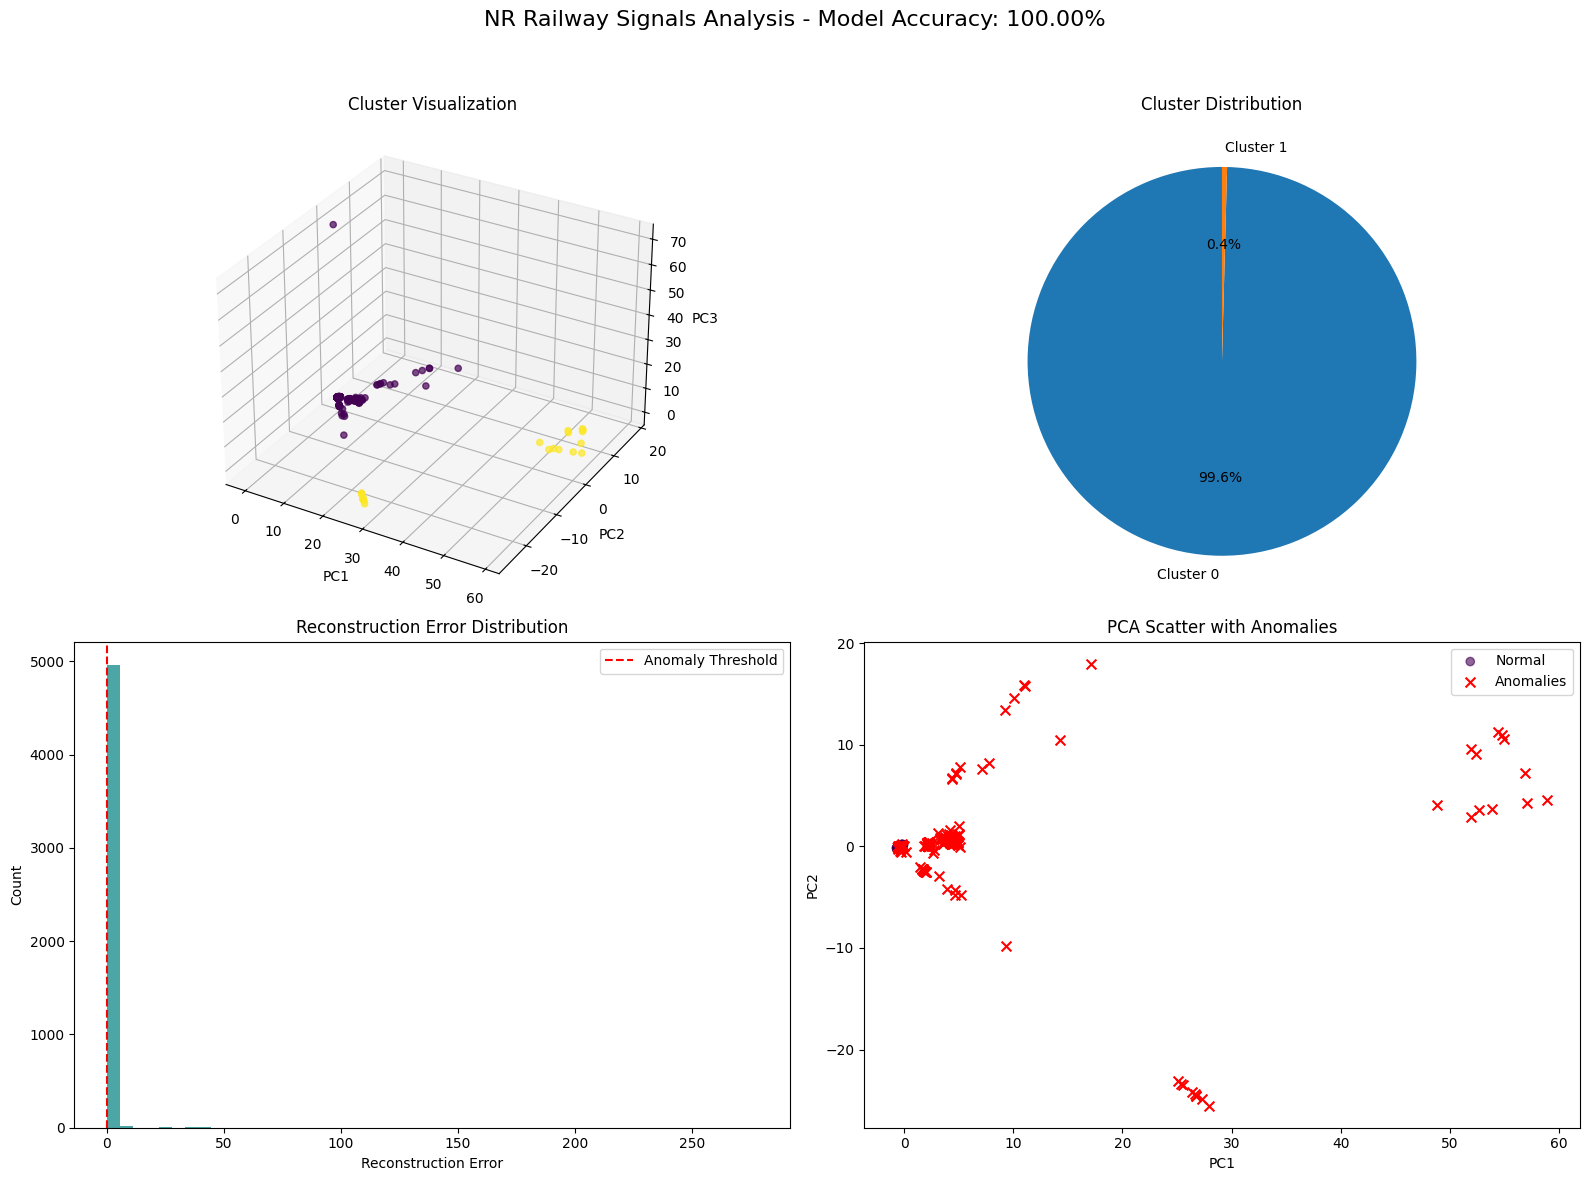


Processing SCR from FEB 2025 Prototype data\SCR.csv
Original dataset shape: (714, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (714, 18)
Explained variance: [0.40077897 0.25479861 0.12518503]
Total explained variance: 0.7808
K=2, Silhouette Score=0.4884
K=3, Silhouette Score=0.6473
K=4, Silhouette Score=0.6553
K=5, Silhouette Score=0.6667
K=6, Silhouette Score=0.6742
K=7, Silhouette Score=0.6717
K=8, Silhouette Score=0.6675
K=9, Silhouette Score=0.6351
K=10, Silhouette Score=0.6155


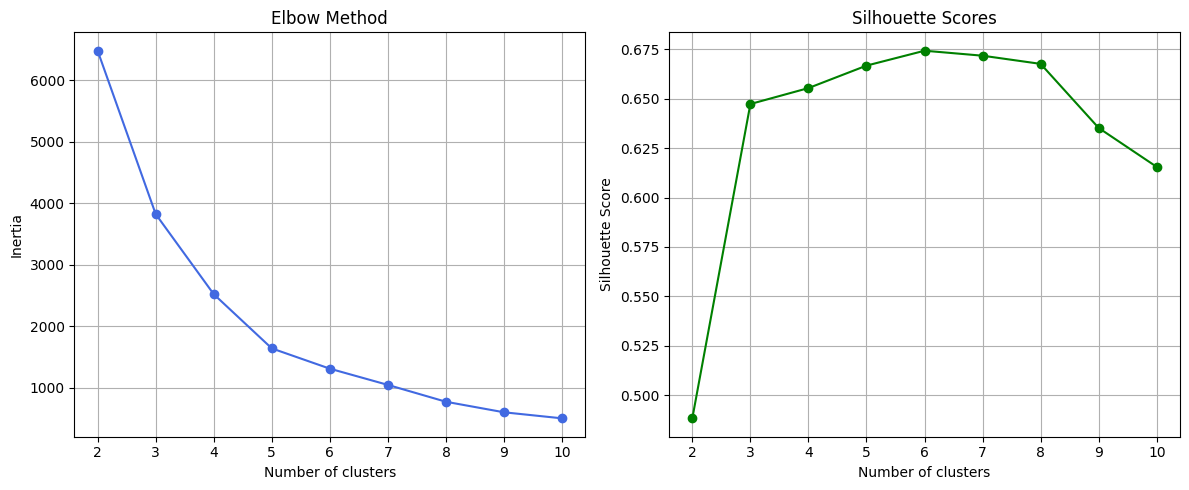

Optimal number of clusters: 6


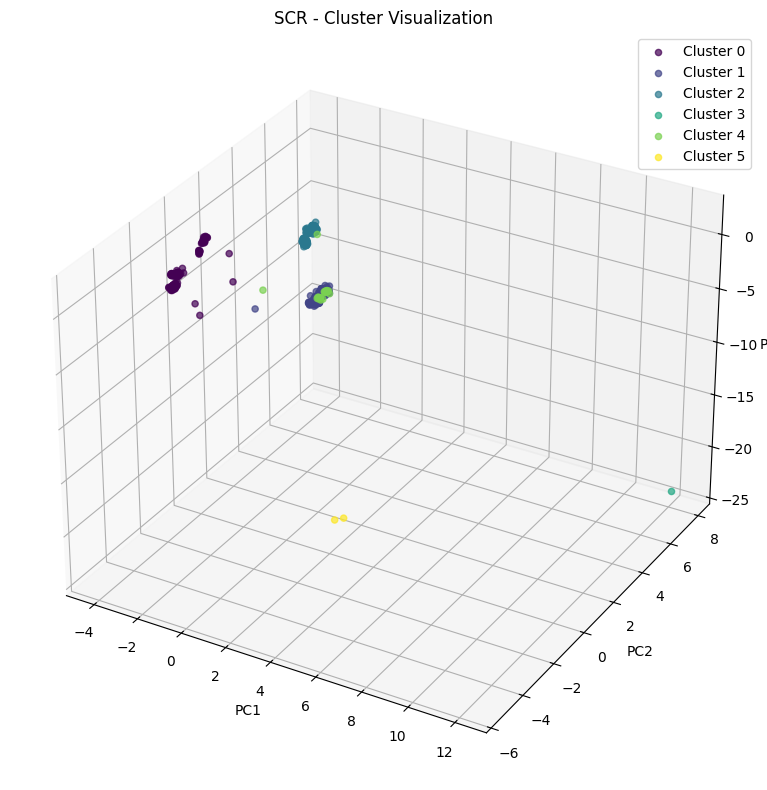

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.7409 - val_loss: 0.5373
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6910 - val_loss: 0.3991
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6593 - val_loss: 0.2482
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3721 - val_loss: 0.1619
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5169 - val_loss: 0.1385
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3122 - val_loss: 0.1312
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3427 - val_loss: 0.1175
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5151 - val_loss: 0.1093
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2495 - val_loss: 0.1041
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3302 - val_loss: 0.1010
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2430 - val_loss: 0.1031
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4214 - val_loss: 0.1059
E

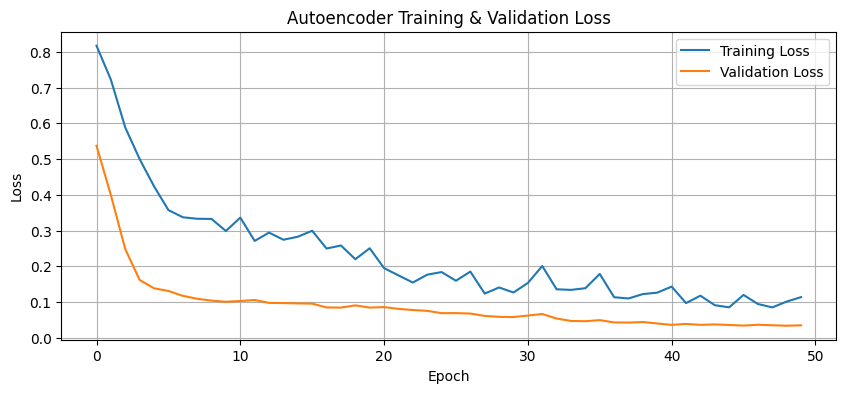

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Detected 36 anomalies out of 714 data points


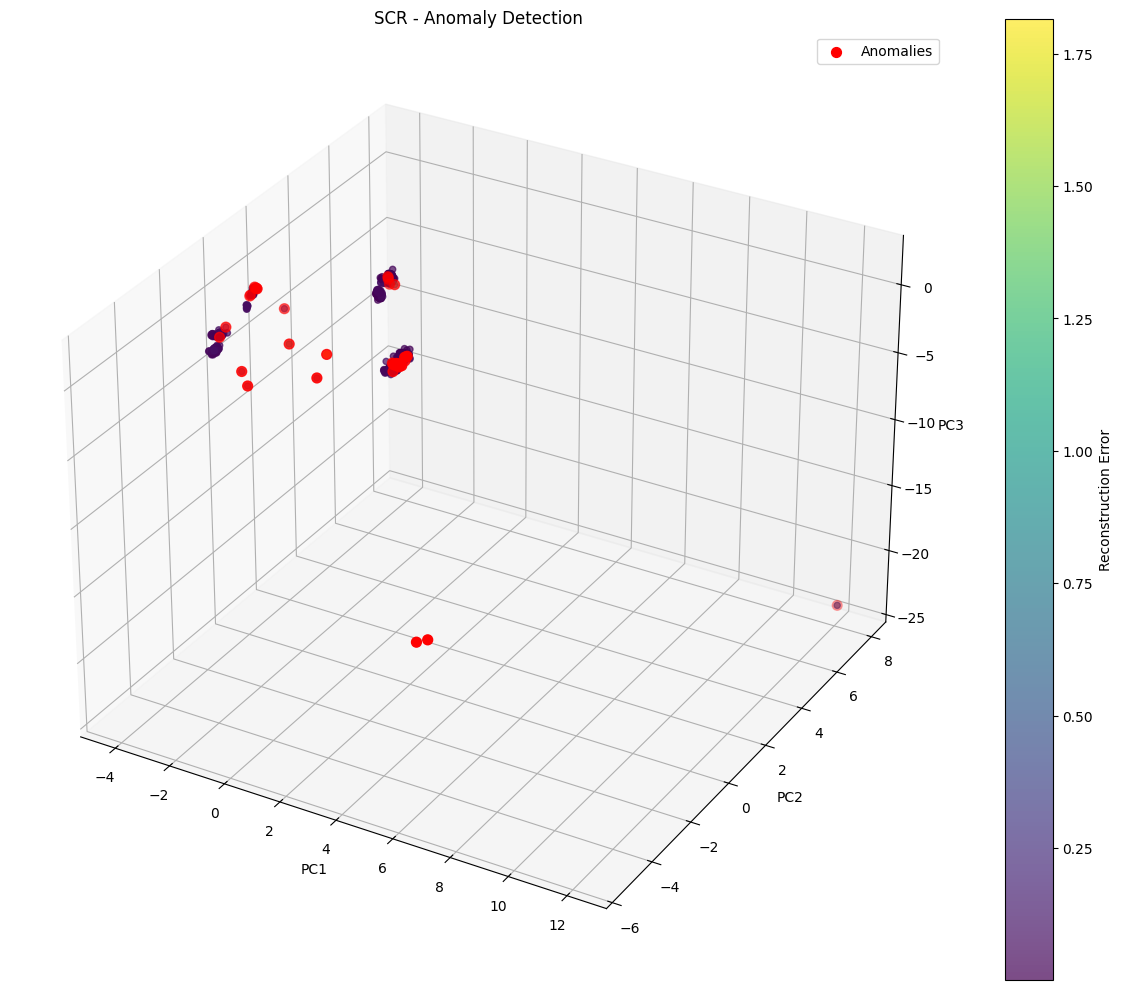

Error processing SCR: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Processing SECR from FEB 2025 Prototype data\SECR.csv


Traceback (most recent call last):
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_40536\1385230379.py", line 44, in process_region
    model, feature_importances, accuracy = evaluate_model(X_scaled, cluster_labels, feature_cols)
                                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_40536\3134214889.py", line 2, in evaluate_model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\PS1\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\PS1\venv\Lib\site-packages\sklearn\model_selection\_split.py", line 2872, in train_test_split
    train, test = next(cv.split(X=arr

Original dataset shape: (135962, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.33918736 0.1997518  0.19612605]
Total explained variance: 0.7351
K=2, Silhouette Score=0.9594
K=3, Silhouette Score=0.9597
K=4, Silhouette Score=0.8503
K=5, Silhouette Score=0.5471
K=6, Silhouette Score=0.5547
K=7, Silhouette Score=0.5597
K=8, Silhouette Score=0.5648
K=9, Silhouette Score=0.6030
K=10, Silhouette Score=0.6031


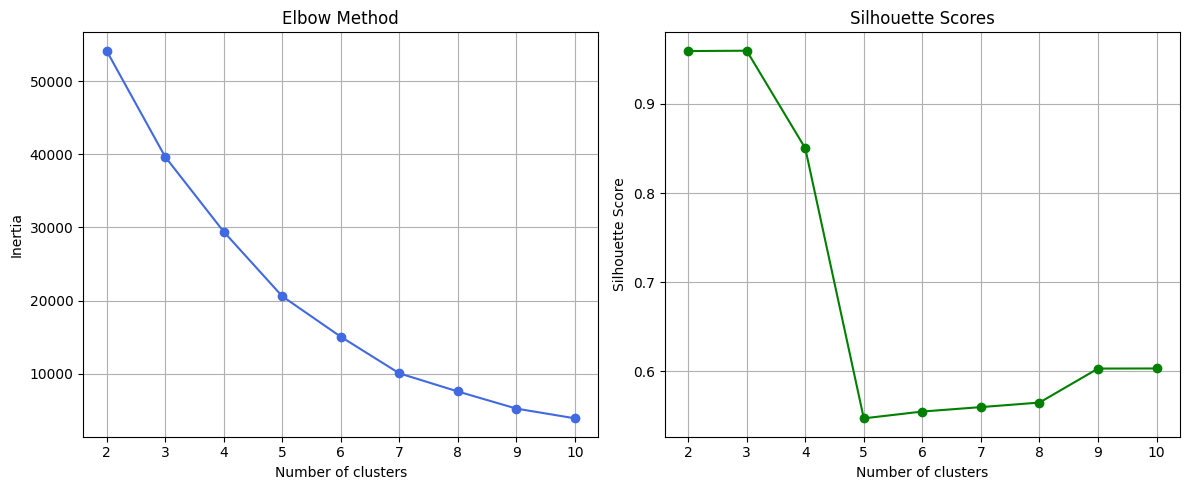

Optimal number of clusters: 3


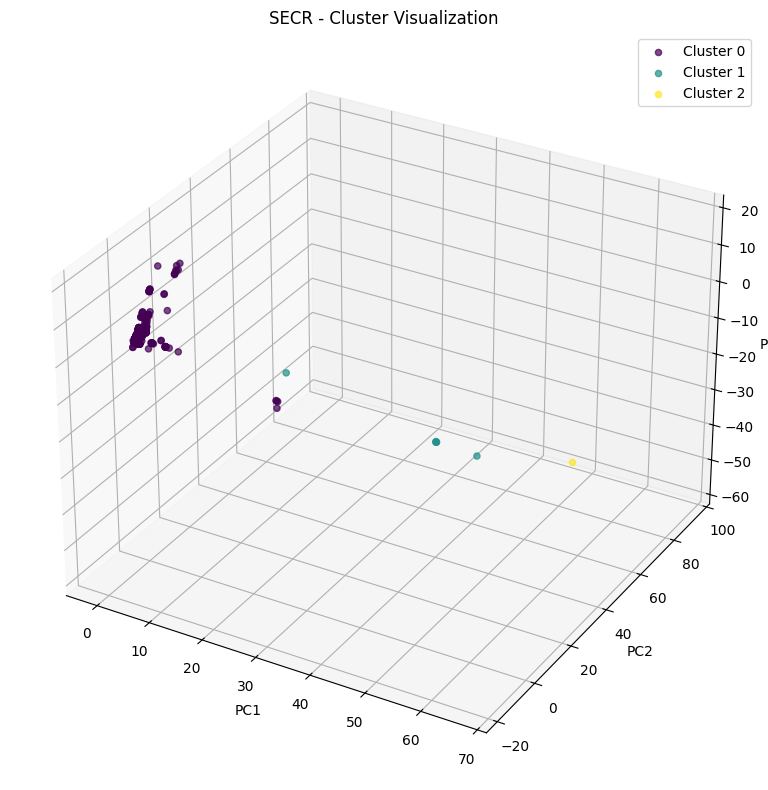

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.3954 - val_loss: 0.4737
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9422 - val_loss: 0.3849
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4441 - val_loss: 0.3492
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5921 - val_loss: 0.3600
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4787 - val_loss: 0.3363
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3519 - val_loss: 0.3256
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4224 - val_loss: 0.3111
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3667 - val_loss: 0.2757
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2956 - val_loss: 0.2858
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5036 - val_loss: 0.2862
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2892 - val_loss: 0.2518
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2289 - val_

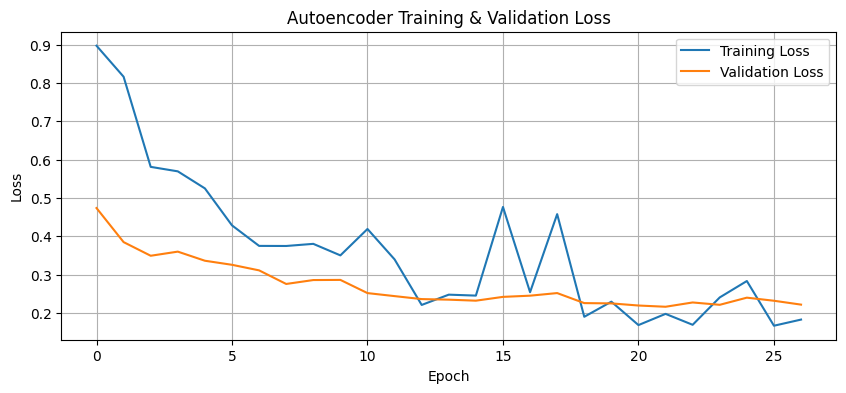

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Detected 250 anomalies out of 5000 data points


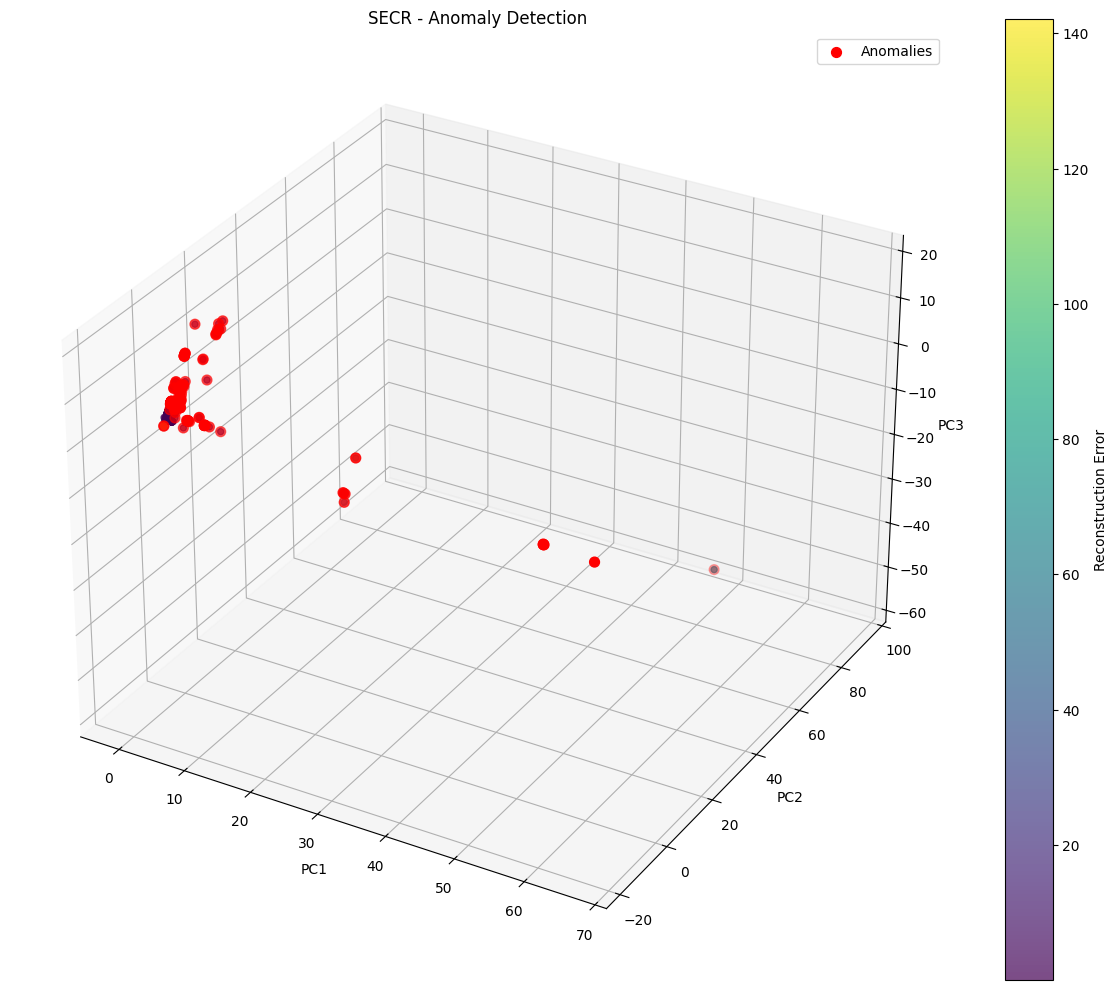

Error processing SECR: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Processing SR from FEB 2025 Prototype data\SR.csv


Traceback (most recent call last):
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_40536\1385230379.py", line 44, in process_region
    model, feature_importances, accuracy = evaluate_model(X_scaled, cluster_labels, feature_cols)
                                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_40536\3134214889.py", line 2, in evaluate_model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\PS1\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\PS1\venv\Lib\site-packages\sklearn\model_selection\_split.py", line 2872, in train_test_split
    train, test = next(cv.split(X=arr

Original dataset shape: (230590, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.4138606  0.24253828 0.13995647]
Total explained variance: 0.7964
K=2, Silhouette Score=0.9094
K=3, Silhouette Score=0.9025
K=4, Silhouette Score=0.6030
K=5, Silhouette Score=0.6039
K=6, Silhouette Score=0.7238
K=7, Silhouette Score=0.7243
K=8, Silhouette Score=0.7255
K=9, Silhouette Score=0.7257
K=10, Silhouette Score=0.7441


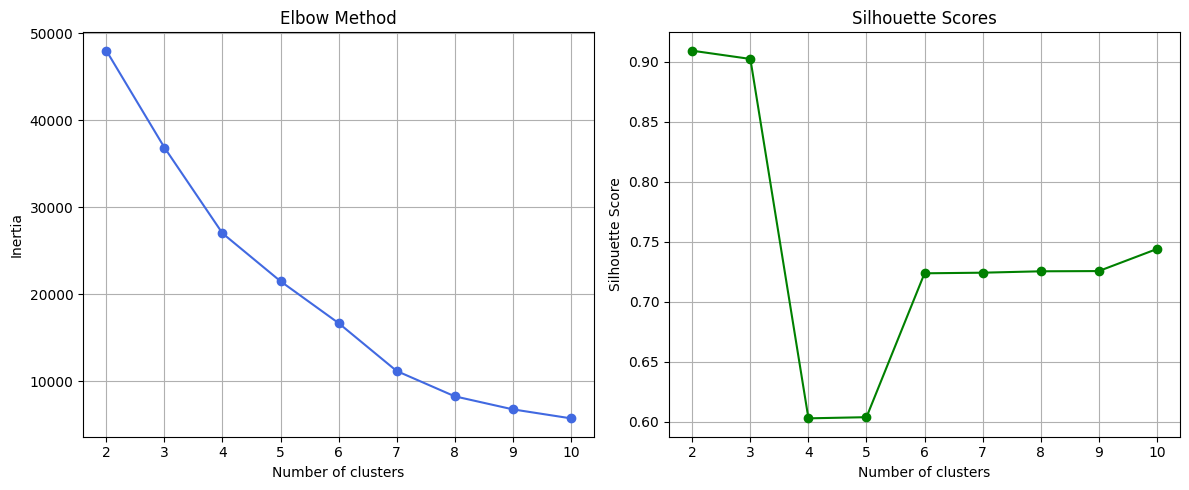

Optimal number of clusters: 2


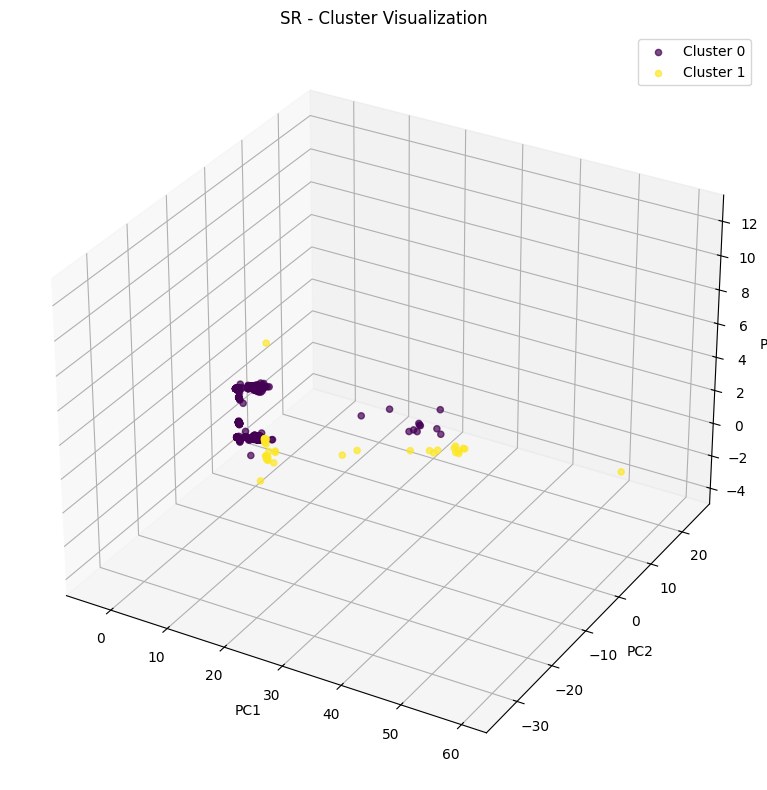

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.8582 - val_loss: 0.6049
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2633 - val_loss: 0.3735
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5497 - val_loss: 0.2893
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3083 - val_loss: 0.3120
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4421 - val_loss: 0.2327
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4741 - val_loss: 0.2534
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1627 - val_loss: 0.2211
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2375 - val_loss: 0.2618
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1764 - val_loss: 0.2269
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2644 - val_loss: 0.2944
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2400 - val_loss: 0.2477
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3077 - val_

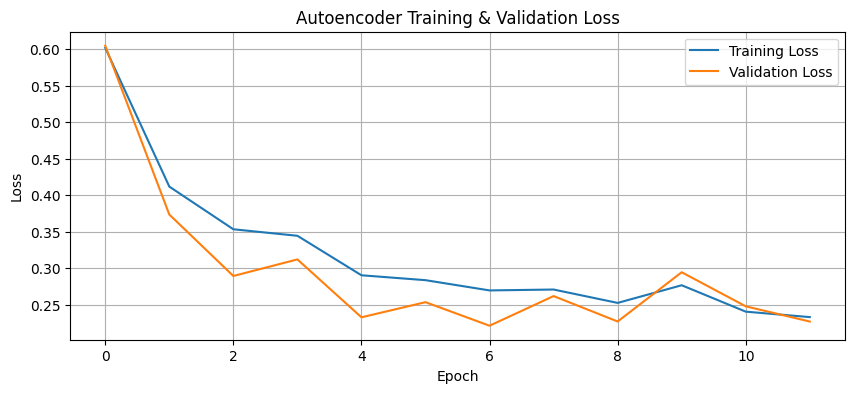

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Detected 250 anomalies out of 5000 data points


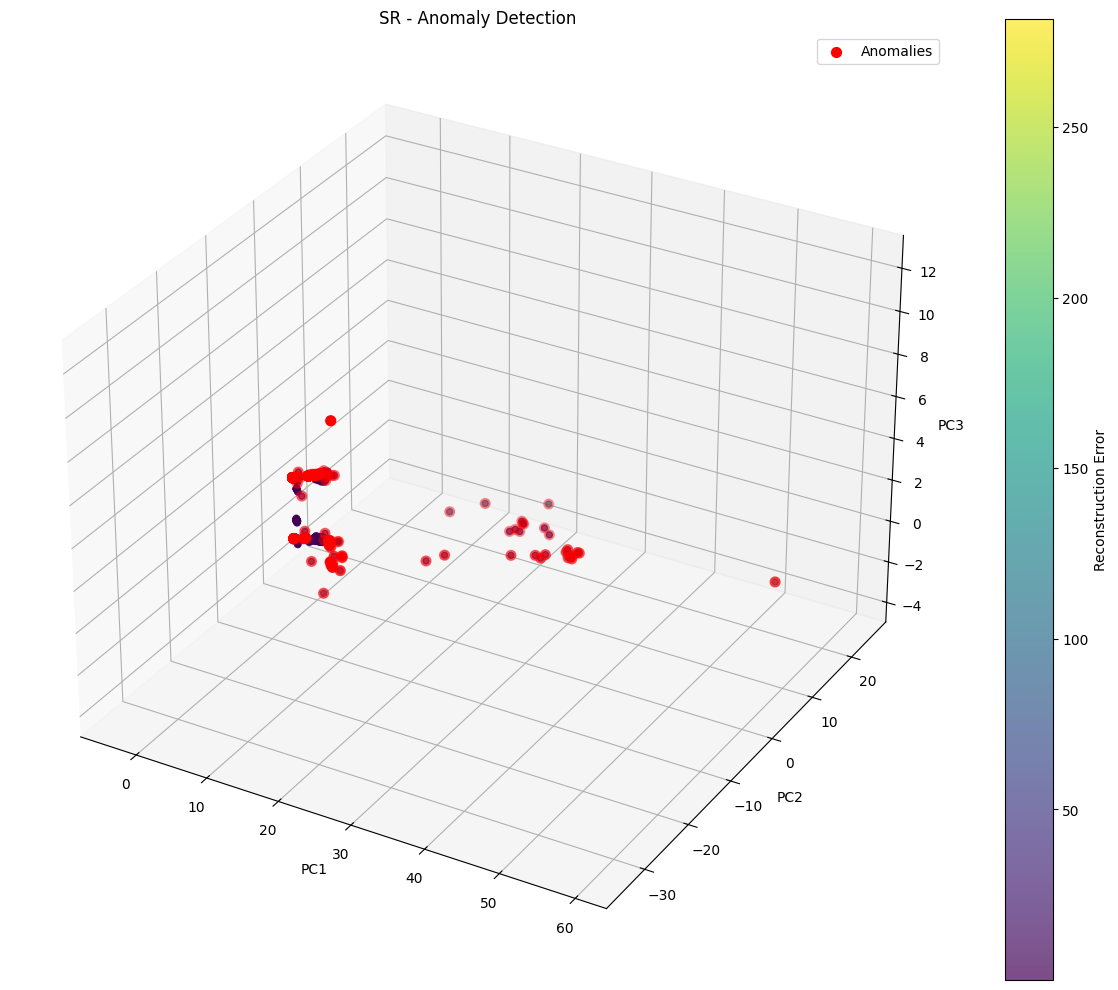

Training Accuracy: 0.9997
Testing Accuracy: 1.0000


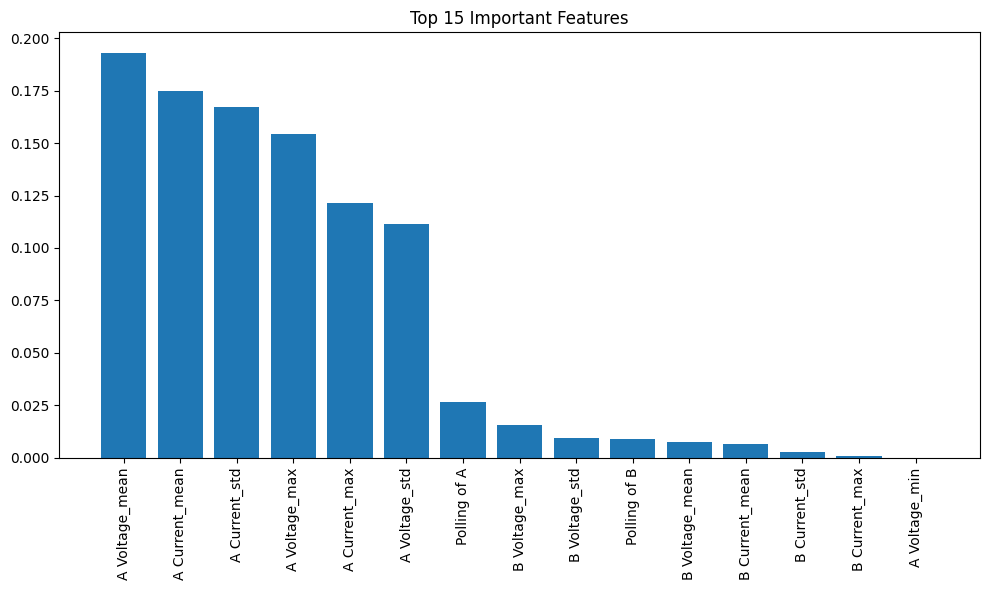

Top 5 important features for SR:
          Feature  Importance
6  A Voltage_mean    0.193207
2  A Current_mean    0.174889
5   A Current_std    0.167286
7   A Voltage_max    0.154394
3   A Current_max    0.121338


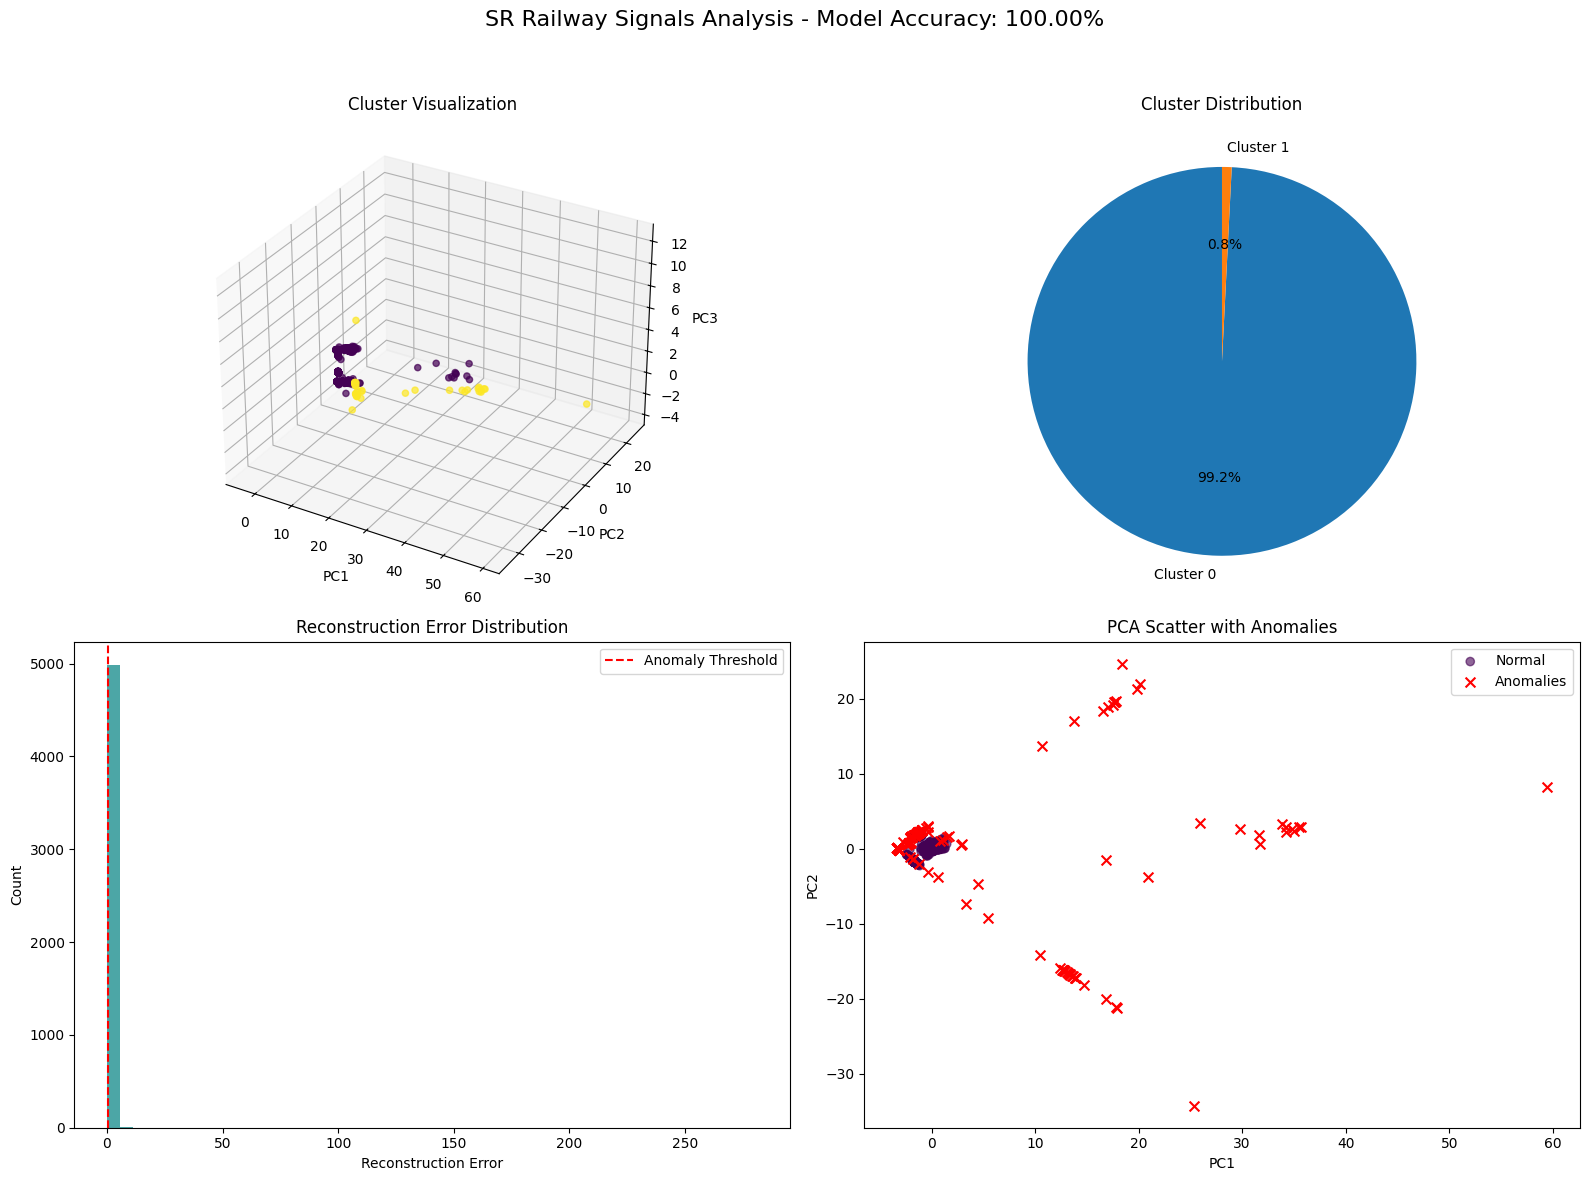


Processing WCR from FEB 2025 Prototype data\WCR.csv
Original dataset shape: (17876, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.71422149 0.12537411 0.06251856]
Total explained variance: 0.9021
K=2, Silhouette Score=0.9899
K=3, Silhouette Score=0.9152
K=4, Silhouette Score=0.9153
K=5, Silhouette Score=0.9176
K=6, Silhouette Score=0.9174
K=7, Silhouette Score=0.9173
K=8, Silhouette Score=0.9174
K=9, Silhouette Score=0.9173
K=10, Silhouette Score=0.9179


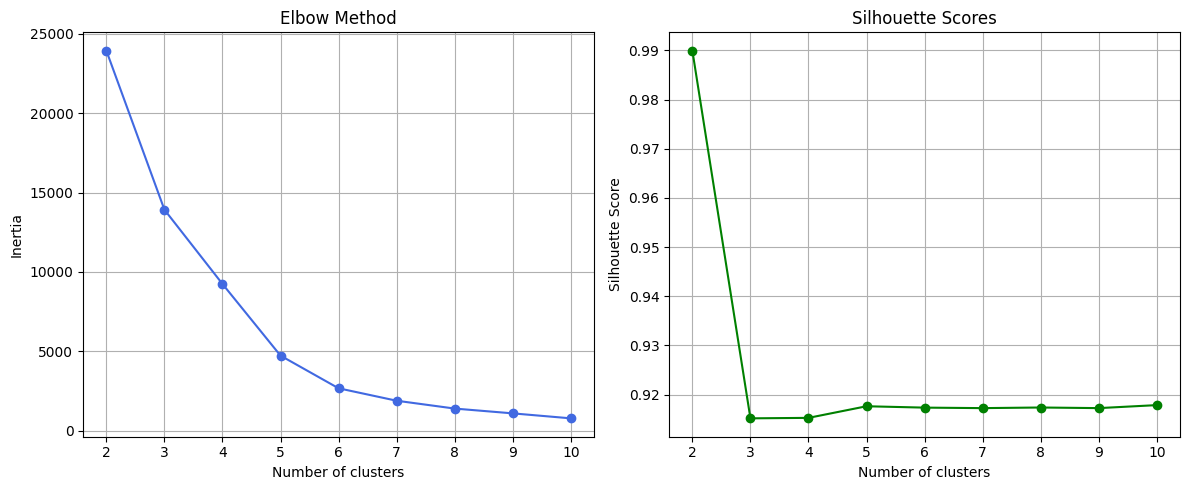

Optimal number of clusters: 2


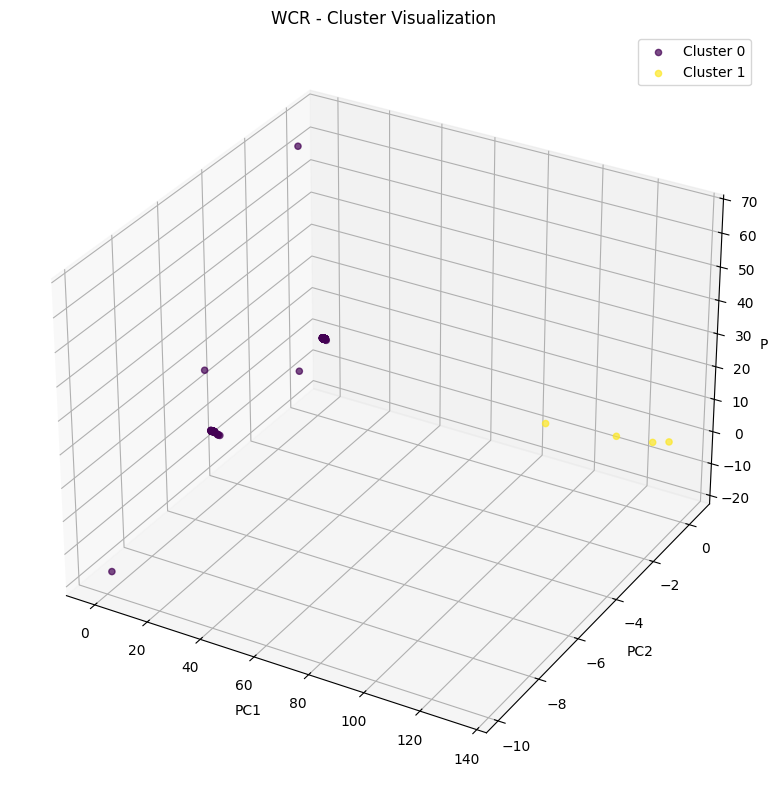

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.9079 - val_loss: 0.6441
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3642 - val_loss: 0.6395
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.6962 - val_loss: 0.6391
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3854 - val_loss: 0.6382
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5831 - val_loss: 0.6487
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9472 - val_loss: 0.6389
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6473 - val_loss: 0.6397
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9325 - val_loss: 0.6382
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8897 - val_loss: 0.6398


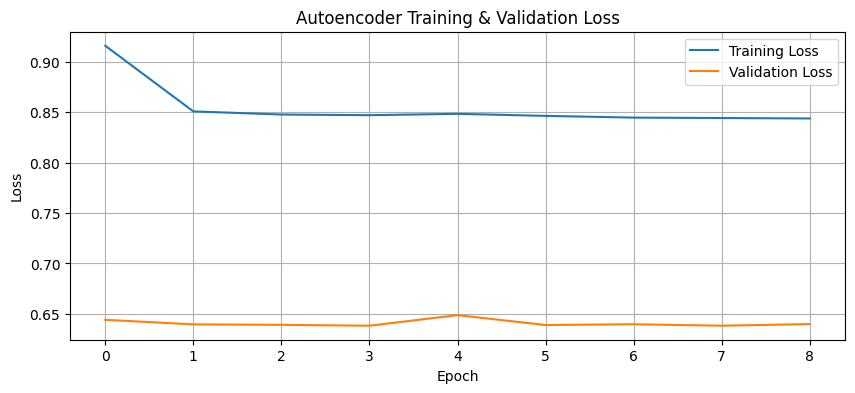

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Detected 250 anomalies out of 5000 data points


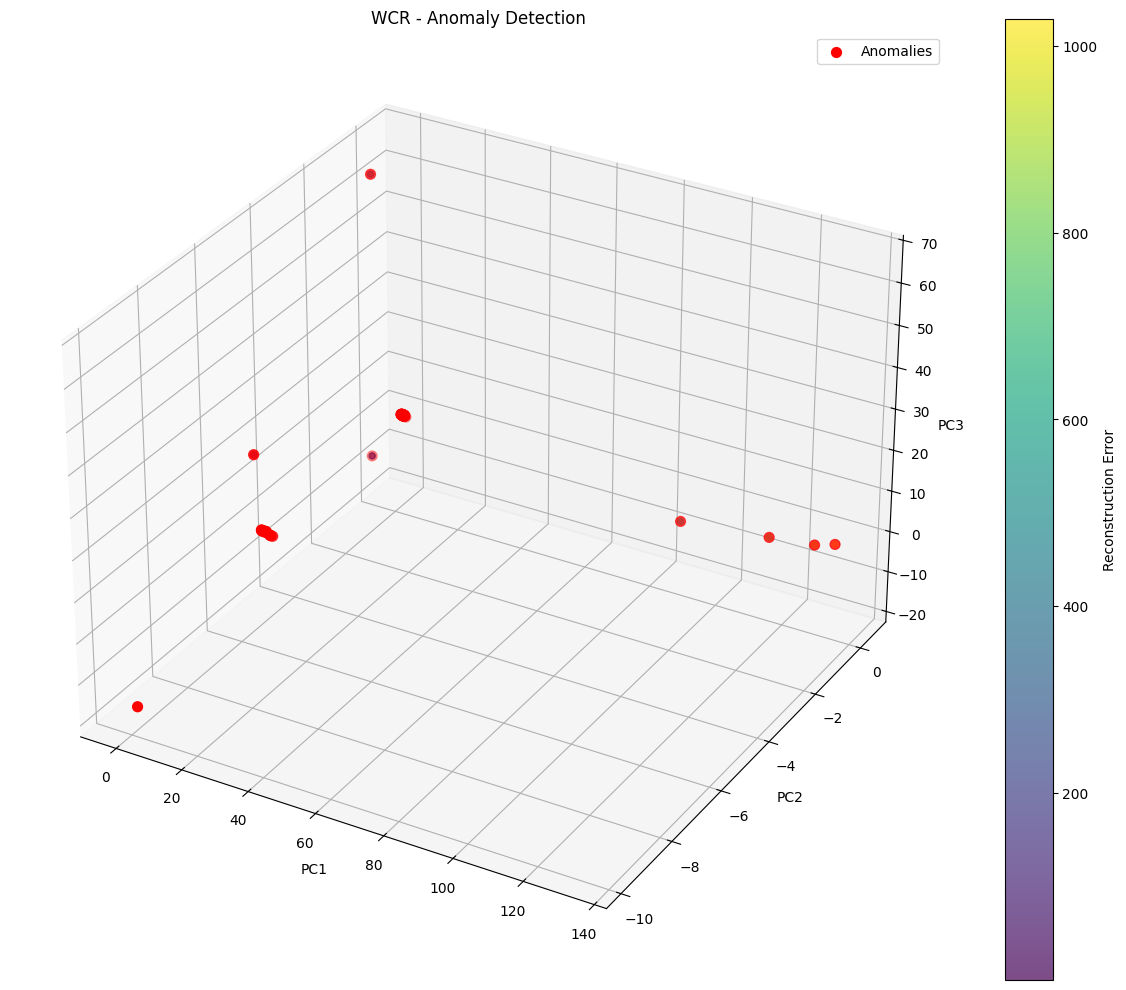

Training Accuracy: 1.0000
Testing Accuracy: 1.0000


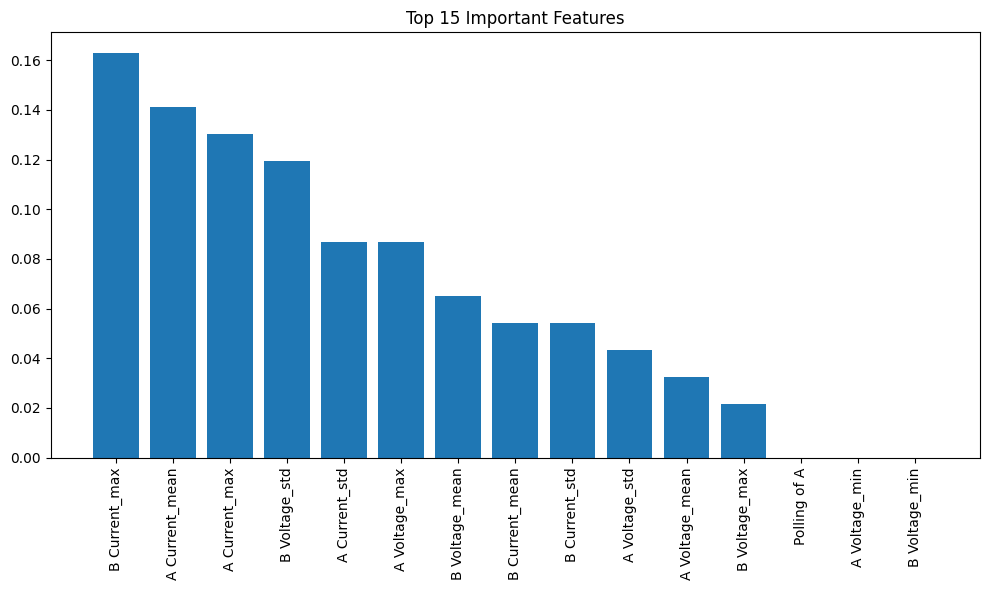

Top 5 important features for WCR:
           Feature  Importance
11   B Current_max    0.163043
2   A Current_mean    0.141304
3    A Current_max    0.130435
17   B Voltage_std    0.119565
5    A Current_std    0.086957


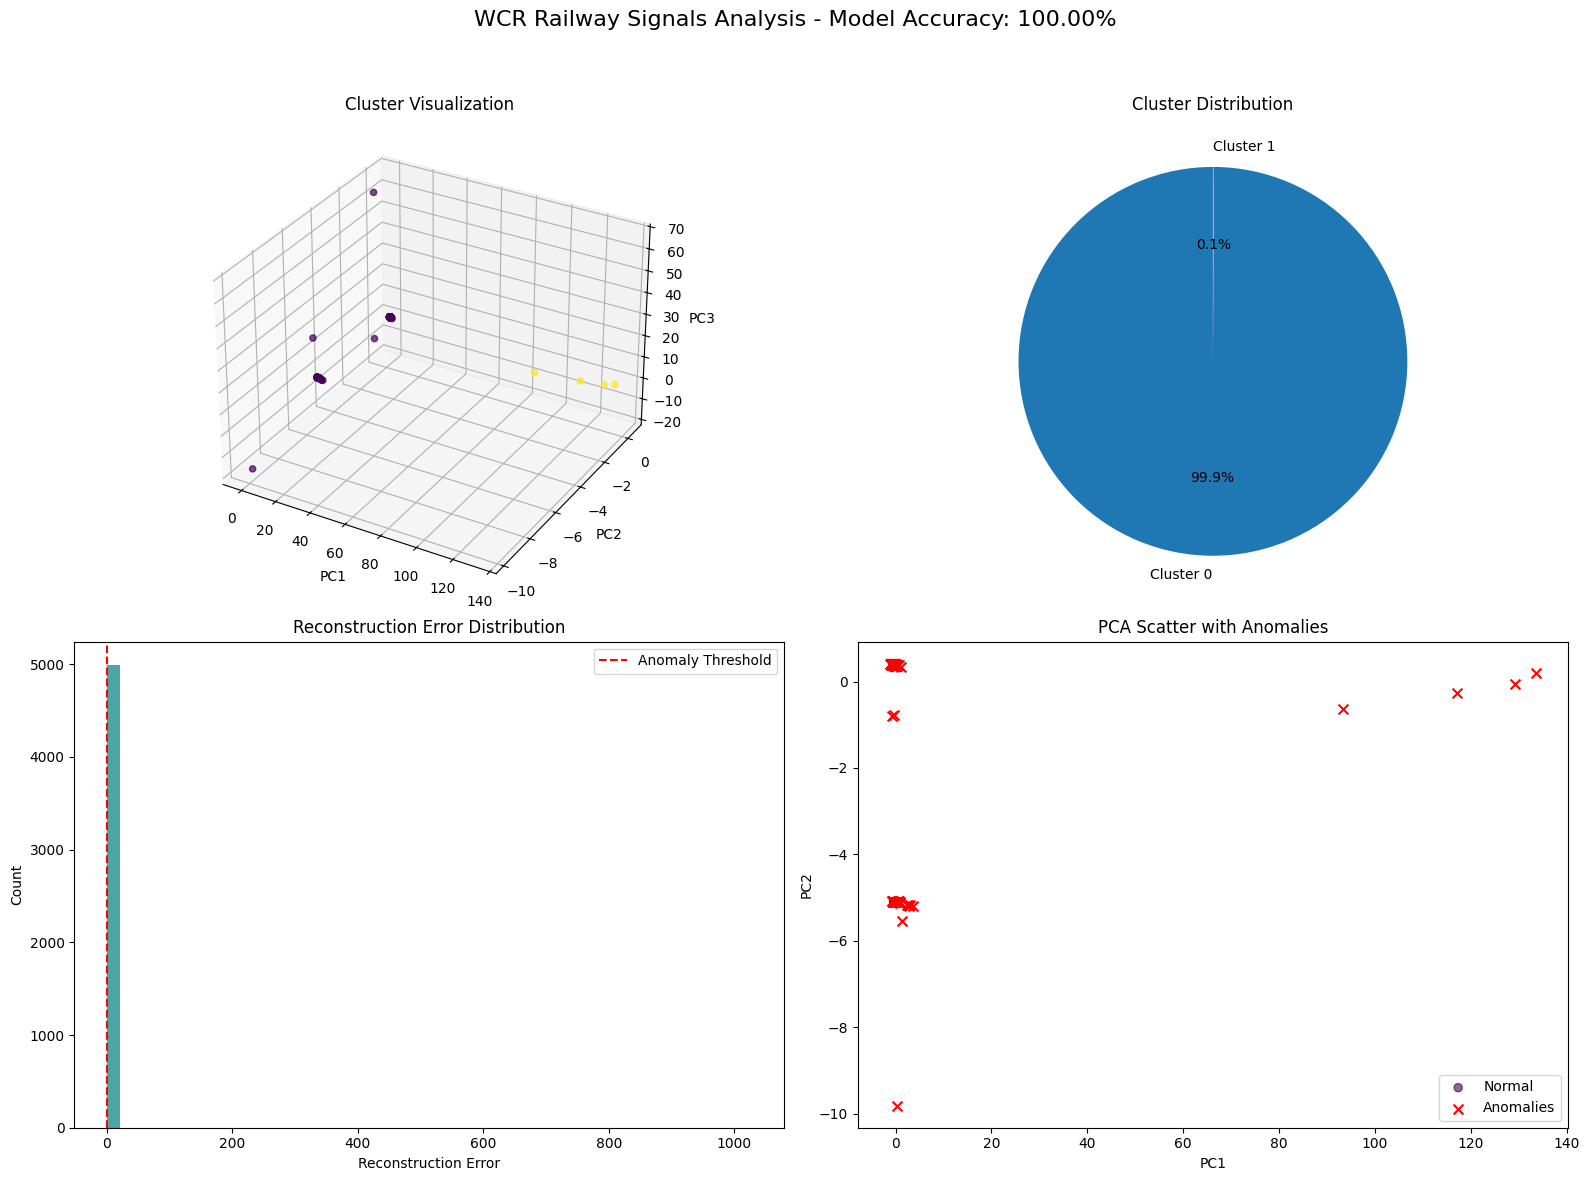


Processing WR from FEB 2025 Prototype data\WR.csv
Original dataset shape: (341322, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (5000, 18)
Explained variance: [0.57707139 0.11974465 0.09025193]
Total explained variance: 0.7871
K=2, Silhouette Score=0.9820
K=3, Silhouette Score=0.7493
K=4, Silhouette Score=0.7568
K=5, Silhouette Score=0.7608
K=6, Silhouette Score=0.7637
K=7, Silhouette Score=0.7636
K=8, Silhouette Score=0.7663
K=9, Silhouette Score=0.7662
K=10, Silhouette Score=0.7756


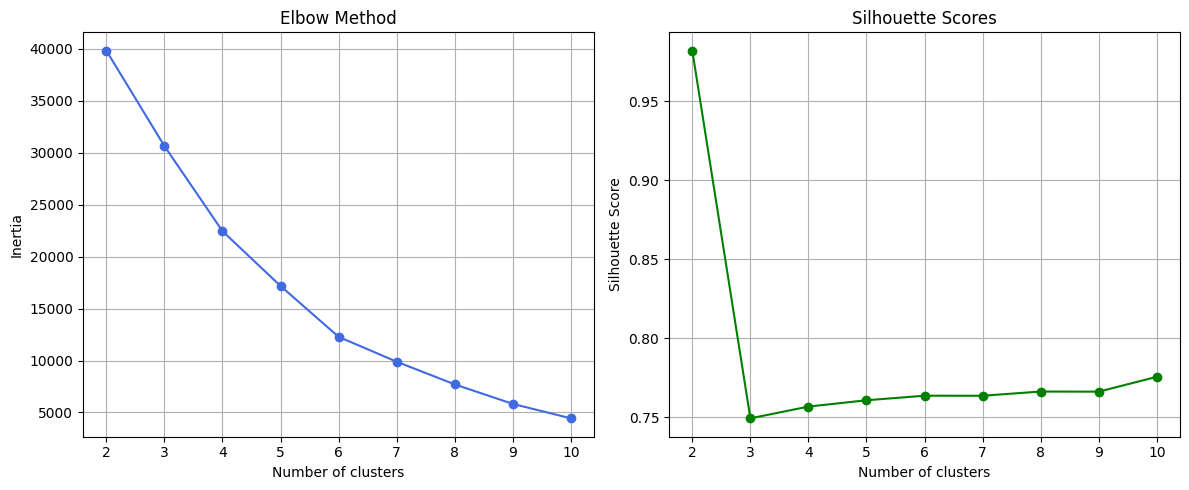

Optimal number of clusters: 2


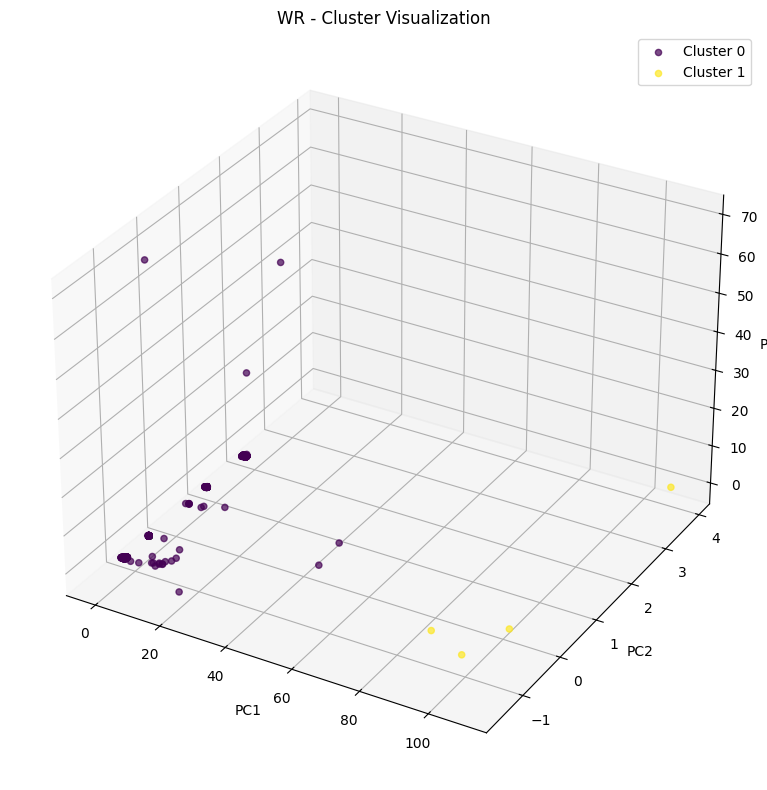

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4916 - val_loss: 0.1859
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5238 - val_loss: 0.1499
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6308 - val_loss: 0.0548
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1747 - val_loss: 0.0901
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4786 - val_loss: 0.0979
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5583 - val_loss: 0.1086
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3562 - val_loss: 0.1024
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5131 - val_loss: 0.0962


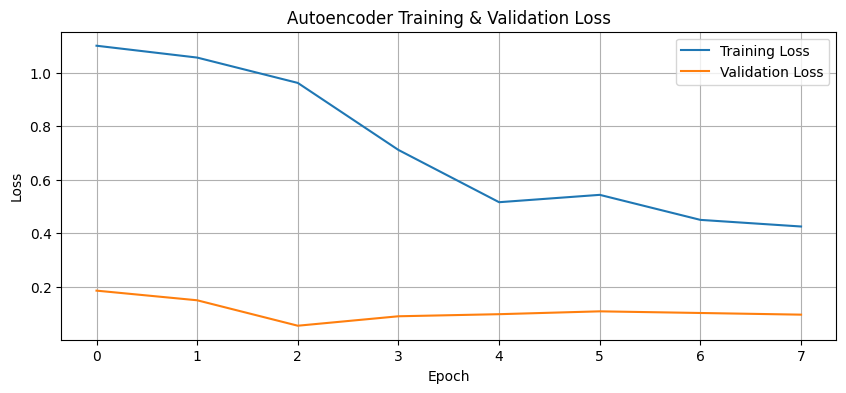

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Detected 250 anomalies out of 5000 data points


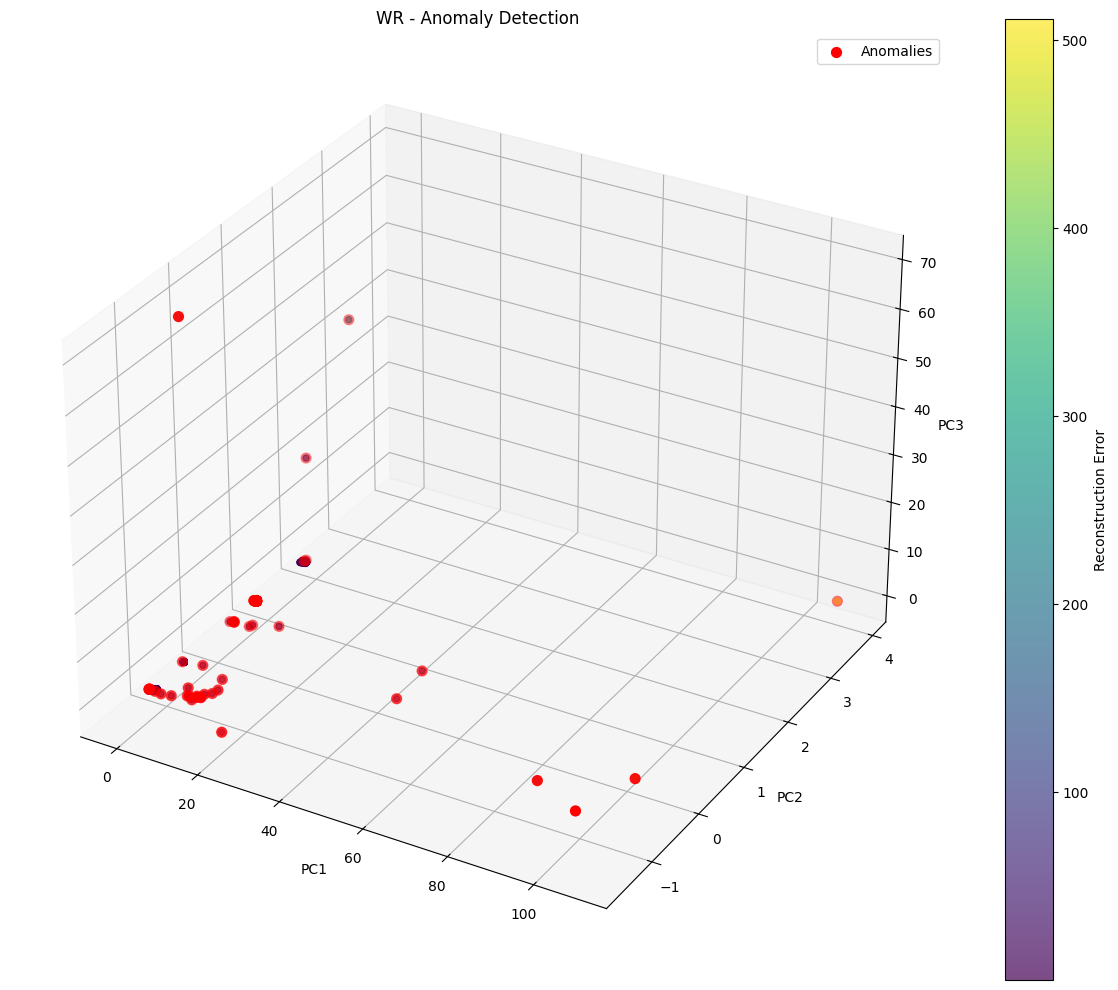

Training Accuracy: 1.0000
Testing Accuracy: 1.0000


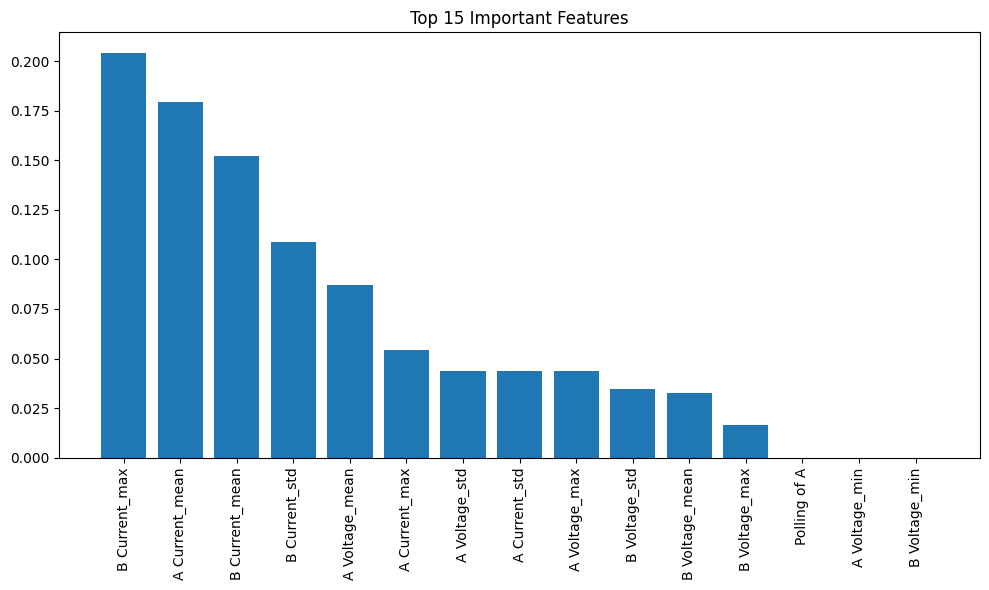

Top 5 important features for WR:
           Feature  Importance
11   B Current_max    0.204347
2   A Current_mean    0.179342
10  B Current_mean    0.152174
13   B Current_std    0.108696
6   A Voltage_mean    0.086957


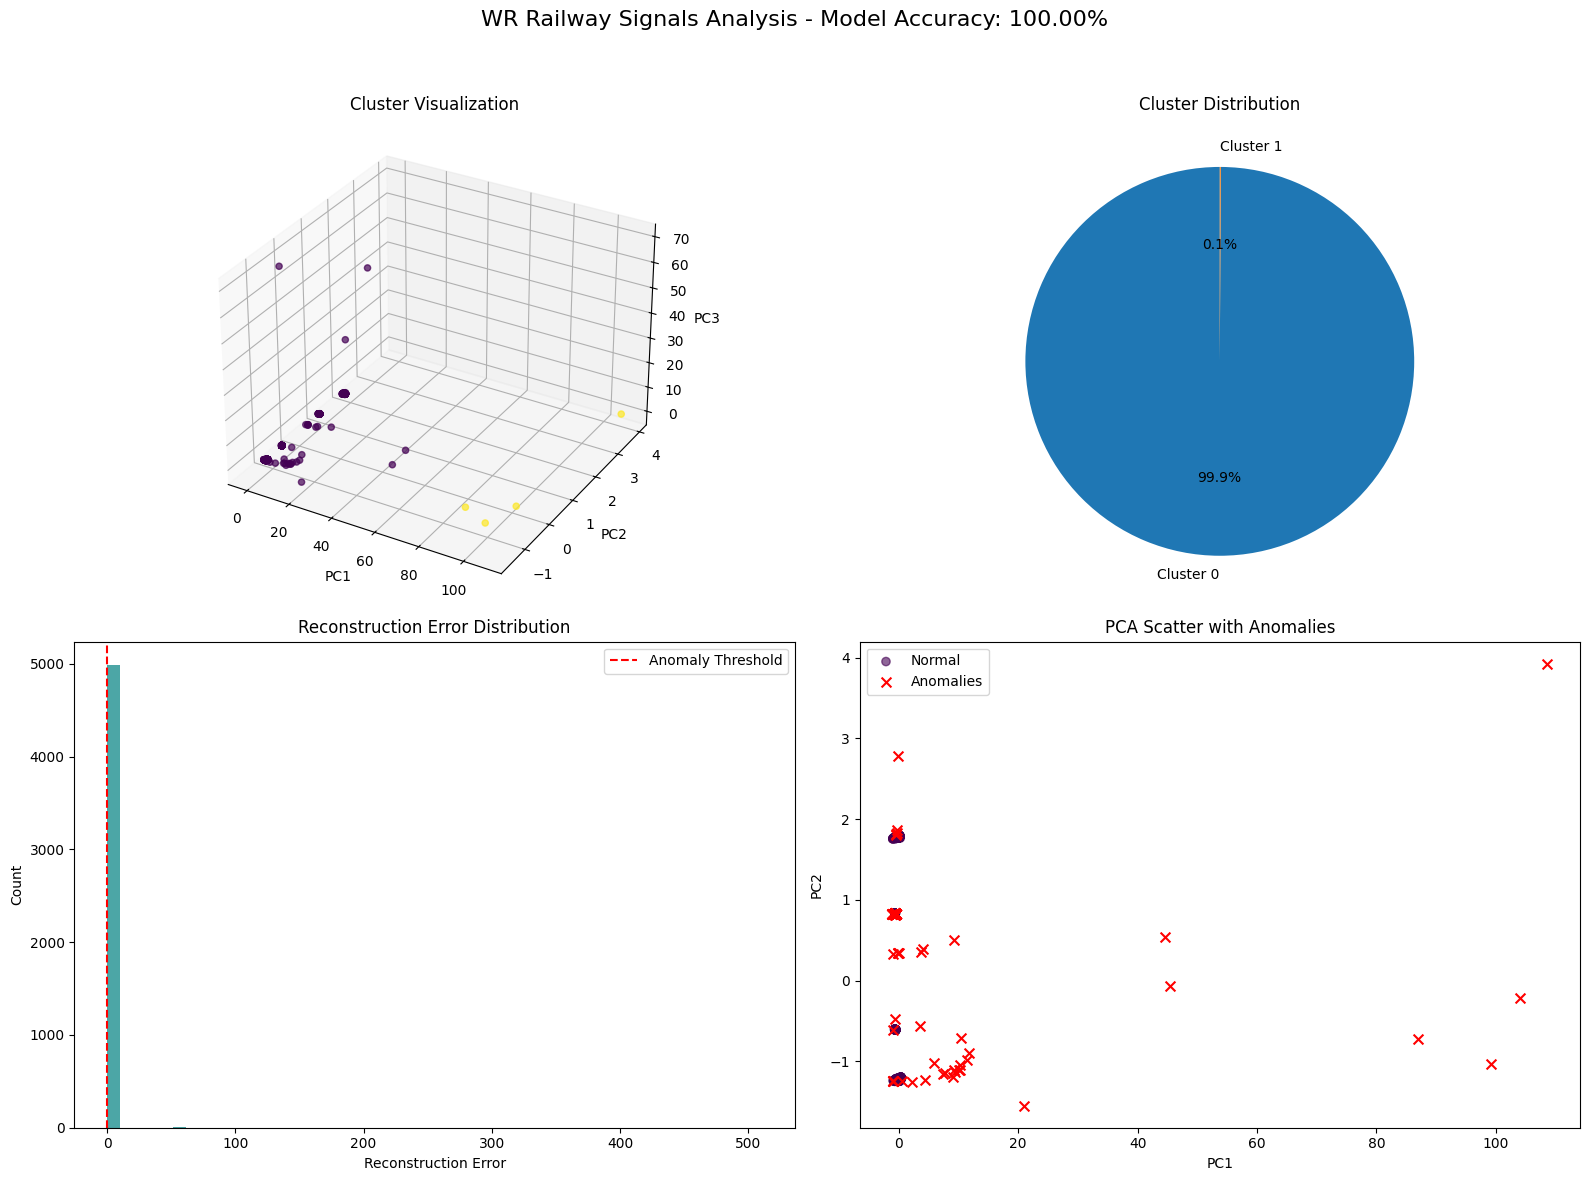


Processing TEST_ZONE from FEB 2025 Prototype data\Test_Zone.csv
Original dataset shape: (23, 12)
Found 2 numeric columns
Extracted features from A Current
Extracted features from A Voltage
Extracted features from B Current
Extracted features from B Voltage
Final dataset shape: (23, 18)
Explained variance: [0.48569767 0.35985932 0.06088831]
Total explained variance: 0.9064
K=2, Silhouette Score=0.4389
K=3, Silhouette Score=0.5671
K=4, Silhouette Score=0.5835
K=5, Silhouette Score=0.6113
K=6, Silhouette Score=0.5944
K=7, Silhouette Score=0.5891
K=8, Silhouette Score=0.5977
K=9, Silhouette Score=0.5850
K=10, Silhouette Score=0.5953


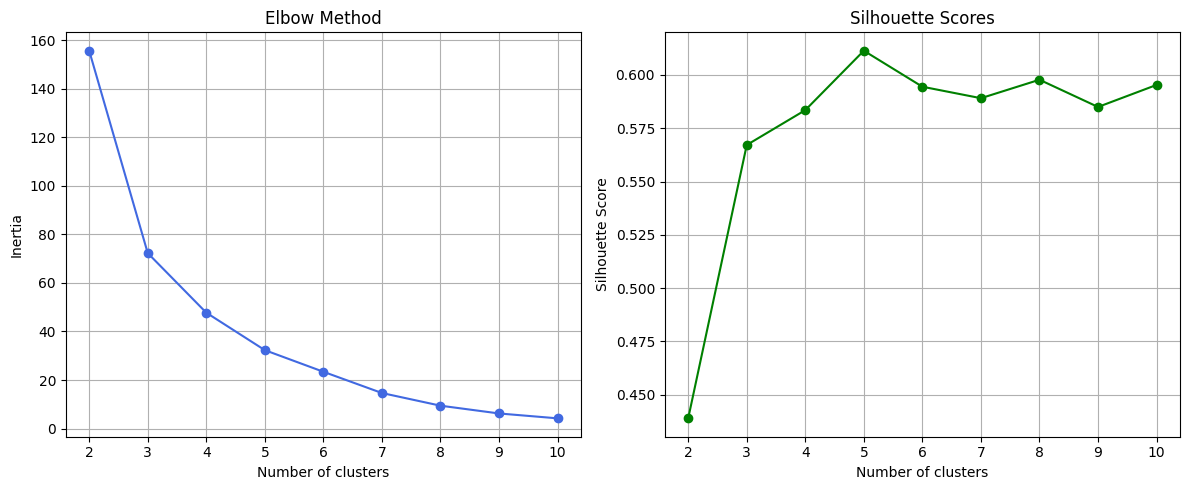

Optimal number of clusters: 5


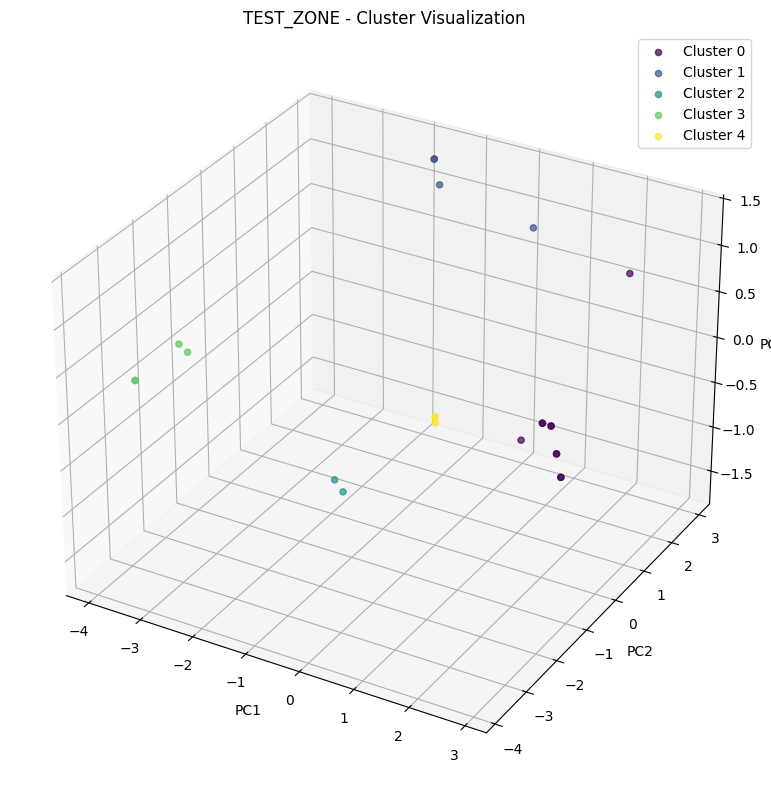

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.6525 - val_loss: 0.7133
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.6428 - val_loss: 0.7111
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.6416 - val_loss: 0.7086
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.6368 - val_loss: 0.7057
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - loss: 0.6360 - val_loss: 0.7018
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - loss: 0.6293 - val_loss: 0.6971
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - loss: 0.6317 - val_loss: 0.6921
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - loss: 0.6243 - val_loss: 0.6864
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.6062 - val_loss: 0.6794
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - loss: 0.6061 - val_loss: 0.6697
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.5923 - val_loss: 0.6588
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - loss: 0.5890 - val_loss:

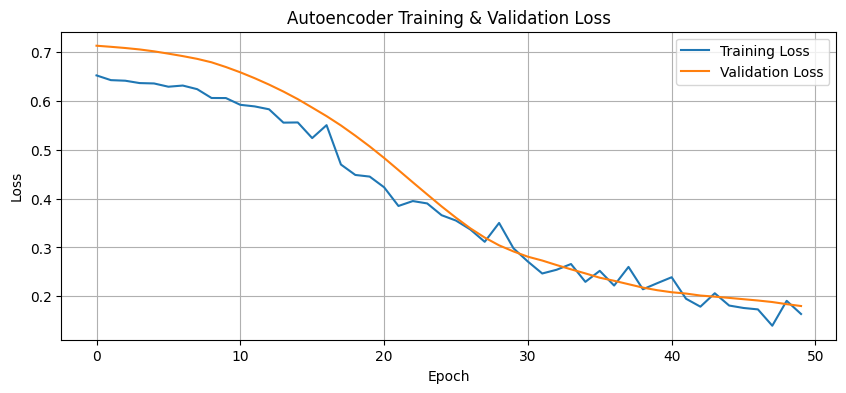

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Detected 1 anomalies out of 23 data points


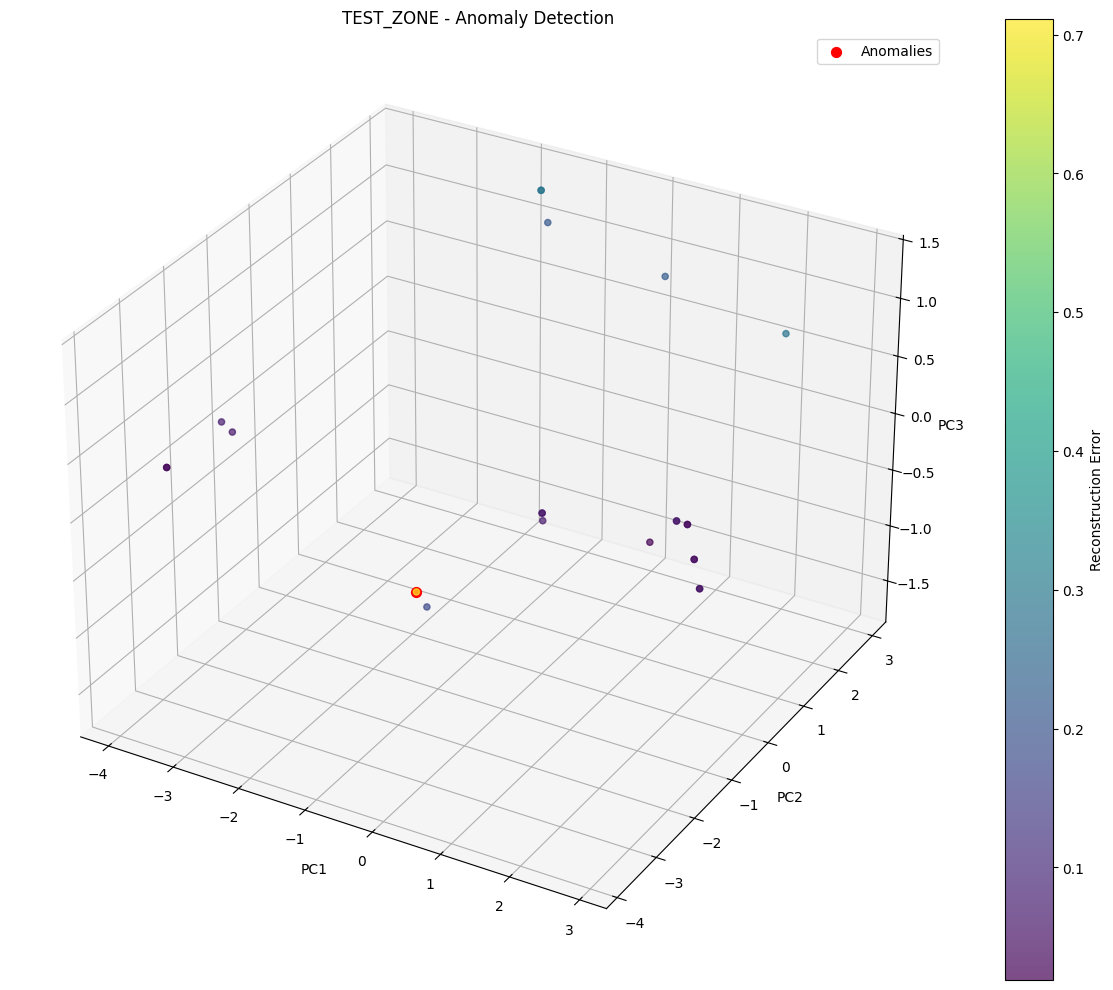

Training Accuracy: 1.0000
Testing Accuracy: 0.8571


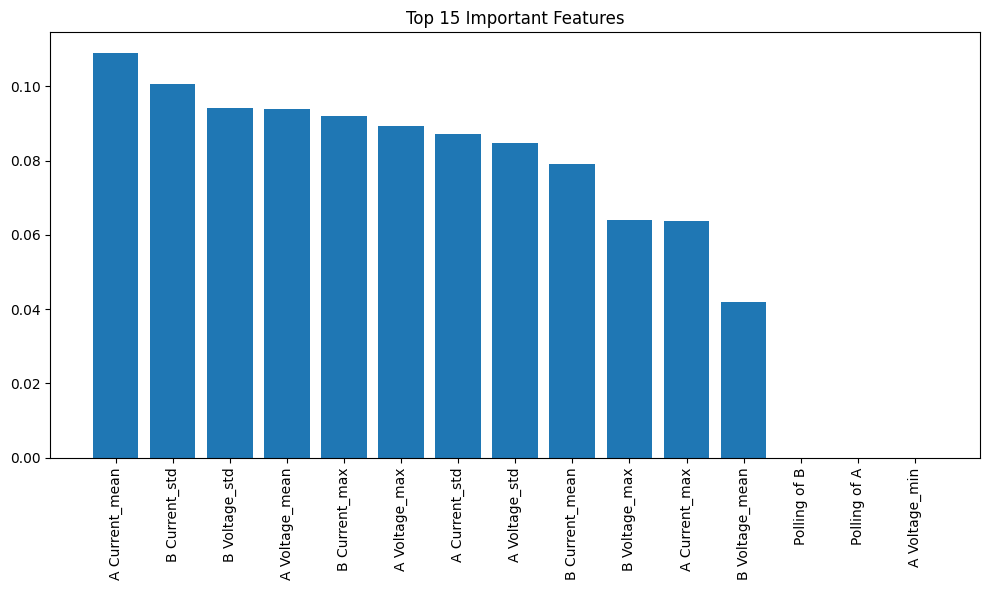

Top 5 important features for TEST_ZONE:
           Feature  Importance
2   A Current_mean    0.109119
13   B Current_std    0.100662
17   B Voltage_std    0.094081
6   A Voltage_mean    0.093930
11   B Current_max    0.092052


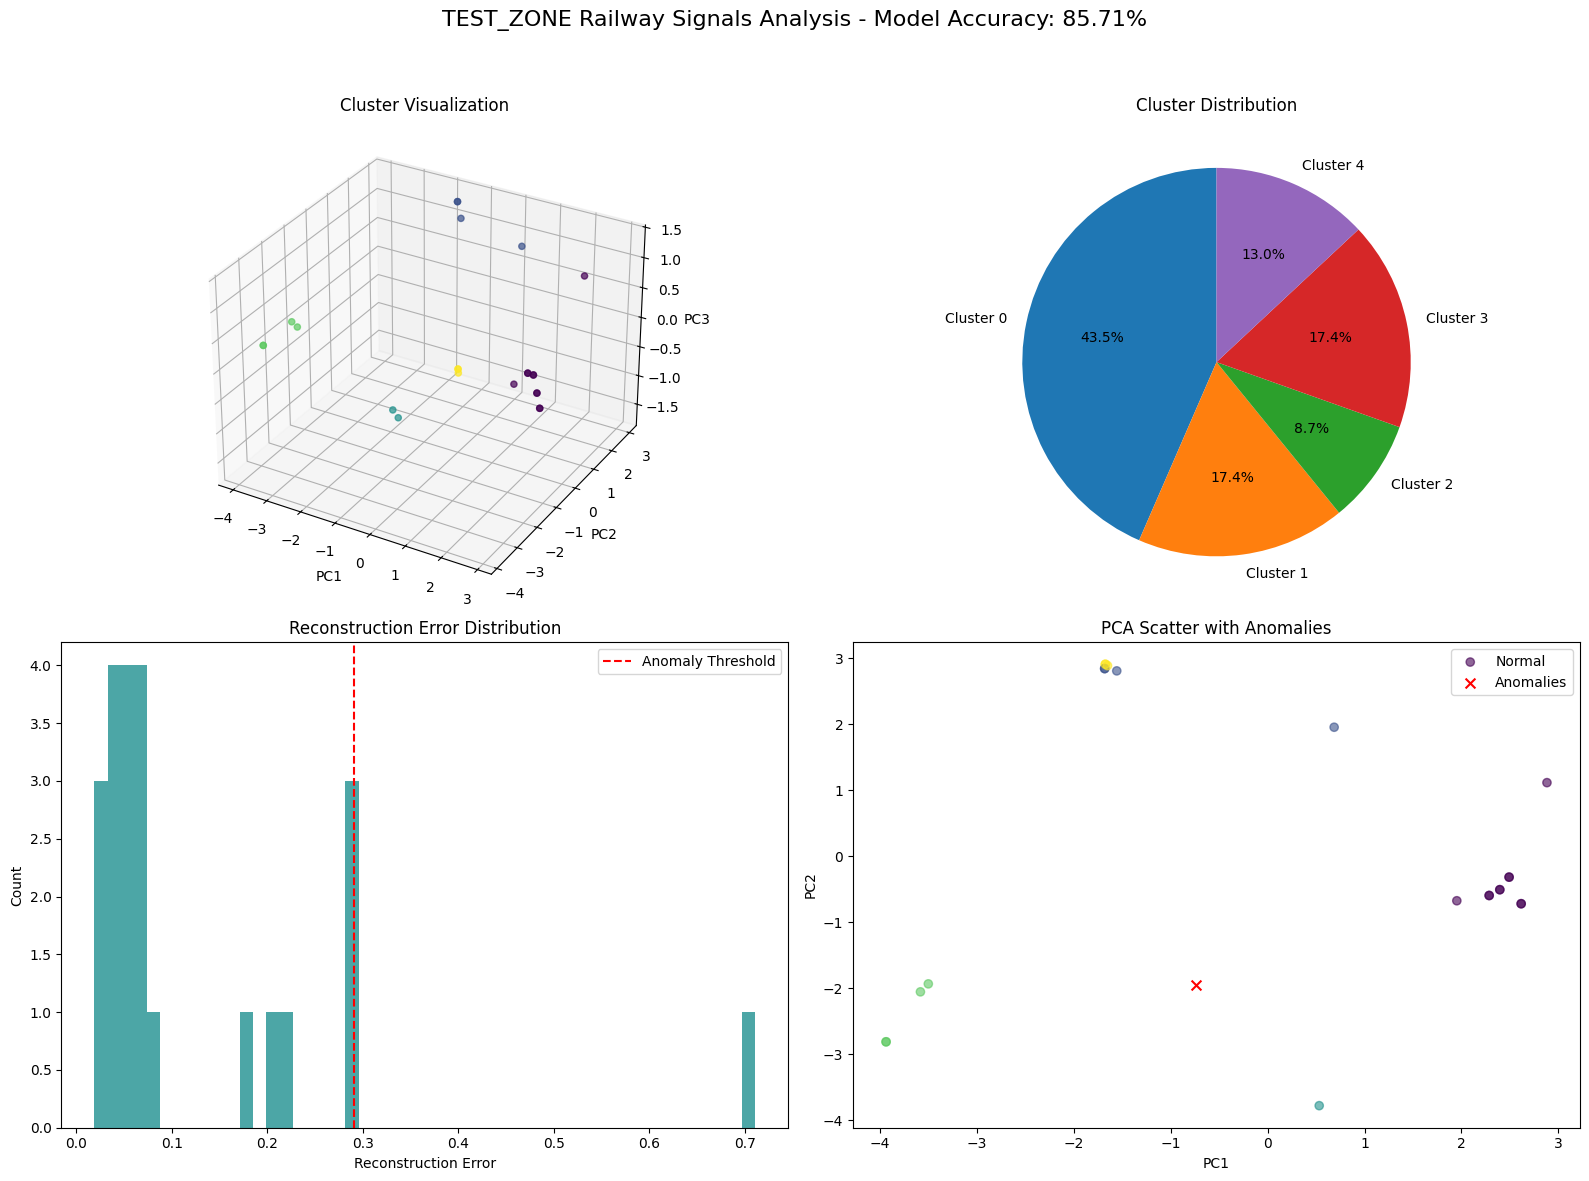

In [105]:
all_results = {}

for region_name, file_path in datasets.items():
    try:
        results = process_region(region_name, file_path)
        if results:
            all_results[region_name] = results
    except Exception as e:
        print(f"Error processing {region_name}: {e}")

In [106]:
def create_summary_visual():
    try:
        accuracy_data = [(region, results['accuracy'] * 100) 
                        for region, results in all_results.items()]
        
        if not accuracy_data:
            print("No successful results to visualize. Please check your data processing.")
            return
            
        accuracy_df = pd.DataFrame(accuracy_data, columns=['Region', 'Accuracy'])
        accuracy_df = accuracy_df.sort_values('Accuracy', ascending=False)
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(accuracy_df['Region'], accuracy_df['Accuracy'], color='royalblue')
        plt.title('Clustering Model Accuracy by Railway Region')
        plt.xlabel('Railway Region')
        plt.ylabel('Accuracy (%)')
        plt.xticks(rotation=45)
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nAverage model accuracy across all regions: {accuracy_df['Accuracy'].mean():.2f}%")
        
        if len(accuracy_df) > 0:
            print(f"Best performing region: {accuracy_df.iloc[0]['Region']} ({accuracy_df.iloc[0]['Accuracy']:.2f}%)")
            print(f"Region needing most improvement: {accuracy_df.iloc[-1]['Region']} ({accuracy_df.iloc[-1]['Accuracy']:.2f}%)")
    except Exception as e:
        print(f"Error creating summary visualization: {e}")

In [107]:
def compare_regions():
    if not all_results:
        print("No results to compare")
        return
    
    comparison_data = []
    
    for region, results in all_results.items():
        comparison_data.append({
            'Region': region,
            'Optimal Clusters': results['optimal_clusters'],
            'Model Accuracy': results['accuracy'] * 100,
            'Anomalies (%)': results['anomalies_percentage'],
            'Top Feature': results['feature_importances'].iloc[0]['Feature']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    axes[0, 0].bar(comparison_df['Region'], comparison_df['Optimal Clusters'], color='royalblue')
    axes[0, 0].set_title('Optimal Number of Clusters by Region')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    axes[0, 1].bar(comparison_df['Region'], comparison_df['Model Accuracy'], color='green')
    axes[0, 1].set_title('Model Accuracy by Region (%)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    axes[1, 0].bar(comparison_df['Region'], comparison_df['Anomalies (%)'], color='coral')
    axes[1, 0].set_title('Anomalies Percentage by Region')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    high_anomaly_regions = comparison_df[comparison_df['Anomalies (%)'] > comparison_df['Anomalies (%)'].median()]
    axes[1, 1].pie(
        high_anomaly_regions['Anomalies (%)'], 
        labels=high_anomaly_regions['Region'],
        autopct='%1.1f%%', 
        startangle=90
    )
    axes[1, 1].set_title('Regions with High Anomaly Rates')
    
    plt.suptitle("Railway Regions Comparison Dashboard", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    print("\nRegions Summary:")
    print(comparison_df.sort_values('Model Accuracy', ascending=False))

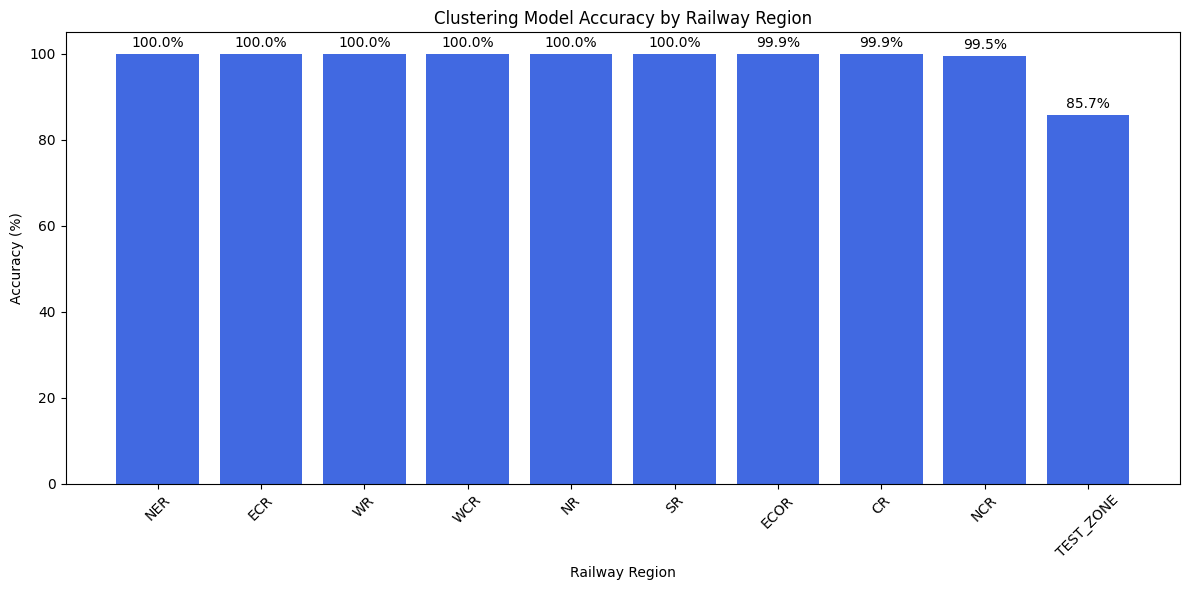


Average model accuracy across all regions: 98.50%
Best performing region: NER (100.00%)
Region needing most improvement: TEST_ZONE (85.71%)


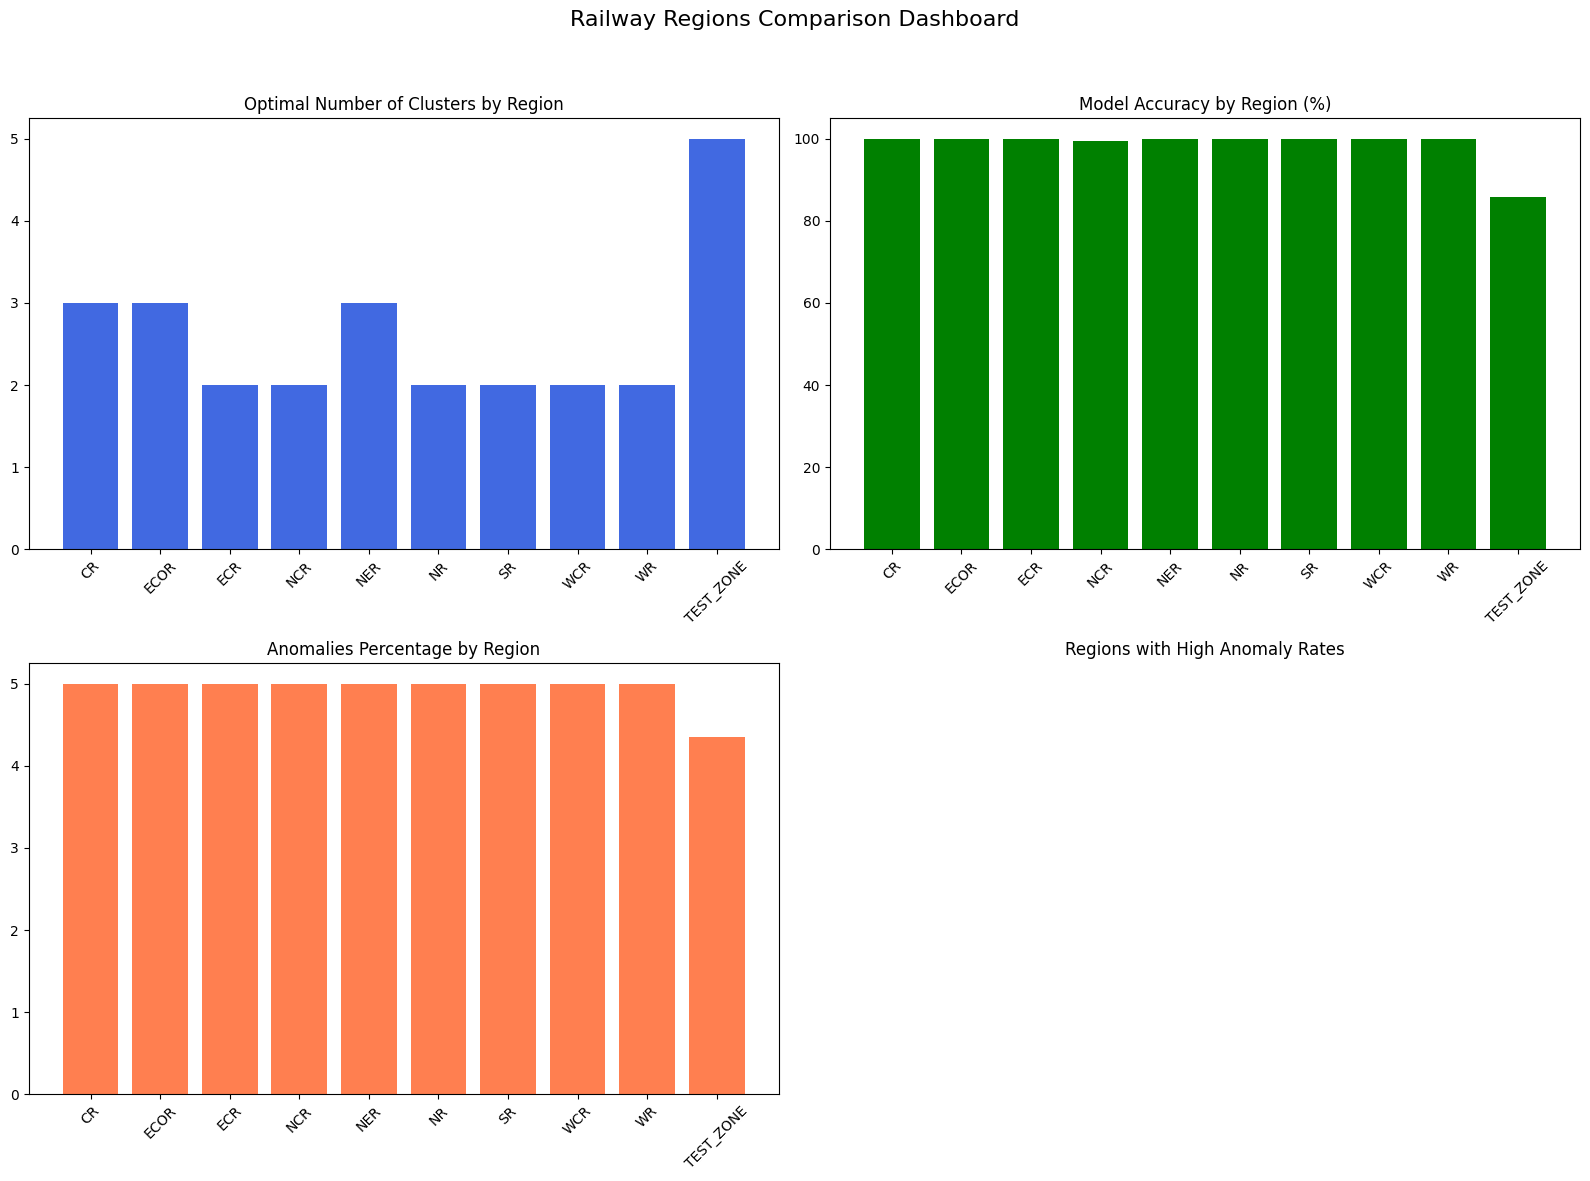


Regions Summary:
      Region  Optimal Clusters  Model Accuracy  Anomalies (%)     Top Feature
4        NER                 3      100.000000       5.000000   A Voltage_max
2        ECR                 2      100.000000       5.000000   A Voltage_max
8         WR                 2      100.000000       5.000000   B Current_max
7        WCR                 2      100.000000       5.000000   B Current_max
5         NR                 2      100.000000       5.000000   A Voltage_max
6         SR                 2      100.000000       5.000000  A Voltage_mean
1       ECOR                 3       99.933333       5.000000   A Voltage_max
0         CR                 3       99.866667       5.000000  A Voltage_mean
3        NCR                 2       99.533333       5.000000  A Current_mean
9  TEST_ZONE                 5       85.714286       4.347826  A Current_mean


In [108]:
create_summary_visual()
compare_regions()